In [6]:
import torch 

torch.cuda.is_available()

True

### Reading raw job logs + initial analysis

In [1]:
from load import load_jobs

# The scan and fault-label derivation moved to scripts/load.py so that
# feat-engineering.ipynb can build the same frame without this notebook. Edit the
# fault taxonomy there, not here.
globals().update(load_jobs())


Found 168 Parquet partition files.
Total dataset size on disk: 15.60 GB across 168 files.
Columns in NEED not present in raw dataset: ['Group']
Normalised 8 epoch-ms columns (0 -> null): QDate_ms, JobStartDate_ms, JobCurrentStartDate_ms, JobCurrentStartExecutingDate_ms, CompletionDate_ms, EnteredCurrentStatus_ms, LastMatchTime_ms, x509UserProxyExpiration_ms
Resolved: queue=QDate_ms start=JobStartDate_ms completion=CompletionDate terminal-status=EnteredCurrentStatus_ms
Lazy execution plan initialized successfully!


In [5]:
import time
import polars as pl
import datetime as dt

# 1. Memory-safe collector with full fallback for unsupported streaming operations
def sc(frame):
    try:
        return frame.collect(engine="streaming")
    except TypeError:
        return frame.collect(streaming=True)
    except Exception:
        return frame.collect()  # Safe fallback if streaming engine hits a ComputeError
    
t = time.time()

# Aggregate all outcome buckets in a single pass
agg = sc(
    lf.select(
        [
            pl.len().alias("n_total"),
            pl.col("Success").sum().alias("n_success"),
            pl.col("UserCancelled").sum().alias("n_user_cancelled"),
            pl.col("Failed").sum().alias("n_genuine_failed"),
            (pl.col("fault_type") == 0).sum().alias("n_app"),
            (pl.col("fault_type") == 1).sum().alias("n_hw"),
            (pl.col("fault_type") == 2).sum().alias("n_sub"),
        ]
    )
)

n_total = agg["n_total"][0]
n_success = agg["n_success"][0]
n_user_cancelled = agg["n_user_cancelled"][0]
n_failed = agg["n_genuine_failed"][0]

n_app = agg["n_app"][0]
n_hw = agg["n_hw"][0]
n_sub = agg["n_sub"][0]
n_payload = n_app + n_sub

# Rates relative to all submitted jobs
pct_success = (n_success / n_total) * 100
pct_user_cancelled = (n_user_cancelled / n_total) * 100
fail_rate_overall = (n_failed / n_total) * 100

# Failure rate among completed/non-cancelled jobs
n_completed = n_total - n_user_cancelled
fail_rate_completed = (n_failed / n_completed) * 100

# Fault proportions among genuine failures
pct_payload_of_fail = (n_payload / n_failed) * 100 if n_failed > 0 else 0.0
pct_hw_of_fail = (n_hw / n_failed) * 100 if n_failed > 0 else 0.0

print(f"DATASET")
print(f"Total Submitted Jobs       : {n_total:,}")
print(f"  ├─ Clean Successes       : {n_success:,} ({pct_success:.2f}%)")
print(
    f"  ├─ Voluntary User Removals: {n_user_cancelled:,} ({pct_user_cancelled:.2f}%)"
)
print(
    f"  └─ Genuine Failures      : {n_failed:,} ({fail_rate_overall:.2f}% of total)"
)
print("-" * 65)
print(
    f"Failure Rate (excluding user cancellations) : {fail_rate_completed:.2f}%"
)
print("-" * 65)
print("FAULT ATTRIBUTION (Genuine Failures Only):")
print(
    f"  ├─ Payload Faults (App + Sub) : {n_payload:,} ({pct_payload_of_fail:.1f}%)"
)
print(
    f"  │    ├─ Application Faults    : {n_app:,} ({n_app/n_failed*100:.1f}%)"
)
print(
    f"  │    └─ Submission Faults     : {n_sub:,} ({n_sub/n_failed*100:.1f}%)"
)
print(
    f"  └─ Hardware Faults            : {n_hw:,} ({pct_hw_of_fail:.1f}%)"
)
print("=" * 65)

DATASET
Total Submitted Jobs       : 64,088,358
  ├─ Clean Successes       : 47,054,073 (73.42%)
  ├─ Voluntary User Removals: 7,997,658 (12.48%)
  └─ Genuine Failures      : 9,036,627 (14.10% of total)
-----------------------------------------------------------------
Failure Rate (excluding user cancellations) : 16.11%
-----------------------------------------------------------------
FAULT ATTRIBUTION (Genuine Failures Only):
  ├─ Payload Faults (App + Sub) : 8,284,248 (91.7%)
  │    ├─ Application Faults    : 7,629,332 (84.4%)
  │    └─ Submission Faults     : 654,916 (7.2%)
  └─ Hardware Faults            : 752,379 (8.3%)


### Task populations (what the models actually see)

In [8]:
# The cell above is the RAW queue: it counts pilots and jobs that never started, so
# its rates are not the ones the models train on. Most of the gap is cancellations --
# pilots retire via condor_rm -- and hardware attribution.
# "Started" is JobStartDate, not NumJobStarts: wait_s and the E2 target both derive
# from JobStartDate, and the two disagree on 26,132 jobs.

is_pilot = pl.col("Cmd") == "./glidein_startup.sh"
workflow = ~is_pilot
started = pl.col(scol).is_not_null()
task = workflow & started

acc = sc(
    lf.select(
        [
            pl.len().alias("queue_records"),
            is_pilot.sum().alias("pilots"),
            workflow.sum().alias("workflow"),
            (workflow & ~started).sum().alias("never_started"),
            task.sum().alias("started"),
            (task & (pl.col("Success") == 1)).sum().alias("t_success"),
            (task & (pl.col("UserCancelled") == 1)).sum().alias("t_cancel"),
            (task & (pl.col("Failed") == 1)).sum().alias("t_failed"),
            (task & (pl.col("fault_type") == 1)).sum().alias("t_hw"),
            (task & (pl.col("wait_s") > 0)).sum().alias("t_wait"),
        ]
    )
)

a = {c: acc[c][0] for c in acc.columns}
a["t_payload"] = a["t_failed"] - a["t_hw"]
N = a["queue_records"]


def _row(label, n, indent=0):
    print(f"{'  ' * indent + label:<44s}{n:>12,}  {n / N * 100:6.2f}%")


print("TASK POPULATIONS")
_row("Queue records", N)
_row("pilots", a["pilots"], 1)
_row("Workflow jobs", a["workflow"])
_row("never started", a["never_started"], 1)
_row("started at least once", a["started"], 1)
print("-" * 66)
_row("Failure prediction / fault attribution", a["started"])
_row("successes", a["t_success"], 1)
_row("user cancellations (not a target)", a["t_cancel"], 1)
_row("technical failures", a["t_failed"], 1)
_row("hardware", a["t_hw"], 2)
_row("payload", a["t_payload"], 2)
_row("Queue wait prediction (wait > 0)", a["t_wait"])
print("-" * 66)
print(f"hardware share of failures : {a['t_hw'] / a['t_failed'] * 100:.2f}%")
print(f"failure rate (started jobs): "
      f"{a['t_failed'] / (a['started'] - a['t_cancel']) * 100:.2f}%")


TASK POPULATIONS
Queue records                                 64,088,358  100.00%
  pilots                                       5,145,404    8.03%
Workflow jobs                                 58,942,954   91.97%
  never started                                2,811,701    4.39%
  started at least once                       56,131,253   87.58%
------------------------------------------------------------------
Failure prediction / fault attribution        56,131,253   87.58%
  successes                                   46,852,897   73.11%
  user cancellations (not a target)            1,242,330    1.94%
  technical failures                           8,036,026   12.54%
    hardware                                     523,180    0.82%
    payload                                    7,512,846   11.72%
Queue wait prediction (wait > 0)              55,690,781   86.90%
------------------------------------------------------------------
hardware share of failures : 6.51%
failure rate (started 

Computing wait quantiles

In [9]:
qs = [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
wq = sc(
    lf.select(
        [pl.col("wait_s").quantile(q).alias(f"p{int(q*100)}") for q in qs]
        + [pl.col("wait_s").median().alias("median")]
    )
).to_dicts()[0]

formatted_wq = {k: (round(v) if v is not None else None) for k, v in wq.items()}
median_val = wq.get("median")
median_min = round(median_val / 60, 1) if median_val is not None else None

print("wait_s (s):", formatted_wq, " median(min):", median_min)

wait_s (s): {'p10': 40, 'p25': 320, 'p50': 1546, 'p75': 6848, 'p90': 23430, 'p99': 236795, 'median': 1546}  median(min): 25.8


Dataset characterization (streaming: timeframe / users / sites / groups / batches)

In [10]:
GROUPCOL = "Group" if "Group" in have or "AccountingGroup" in have else None  
SITECOL ="MATCH_EXP_JOB_GLIDEIN_Site"

# 2. Time frame calculation with qcol safeguard
if qcol and qcol in have:
    _sch = lf.collect_schema()
    def _sec(col):
        if isinstance(_sch[col], pl.Datetime):
            return pl.col(col).dt.epoch(time_unit="s").cast(pl.Float64)
        v = pl.col(col).cast(pl.Float64, strict=False)
        return (pl.when(v > 1e17).then(v / 1e9)
                  .when(v > 1e14).then(v / 1e6)
                  .when(v > 1e11).then(v / 1e3)
                  .otherwise(v))

    tf = sc(lf.select([_sec(qcol).min().alias("start"), _sec(qcol).max().alias("end")]))
    s0, s1 = tf["start"][0], tf["end"][0]
else:
    s0, s1 = None, None

def fmt(s):
    try:
        return dt.datetime.fromtimestamp(s, dt.timezone.utc).strftime("%Y-%m-%d %H:%M")
    except (ValueError, OverflowError, TypeError, OSError):
        return f"raw={s}"

if s0 is not None and s1 is not None:
    print(f"time frame (submit): {fmt(s0)}  ->  {fmt(s1)}   ({(s1 - s0) / 86400:.0f} days)")
else:
    print("time frame: n/a")

# 3. Cardinalities
card = {}
for name, col in [("users", "Owner"), ("sites", SITECOL), ("groups", GROUPCOL),
                  ("batches", "ClusterId"), ("campaigns", "POMS4_CAMPAIGN_ID"),
                  ("images", "SingularityImage")]:
    if col and col in have:
        card[name] = sc(lf.select(pl.col(col).n_unique())).item()
print("distinct:", card)

time frame (submit): 2025-02-01 00:00  ->  2025-08-31 23:59   (212 days)
distinct: {'users': 395, 'sites': 44, 'groups': 27, 'batches': 20110451, 'campaigns': 685, 'images': 25}


### Feature evaluation

output/failure_cyclical_and_site_bursts.pdf


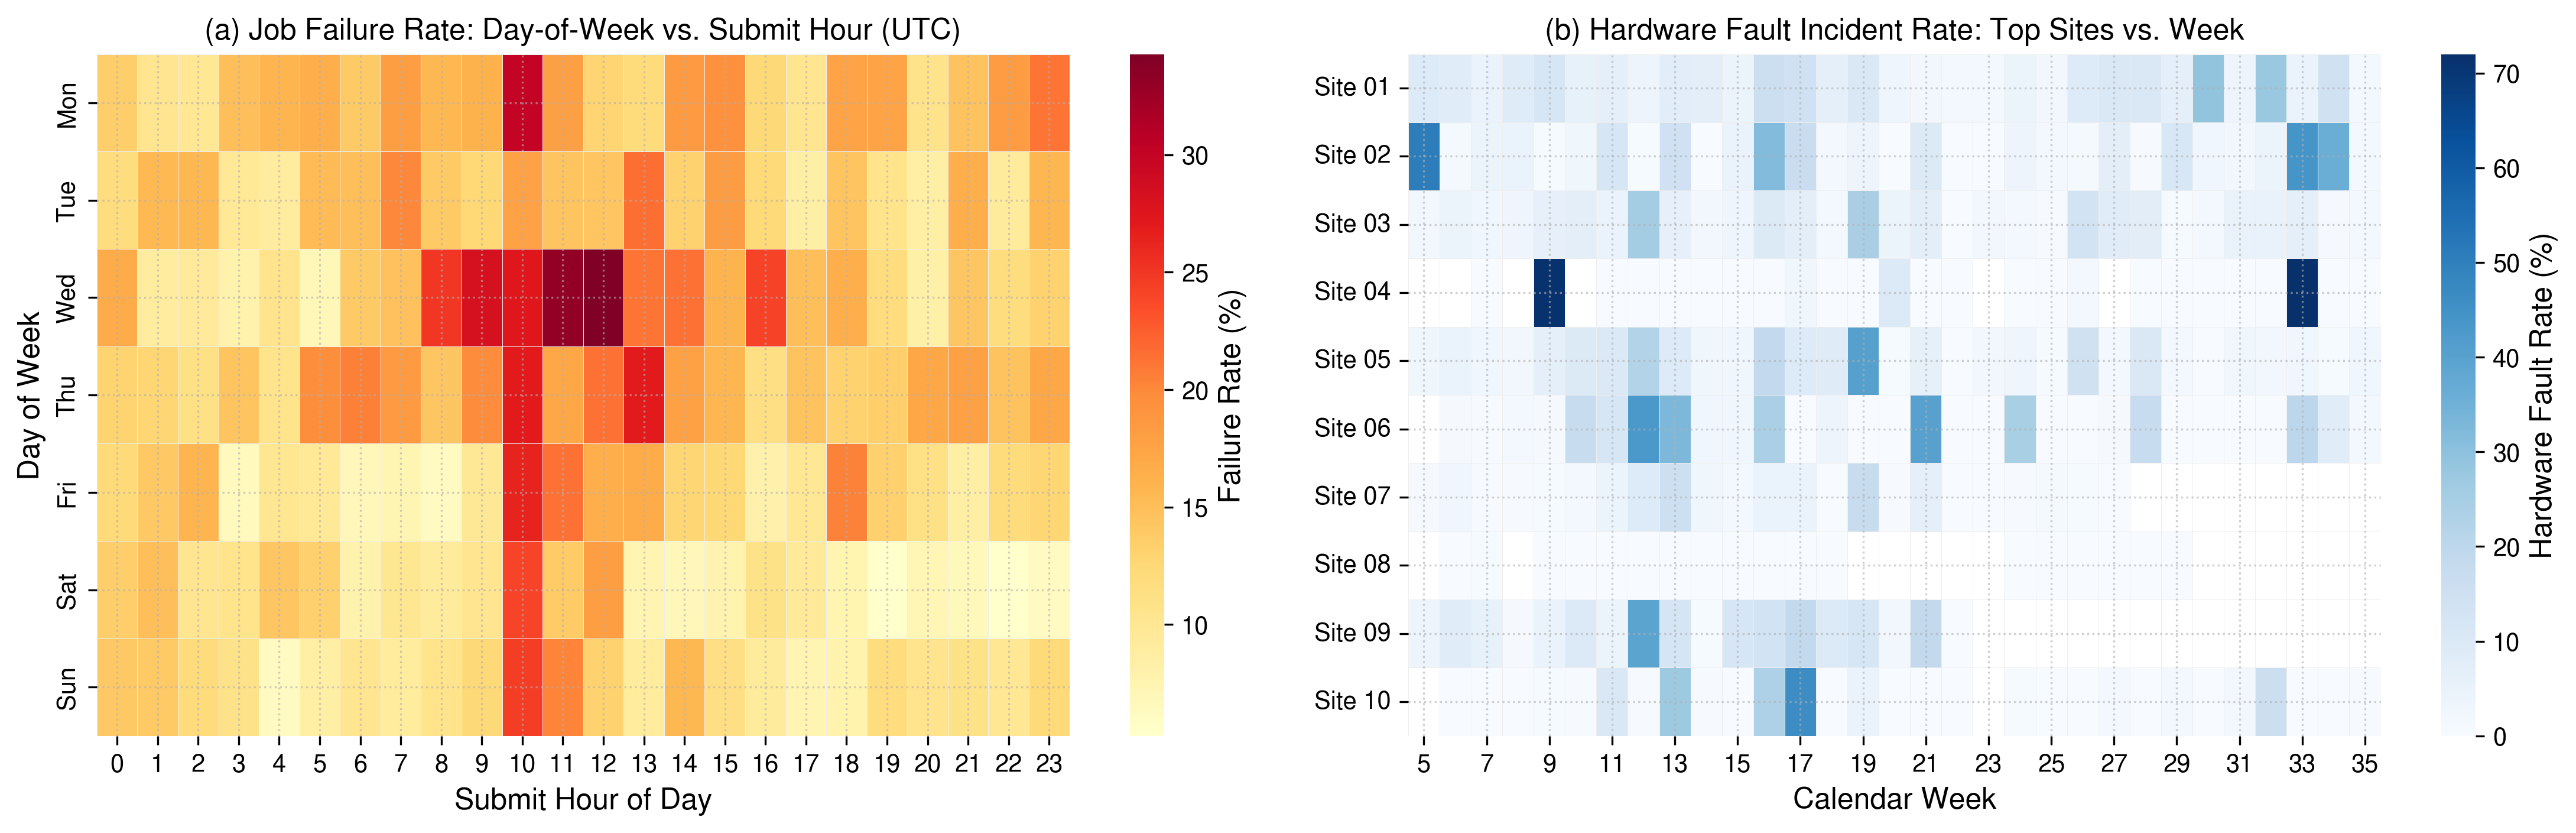

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from vis.style import apply_style, COLORS, COMPONENTS, save_fig
apply_style()

SITECOL = "MATCH_EXP_JOB_GLIDEIN_Site"
qcol = "QDate_ms"


PAL = {"fail": COLORS["secondary"], "hw": COLORS["primary"], "jobs": COMPONENTS[0]}

def sc(f):
    try:
        return f.collect(engine="streaming")
    except TypeError:
        return f.collect(streaming=True)


_sch = lf.collect_schema()


def _sec(c):
    if isinstance(_sch[c], pl.Datetime):
        return pl.col(c).dt.epoch("s").cast(pl.Float64)
    v = pl.col(c).cast(pl.Float64, strict=False)
    return (
        pl.when(v > 1e17)
        .then(v / 1e9)
        .when(v > 1e14)
        .then(v / 1e6)
        .when(v > 1e11)
        .then(v / 1e3)
        .otherwise(v)
    )


# Extract temporal components
dtq = pl.from_epoch(_sec(qcol).cast(pl.Int64), time_unit="s")
lfz = lf.with_columns(
    [
        dtq.dt.hour().alias("hour"),
        dtq.dt.weekday().alias("dow"),
        dtq.dt.week().alias("week"),
    ]
)

hd_df = sc(
    lfz.group_by(["dow", "hour"]).agg(
        (pl.col("Failed").mean() * 100.0).alias("fail_rate")
    )
).to_pandas()

hd_pivot = hd_df.pivot(
    index="dow", columns="hour", values="fail_rate"
).sort_index()

# Map integer DOW (1-7) to abbreviated day names
dow_map = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun",
}
hd_pivot.index = [dow_map.get(i, i) for i in hd_pivot.index]

# Extract top 10 sites by total job volume
tops_raw = sc(
    lf.filter(pl.col(SITECOL).is_not_null())
    .group_by(SITECOL)
    .len()
    .sort("len", descending=True)
    .head(10)
)[SITECOL].to_list()

# Create anonymization dictionary (Site 01, Site 02, ...)
site_anonymizer = {site: f"Site {i+1:02d}" for i, site in enumerate(tops_raw)}

sw_df = sc(
    lfz.filter(pl.col(SITECOL).is_in(tops_raw))
    .group_by([SITECOL, "week"])
    .agg(
        (
            pl.col("hw_fault").filter(pl.col("fault_type") >= 0).mean() * 100.0
        ).alias("hw_rate")
    )
).to_pandas()

sw_pivot = sw_df.pivot(index=SITECOL, columns="week", values="hw_rate")

# Rename index to anonymized site labels
sw_pivot.index = [site_anonymizer.get(s, s) for s in sw_pivot.index]
sw_pivot = sw_pivot.sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8), dpi=300)

# Heatmap A: Submission Temporal Patterns
sns.heatmap(
    hd_pivot,
    ax=ax[0],
    cmap="YlOrRd",
    linewidths=0.2,
    linecolor=COLORS["gridline"],
    cbar_kws={"label": "Failure Rate (%)"},
)
ax[0].set_title("(a) Job Failure Rate: Day-of-Week vs. Submit Hour (UTC)")
ax[0].set_xlabel("Submit Hour of Day")
ax[0].set_ylabel("Day of Week")

# Heatmap B: Site Hardware Fault Rate Over Time
sns.heatmap(
    sw_pivot,
    ax=ax[1],
    cmap="Blues",
    linewidths=0.2,
    linecolor=COLORS["gridline"],
    cbar_kws={"label": "Hardware Fault Rate (%)"},
)
ax[1].set_title(
    "(b) Hardware Fault Incident Rate: Top Sites vs. Week"
)
ax[1].set_xlabel("Calendar Week")
ax[1].set_ylabel("")

plt.tight_layout()
print(save_fig(fig, "failure_cyclical_and_site_bursts"))
plt.show()

### Queue wait time analysis

output/wait_time_distribution.pdf


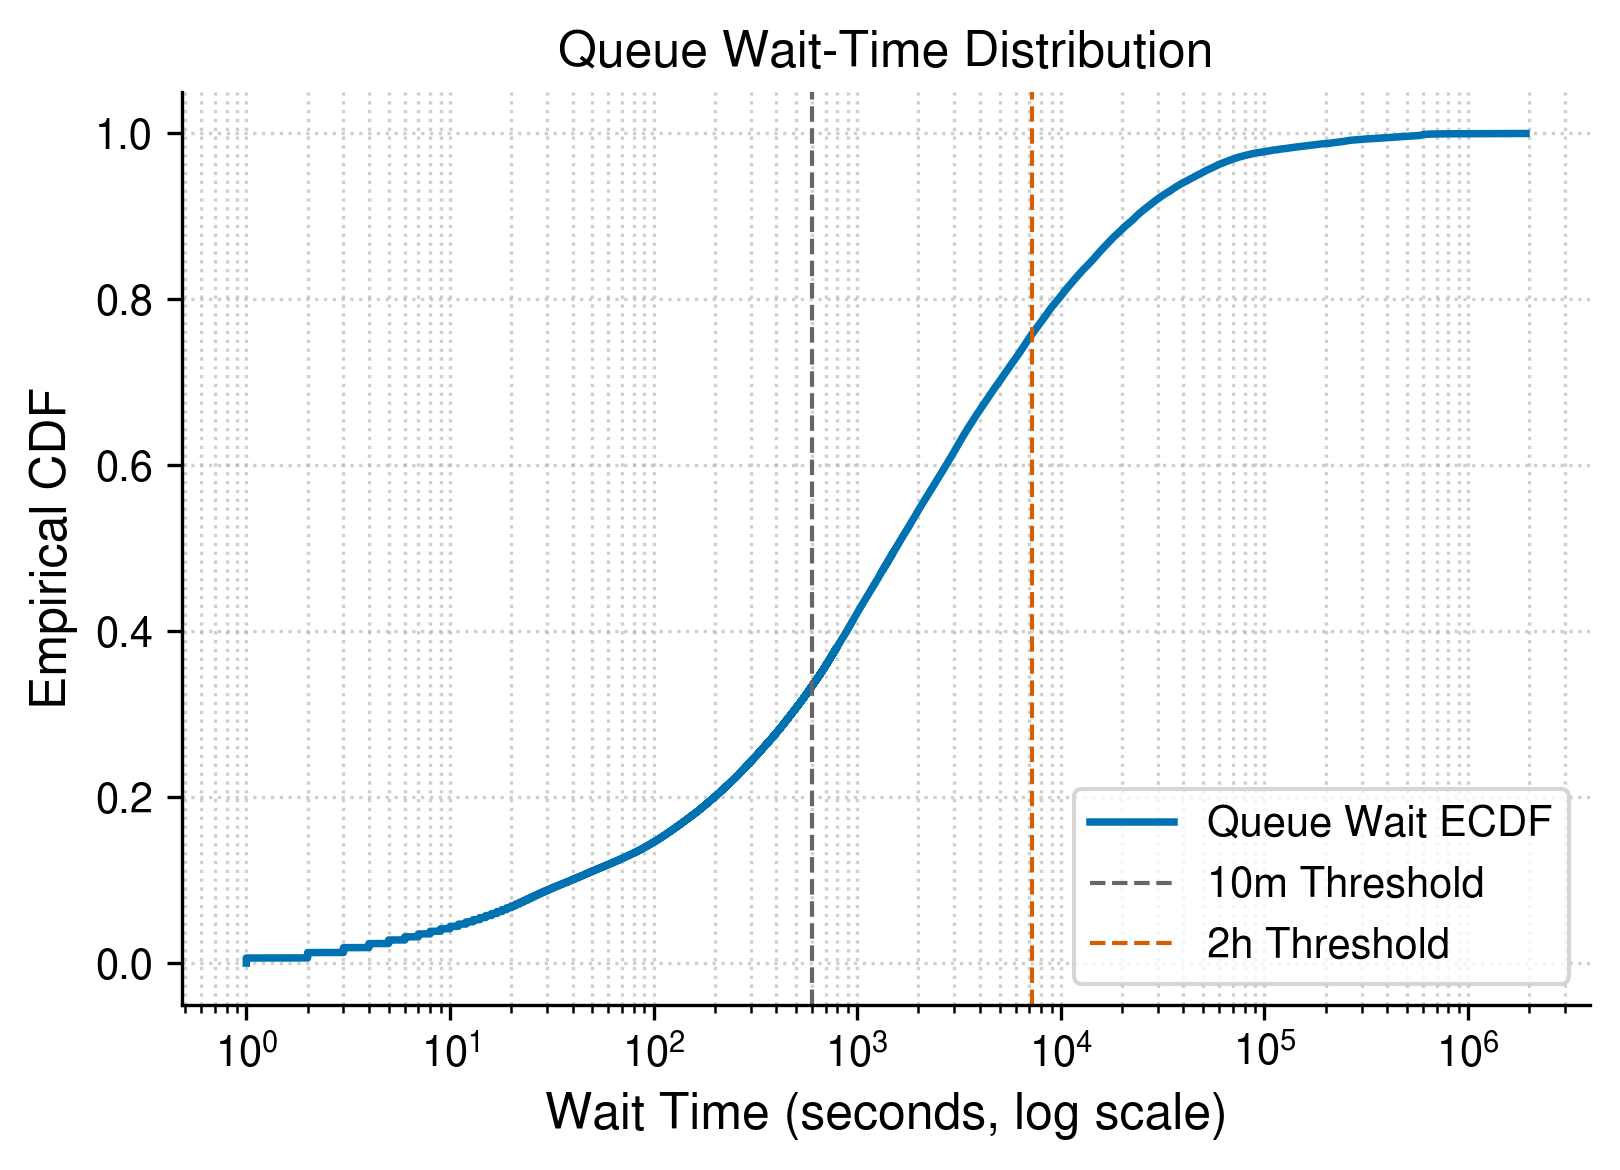

In [14]:
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

fig, ax = plt.subplots(figsize=(5.5, 4), dpi=300)

df_wait = (
    lf.select(pl.col("wait_s"))
    .drop_nulls()
    .filter(pl.col("wait_s") > 0)
    .collect()
)
wait_s = df_wait["wait_s"].to_numpy()
sorted_wait = np.sort(wait_s)
cdf = np.arange(1, len(sorted_wait) + 1) / len(sorted_wait)

ax.plot(sorted_wait, cdf, color=COLORS["primary"], linewidth=1.8, label="Queue Wait ECDF")
ax.set_xscale("log")

ax.axvline(600, color=COLORS["neutral"], linestyle="--", linewidth=1, label="10m Threshold")
ax.axvline(7200, color=COLORS["danger"], linestyle="--", linewidth=1, label="2h Threshold")

ax.set_xlabel("Wait Time (seconds, log scale)")
ax.set_ylabel("Empirical CDF")
ax.set_title("Queue Wait-Time Distribution")
ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(loc="lower right")

plt.tight_layout()
print(save_fig(fig, "wait_time_distribution"))
plt.show()

In [15]:
null_breakdown = (
    lf.filter(pl.col("wait_s").is_null())
    .group_by(["JobStatus", "ExitCode", "ExitSignal"]) 
    .agg(count=pl.len())
    .with_columns(percentage=(pl.col("count") / 7_610_397) * 100)
    .sort("count", descending=True)
    .collect()
)

print(null_breakdown)

shape: (62, 5)
┌───────────┬──────────┬────────────┬─────────┬────────────┐
│ JobStatus ┆ ExitCode ┆ ExitSignal ┆ count   ┆ percentage │
│ ---       ┆ ---      ┆ ---        ┆ ---     ┆ ---        │
│ i64       ┆ i64      ┆ i64        ┆ u32     ┆ f64        │
╞═══════════╪══════════╪════════════╪═════════╪════════════╡
│ 3         ┆ null     ┆ null       ┆ 7170706 ┆ 94.222496  │
│ 4         ┆ 0        ┆ null       ┆ 398693  ┆ 5.238794   │
│ 4         ┆ 20       ┆ null       ┆ 12726   ┆ 0.167219   │
│ 4         ┆ 21       ┆ null       ┆ 11495   ┆ 0.151043   │
│ 4         ┆ 1        ┆ null       ┆ 5688    ┆ 0.07474    │
│ …         ┆ …        ┆ …          ┆ …       ┆ …          │
│ 4         ┆ 2        ┆ null       ┆ 1       ┆ 0.000013   │
│ 4         ┆ 0        ┆ 7          ┆ 1       ┆ 0.000013   │
│ 4         ┆ 124      ┆ null       ┆ 1       ┆ 0.000013   │
│ 3         ┆ 255      ┆ 15         ┆ 1       ┆ 0.000013   │
│ 4         ┆ 127      ┆ 9          ┆ 1       ┆ 0.000013   │
└────────

In [16]:
short_wait_stats = (
    lf.filter((pl.col("wait_s") > 0) & (pl.col("wait_s") <= 60))
    .select(
        total_under_1min=pl.len(),
        sub_1s=(pl.col("wait_s") <= 1).sum(),
        sub_5s=((pl.col("wait_s") > 1) & (pl.col("wait_s") <= 5)).sum(),
        sub_10s=((pl.col("wait_s") > 5) & (pl.col("wait_s") <= 10)).sum(),
        sub_30s=((pl.col("wait_s") > 10) & (pl.col("wait_s") <= 30)).sum(),
        sub_60s=((pl.col("wait_s") > 30) & (pl.col("wait_s") <= 60)).sum(),
    )
    .collect()
)

print("Short Wait Time Granular Breakdown:")
print(short_wait_stats)

sub_1s_breakdown = (
    lf.filter((pl.col("wait_s") > 0) & (pl.col("wait_s") <= 1))
    .group_by(["JobStatus", "ExitCode"]) 
    .agg(count=pl.len())
    .sort("count", descending=True)
    .head(10)
    .collect()
)

print("\nSub-Second Job Attributes:")
print(sub_1s_breakdown)

Short Wait Time Granular Breakdown:
shape: (1, 6)
┌──────────────────┬────────┬─────────┬─────────┬─────────┬─────────┐
│ total_under_1min ┆ sub_1s ┆ sub_5s  ┆ sub_10s ┆ sub_30s ┆ sub_60s │
│ ---              ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ u32              ┆ u32    ┆ u32     ┆ u32     ┆ u32     ┆ u32     │
╞══════════════════╪════════╪═════════╪═════════╪═════════╪═════════╡
│ 6729041          ┆ 342974 ┆ 1225546 ┆ 926125  ┆ 2494329 ┆ 1740067 │
└──────────────────┴────────┴─────────┴─────────┴─────────┴─────────┘

Sub-Second Job Attributes:
shape: (10, 3)
┌───────────┬──────────┬────────┐
│ JobStatus ┆ ExitCode ┆ count  │
│ ---       ┆ ---      ┆ ---    │
│ i64       ┆ i64      ┆ u32    │
╞═══════════╪══════════╪════════╡
│ 4         ┆ 0        ┆ 303603 │
│ 4         ┆ 21       ┆ 16121  │
│ 4         ┆ 1        ┆ 7547   │
│ 4         ┆ 20       ┆ 4209   │
│ 3         ┆ null     ┆ 3483   │
│ 4         ┆ 127      ┆ 1833   │
│ 4         ┆ 88       ┆ 1694   │
│ 4      

### Exit code analysis

output/exit_codes_distribution.pdf


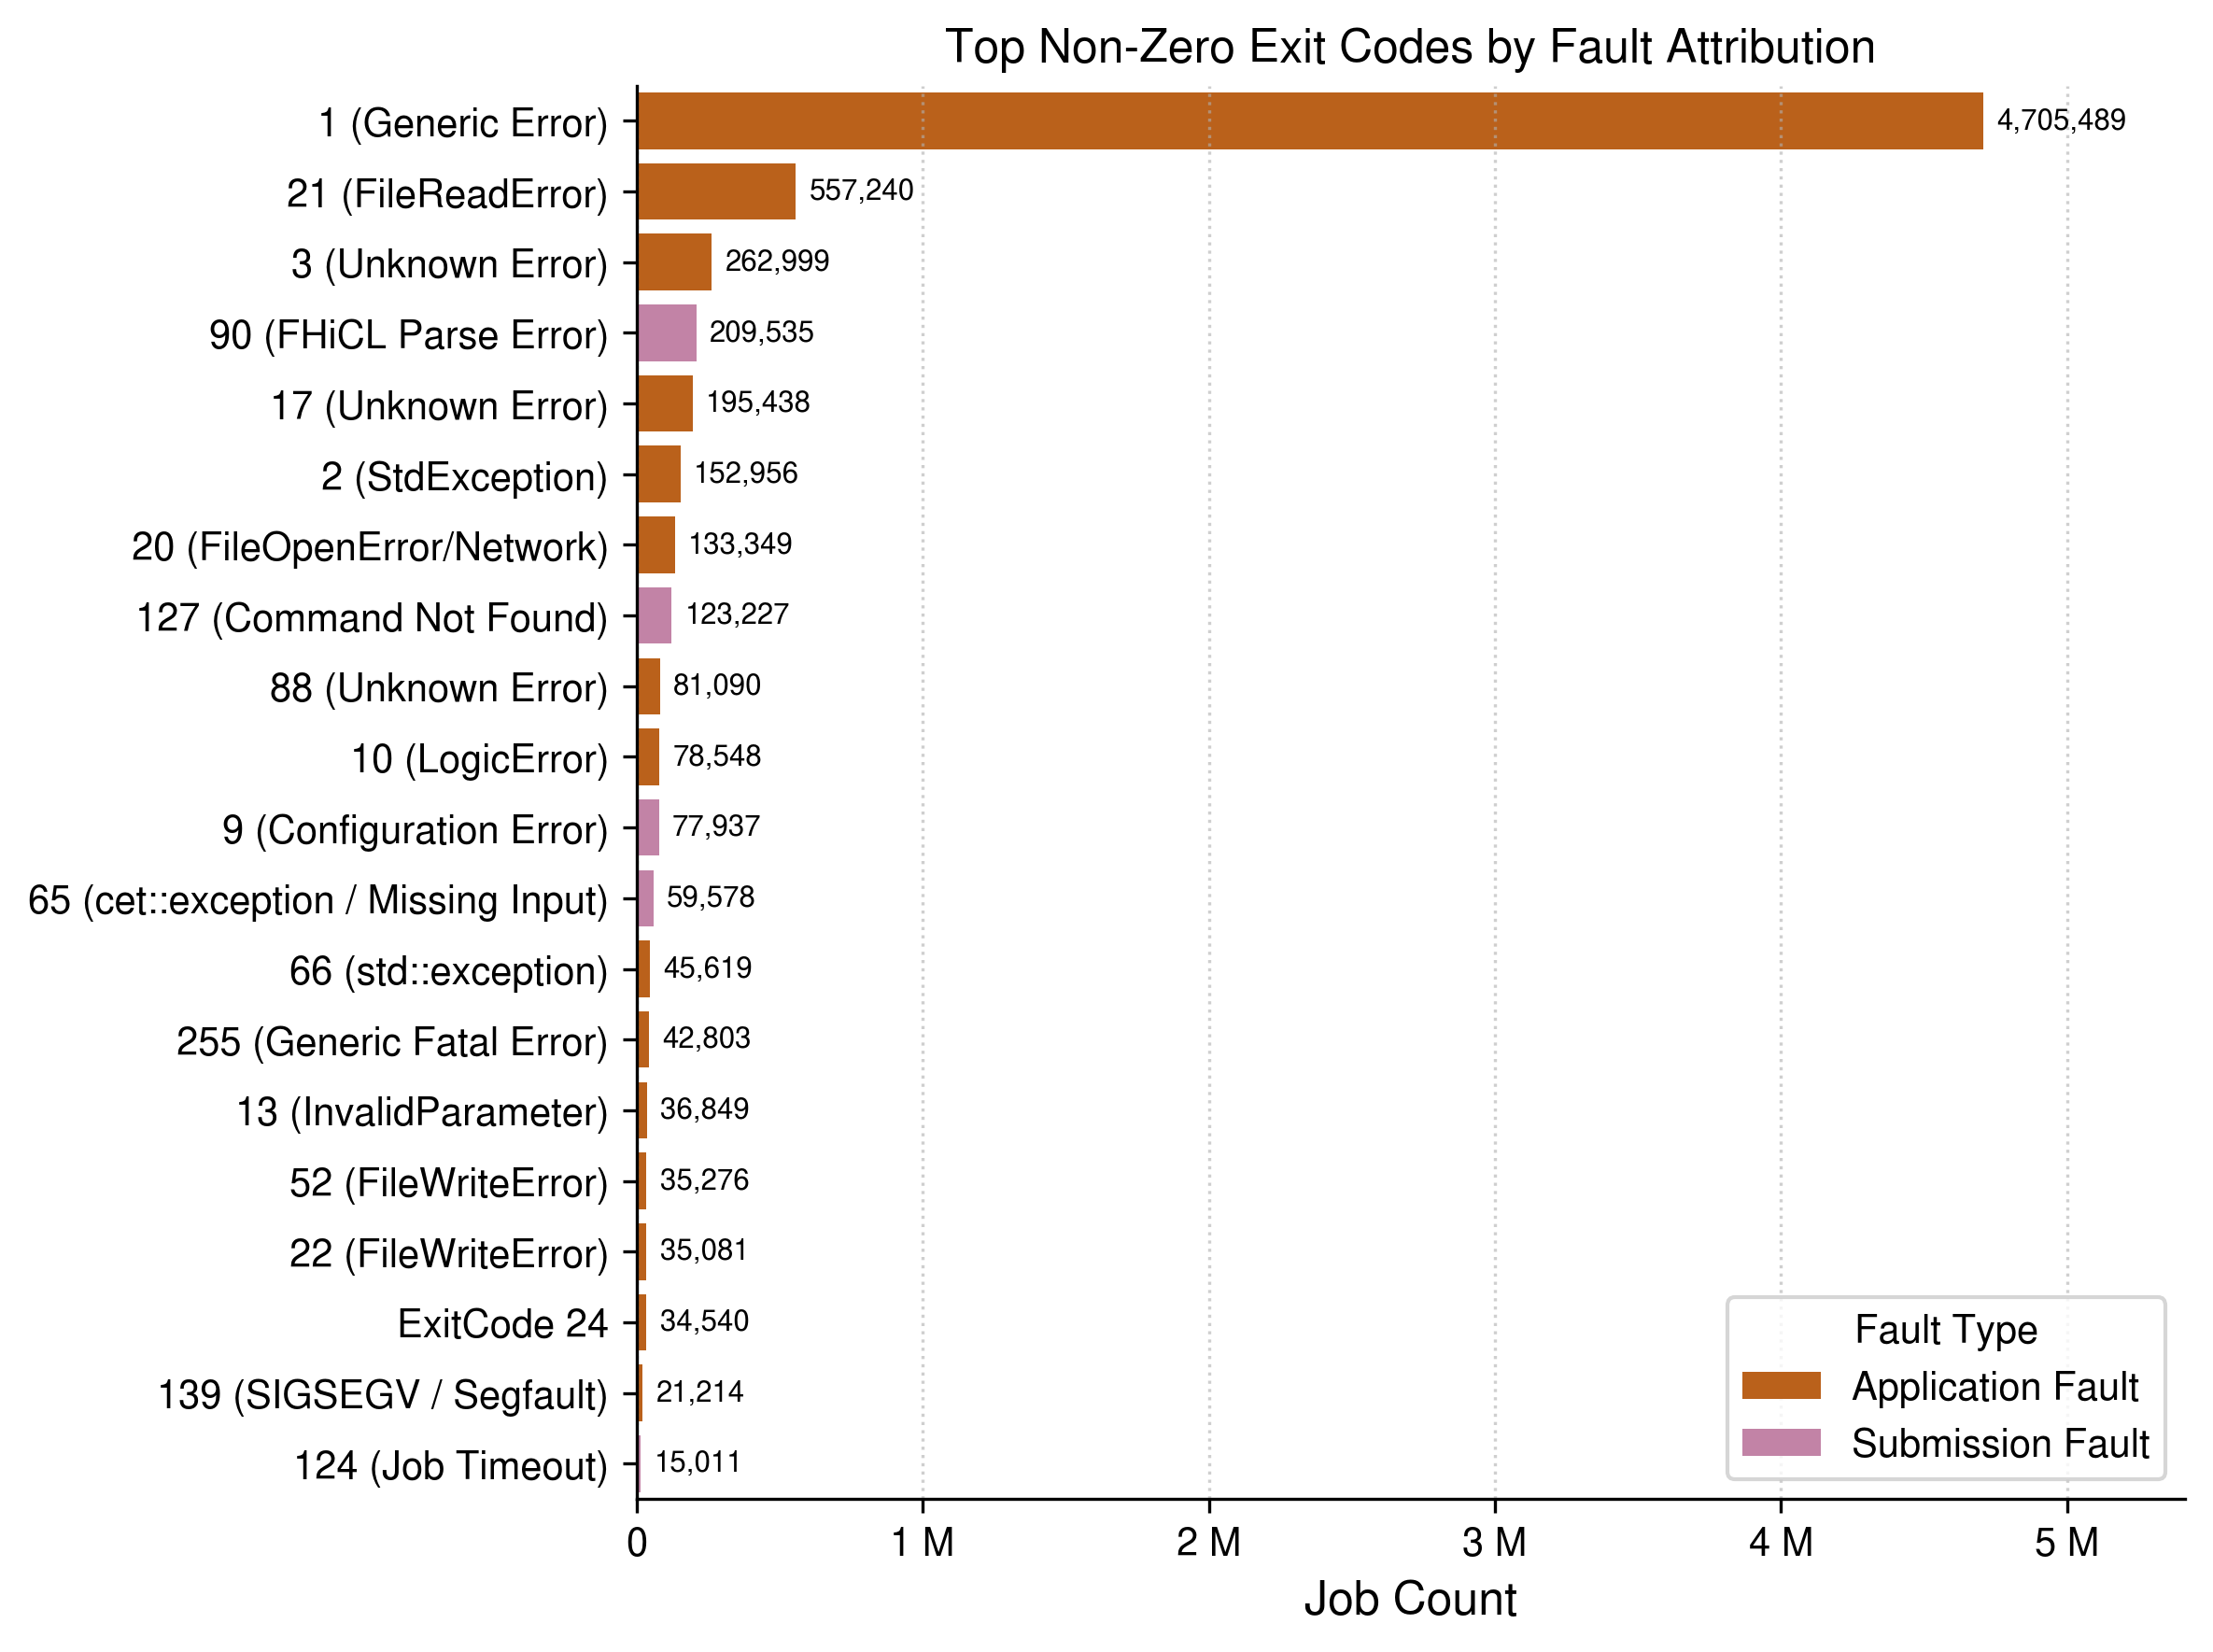

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

# README Exit Code Description Mapping
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

labels = {
    "1": "1 (Generic Error)",
    "2": "2 (StdException)",
    "3": "3 (Unknown Error)",
    "4": "4 (BadAlloc)",
    "5": "5 (BadExceptionType)",
    "6": "6 (ProductNotFound)",
    "9": "9 (Configuration Error)",
    "10": "10 (LogicError)",
    "11": "11 (UnimplementedFeature)",
    "12": "12 (InvalidReference)",
    "13": "13 (InvalidParameter)",
    "14": "14 (NullPointerError)",
    "15": "15 (EventTimeout)",
    "16": "16 (DataCorruption)",
    "17": "17 (Unknown Error)",
    "20": "20 (FileOpenError/Network)",
    "21": "21 (FileReadError)",
    "22": "22 (FileWriteError)",
    "52": "52 (FileWriteError)",
    "65": "65 (cet::exception / Missing Input)",
    "66": "66 (std::exception)",
    "68": "68 (std::bad_alloc)",
    "88": "88 (Unknown Error)",
    "90": "90 (FHiCL Parse Error)",
    "91": "91 (FHiCL Parameter Error)",
    "124": "124 (Job Timeout)",
    "126": "126 (Command Cannot Execute)",
    "127": "127 (Command Not Found)",
    "129": "129 (SIGHUP / Lost Session)",
    "130": "130 (SIGINT / Interrupted)",
    "131": "131 (SIGQUIT)",
    "134": "134 (SIGABRT / Self-Abort)",
    "137": "137 (SIGKILL / OOM Timeout)",
    "139": "139 (SIGSEGV / Segfault)",
    "143": "143 (SIGTERM / Node Drain)",
    "255": "255 (Generic Fatal Error)",
}

# Code-table classification rules
EXIT_SUB = {9, 65, 90, 91, 124, 126, 127, 130, 131, 137}
EXIT_HW = {129, 143}


def get_fault_category(code):
    if code in EXIT_HW:
        return "Hardware Fault"
    elif code in EXIT_SUB:
        return "Submission Fault"
    return "Application Fault"


FAULT_PALETTE = {
    "Application Fault": COLORS["secondary"],   # application
    "Submission Fault": COMPONENTS[1],         # submission
    "Hardware Fault": COMPONENTS[0],         # hardware
}

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

df_ec = (
    lf.filter((pl.col("ExitCode") != 0) & pl.col("ExitCode").is_not_null())
    .group_by("ExitCode")
    .len()
    .sort("len", descending=True)
    .head(20)
    .collect()
    .to_pandas()
)

df_ec["Label"] = df_ec["ExitCode"].map(
    lambda x: labels.get(str(x), f"ExitCode {x}")
)
df_ec["Fault Category"] = df_ec["ExitCode"].map(get_fault_category)

sns.barplot(
    data=df_ec,
    y="Label",
    x="len",
    hue="Fault Category",
    dodge=False,
    palette=FAULT_PALETTE,
    ax=ax,
)

max_val = df_ec["len"].max()
for i, count in enumerate(df_ec["len"]):
    ax.text(
        count + (max_val * 0.01),
        i,
        f"{count:,}",
        va="center",
        fontsize=7.5,
    )

ax.set_xlim(0, max_val * 1.15)
ax.set_xlabel("Job Count")
ax.set_ylabel("")
ax.set_title("Top Non-Zero Exit Codes by Fault Attribution")
ax.grid(True, axis="x", linestyle=":", alpha=0.6)
ax.xaxis.set_major_formatter(ticker.EngFormatter())

# Clean legend positioning
ax.legend(title="Fault Type", loc="lower right", frameon=True)

plt.tight_layout()
print(save_fig(fig, "exit_codes_distribution"))
plt.show()

### Workload characterisation

Three motivation figures over the full window, alongside the queue-wait
distribution above: how long jobs actually run, what kind of work the system
carries, and how often failures arrive at each execution site.

These read the post-feature-engineering Parquet rather than `lf`, because
`DerivedCampaignType` and `fault_type` are produced in `feat-engineering.ipynb`
and are not present in the raw scan built at the top of this notebook.

In [3]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig

# Anonymised extract written by feat-engineering.ipynb (cell `da1094d8`). Identifier
# columns -- Owner, groups, campaigns, hostnames, ClusterId -- are Int32 hashes using
# the same seed as cat_expr(), so they line up with the codes in Xmatch/Xsub. Site
# names and DerivedCampaignType stay readable. The file this replaces was named
# "_anon_" but carried real usernames and hostnames; it is now under datasets/old/.
ANON_PARQUET = "/media/storage0/allison/FIFE-Batch-Queues-anon/fife_anon_2025-02-01_2025-09-01.parquet"
WINDOW_START = dt.datetime(2025, 2, 1)
SITECOL = "MATCH_EXP_JOB_GLIDEIN_Site"

lf_anon = pl.scan_parquet(ANON_PARQUET)

apply_style()
# Aliases kept so the figure cells below read unchanged.
BASE_COLOR = COLORS["bar_fill"]
ACCENT_COLOR = COLORS["secondary"]

print(f"scanning {ANON_PARQUET}")
print(lf_anon.select(n=pl.len()).collect())

scanning /media/storage0/allison/FIFE-Batch-Queues-anon/fife_anon_2025-02-01_2025-09-01.parquet
shape: (1, 1)
┌──────────┐
│ n        │
│ ---      │
│ u32      │
╞══════════╡
│ 64088358 │
└──────────┘


In [5]:
from vis.style import apply_style, COLORS, COMPONENTS, save_fig
apply_style()

BASE_COLOR = COLORS["bar_fill"]

# df_wait = (
#     lf.select(pl.col("wait_s"))
#     .drop_nulls()
#     .filter(pl.col("wait_s") > 0)
#     .collect()
# )

# wait_s = df_wait["wait_s"].to_numpy()
# wt_min = wait_s[wait_s > 0] / 60.0 

df_all = lf.select(pl.col("wait_s")).collect()
total_jobs = len(df_all)
null_jobs= (df_all["wait_s"].is_null()).sum()
zero_jobs = (df_all["wait_s"] == 0).sum()
neg_jobs = (df_all["wait_s"] < 0).sum()

wt_pos_s = df_all.filter(pl.col("wait_s") > 1)["wait_s"].to_numpy()
wt_min = wt_pos_s / 60.0

mean_min = wt_min.mean()
median_min = np.median(wt_min)

Log scale

output/wait_time_distribution_log.pdf


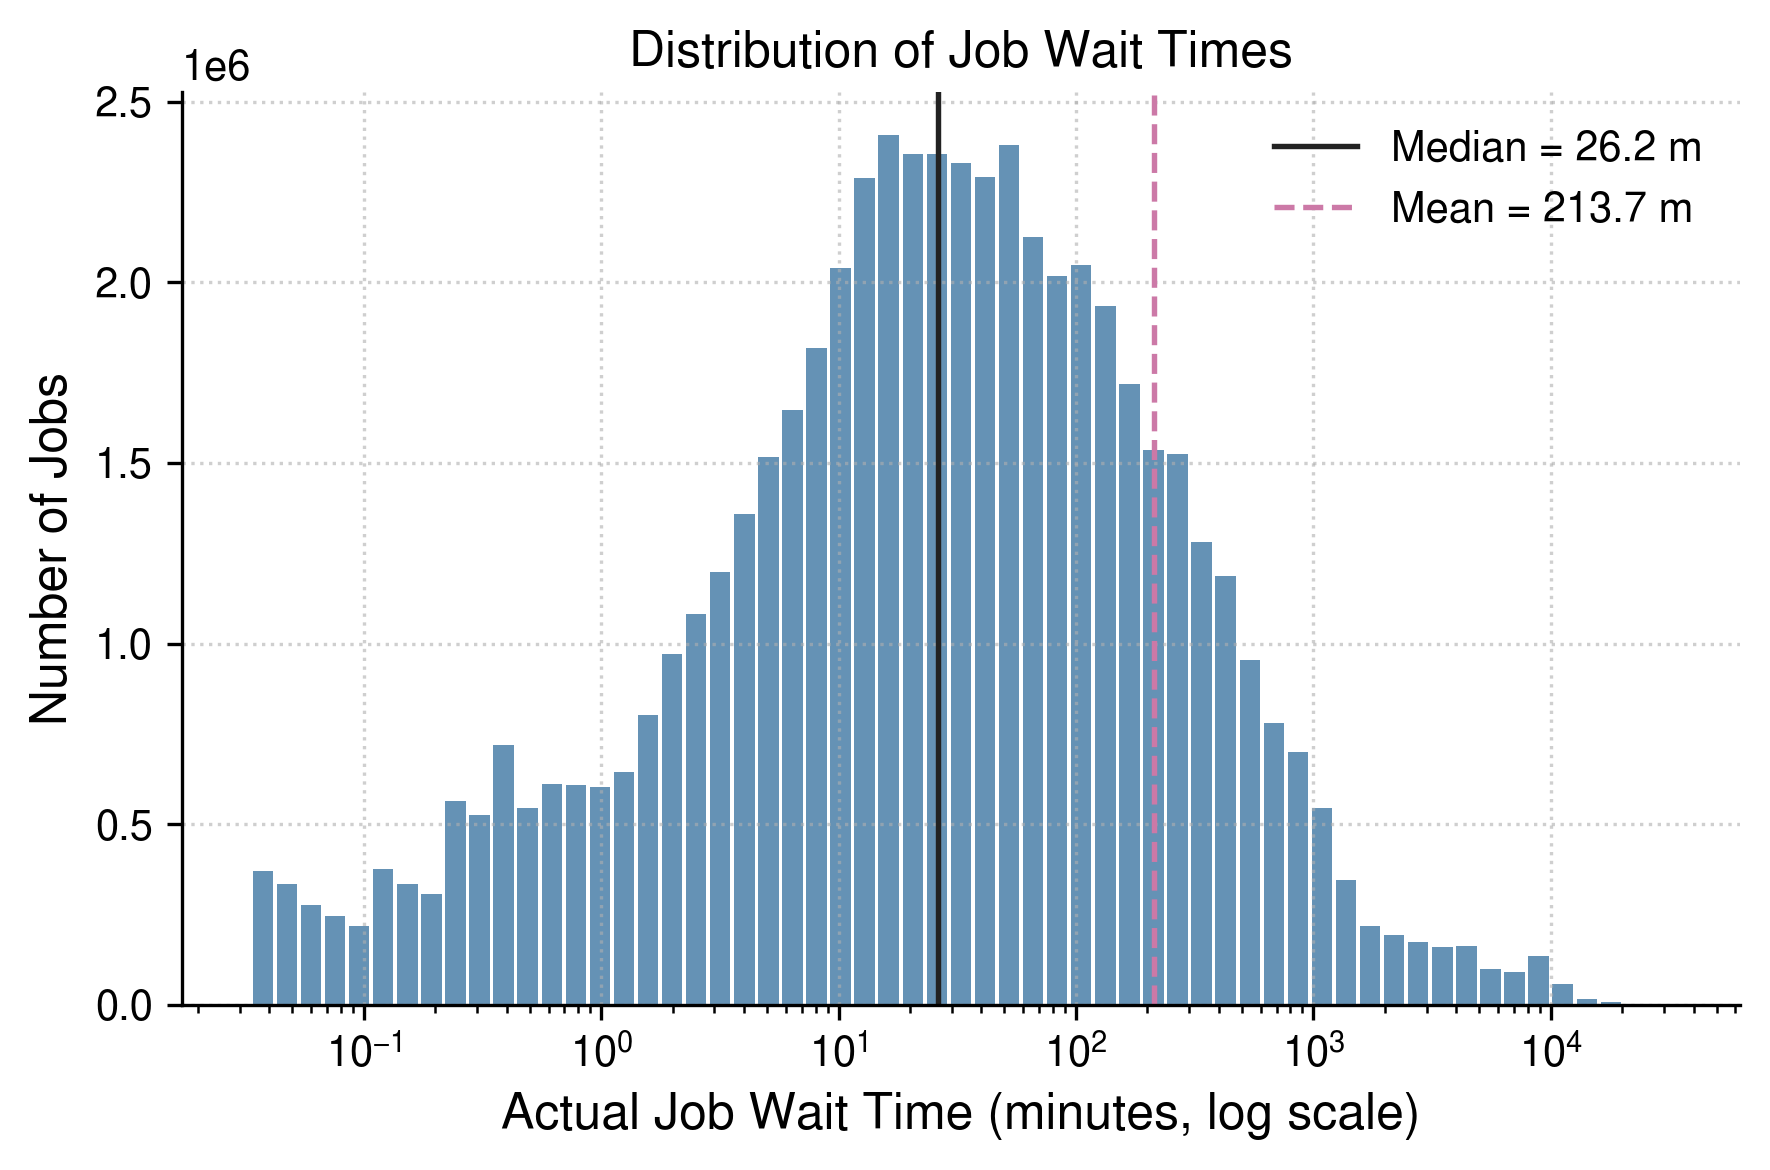

n = 56,133,169 jobs with wait time > 0
  p10 =        0.8 min
  p25 =        5.5 min
  p50 =       26.2 min
  p75 =      115.2 min
  p90 =      392.9 min
  p99 =    3,968.7 min


In [6]:
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
bins = np.logspace(np.log10(max(wt_min.min(), 0.01)), np.log10(wt_min.max()), 60)
ax.hist(wt_min, bins=bins, color=BASE_COLOR, alpha=0.85, rwidth=0.85)
ax.set_xscale("log")
ax.axvline(median_min, color=COLORS["baseline"], linewidth=1.3, label=f"Median = {median_min:,.1f} m")
ax.axvline(mean_min, color=COLORS["band"], linestyle="--", linewidth=1.3, label=f"Mean = {mean_min:,.1f} m")

ax.set_xlabel("Actual Job Wait Time (minutes, log scale)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Distribution of Job Wait Times")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
print(save_fig(fig, "wait_time_distribution_log"))
plt.show()

print(f"n = {len(wt_min):,} jobs with wait time > 0")
for q in (10, 25, 50, 75, 90, 99):
    print(f"  p{q:<2d} = {np.percentile(wt_min, q):10,.1f} min")

Linear scale

In [1]:
# Linear-scale companion to the log-scale figure above.
#
# A linear axis needs EVENLY spaced bins -- np.linspace, not np.logspace. Log-spaced
# bins on a linear axis give bars whose on-screen width varies by orders of
# magnitude, so bar area stops meaning "count"; that is worse than either consistent
# choice. It is also why the log version keeps its logspace bins.
#
# Outliers are clipped at the LINEAR_CLIP percentile. This is presentation only: the
# tail is real, not erroneous, and the log figure above shows it in full. The
# printout states how many jobs the axis excludes so the cut is never silent.
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

LINEAR_CLIP = 91.0
N_BINS_LINEAR = 60

_clip = np.percentile(wt_min, LINEAR_CLIP)
_shown = wt_min[wt_min <= _clip]

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.hist(_shown, bins=np.linspace(0, _clip, N_BINS_LINEAR + 1),
        color=BASE_COLOR, alpha=0.85, rwidth=0.85)
ax.set_xlim(0, _clip)
ax.axvline(median_min, color=COLORS["baseline"], linewidth=1.3, label=f"Median = {median_min:,.1f} m")
ax.axvline(mean_min, color=COLORS["band"], linestyle="--", linewidth=1.3, label=f"Mean = {mean_min:,.1f} m")

ax.set_xlabel("Actual Job Wait Time (minutes, linear scale)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Distribution of Job Wait Times")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
print(save_fig(fig, "wait_time_distribution_linear"))
plt.show()

_n_out = len(wt_min) - len(_shown)
print(f"n = {len(wt_min):,} jobs with wait time > 0")
print(f"axis clipped at p{LINEAR_CLIP:g} = {_clip:,.1f} min; "
      f"{_n_out:,} jobs ({_n_out / len(wt_min) * 100:.2f}%) fall beyond it, "
      f"up to {wt_min.max():,.0f} min")
print(f"bin width = {_clip / N_BINS_LINEAR:,.2f} min (even)")
for q in (10, 25, 50, 75, 90, 99):
    print(f"  p{q:<2d} = {np.percentile(wt_min, q):10,.1f} min")

NameError: name 'np' is not defined

### Job runtime distribution
Log scale

output/runtime_distribution_log.pdf


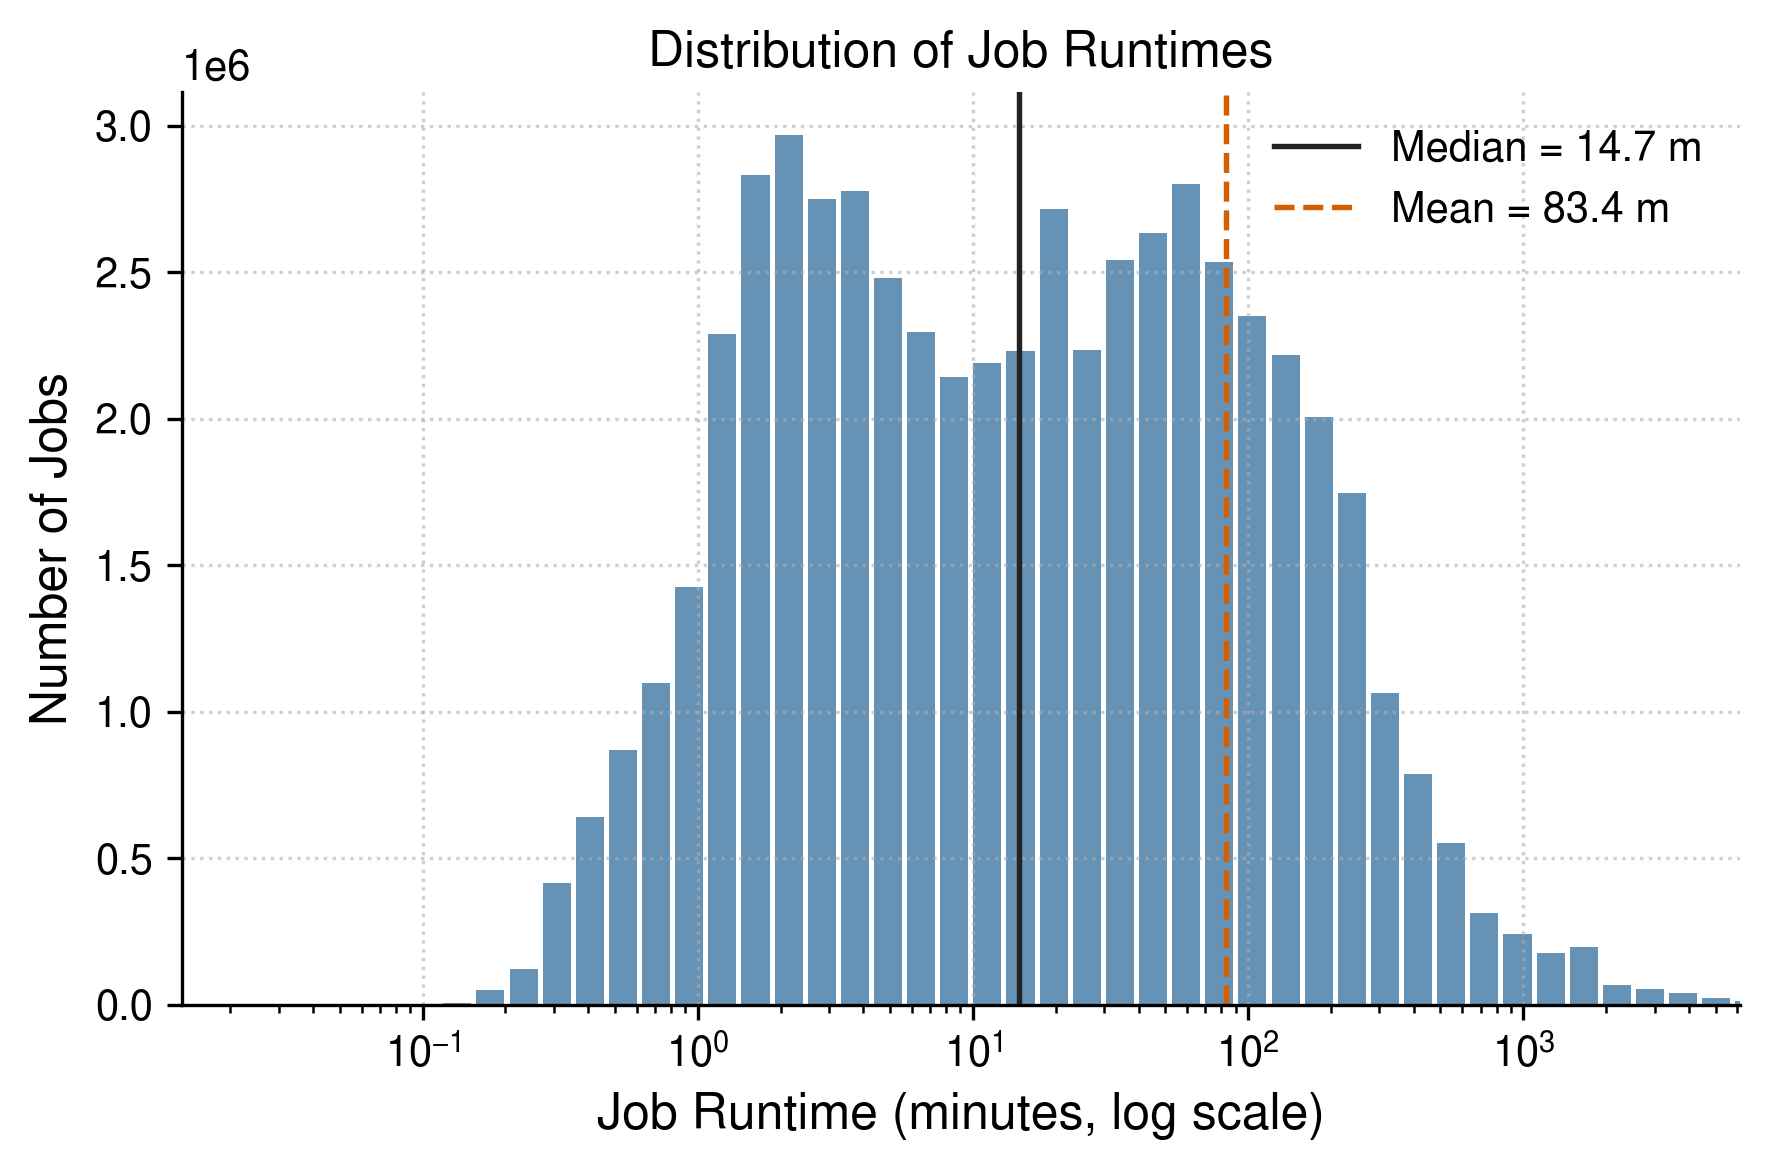

n = 56,911,754 jobs with runtime > 0
  p10 =        1.2 min
  p25 =        2.9 min
  p50 =       14.7 min
  p75 =       69.4 min
  p90 =      195.4 min
  p99 =    1,098.8 min


In [9]:
# Figure: job runtime distribution.
# RemoteWallClockTime accumulates across every execution attempt, so a restarted
# job contributes its total occupancy rather than its last attempt. Zero and null
# values (jobs that never ran, or never reported) are dropped rather than counted
# as instantaneous.
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

rt_s = (
    lf_anon.filter(pl.col("RemoteWallClockTime") > 0)
    .select("RemoteWallClockTime")
    .collect()["RemoteWallClockTime"]
    .to_numpy()
)
rt_min = rt_s / 60.0
median_min, mean_min = np.median(rt_min), rt_min.mean()

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
bins = np.logspace(np.log10(rt_min.min()), np.log10(rt_min.max()), 60)
ax.hist(rt_min, bins=bins, color=BASE_COLOR, alpha=0.85, rwidth=0.85)
ax.set_xscale("log")
# Trim the axis to the bulk; the extreme tail is a handful of jobs and would
# otherwise leave two empty decades on the right.
ax.set_xlim(rt_min.min() * 0.8, np.percentile(rt_min, 99.99))
ax.axvline(median_min, color=COLORS["baseline"], linewidth=1.3, label=f"Median = {median_min:,.1f} m")
ax.axvline(mean_min, color=ACCENT_COLOR, linestyle="--", linewidth=1.3, label=f"Mean = {mean_min:,.1f} m")

ax.set_xlabel("Job Runtime (minutes, log scale)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Distribution of Job Runtimes")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
print(save_fig(fig, "runtime_distribution_log"))
plt.show()

print(f"n = {len(rt_min):,} jobs with runtime > 0")
for q in (10, 25, 50, 75, 90, 99):
    print(f"  p{q:<2d} = {np.percentile(rt_min, q):10,.1f} min")

Linear scale

output/runtime_distribution_linear.pdf


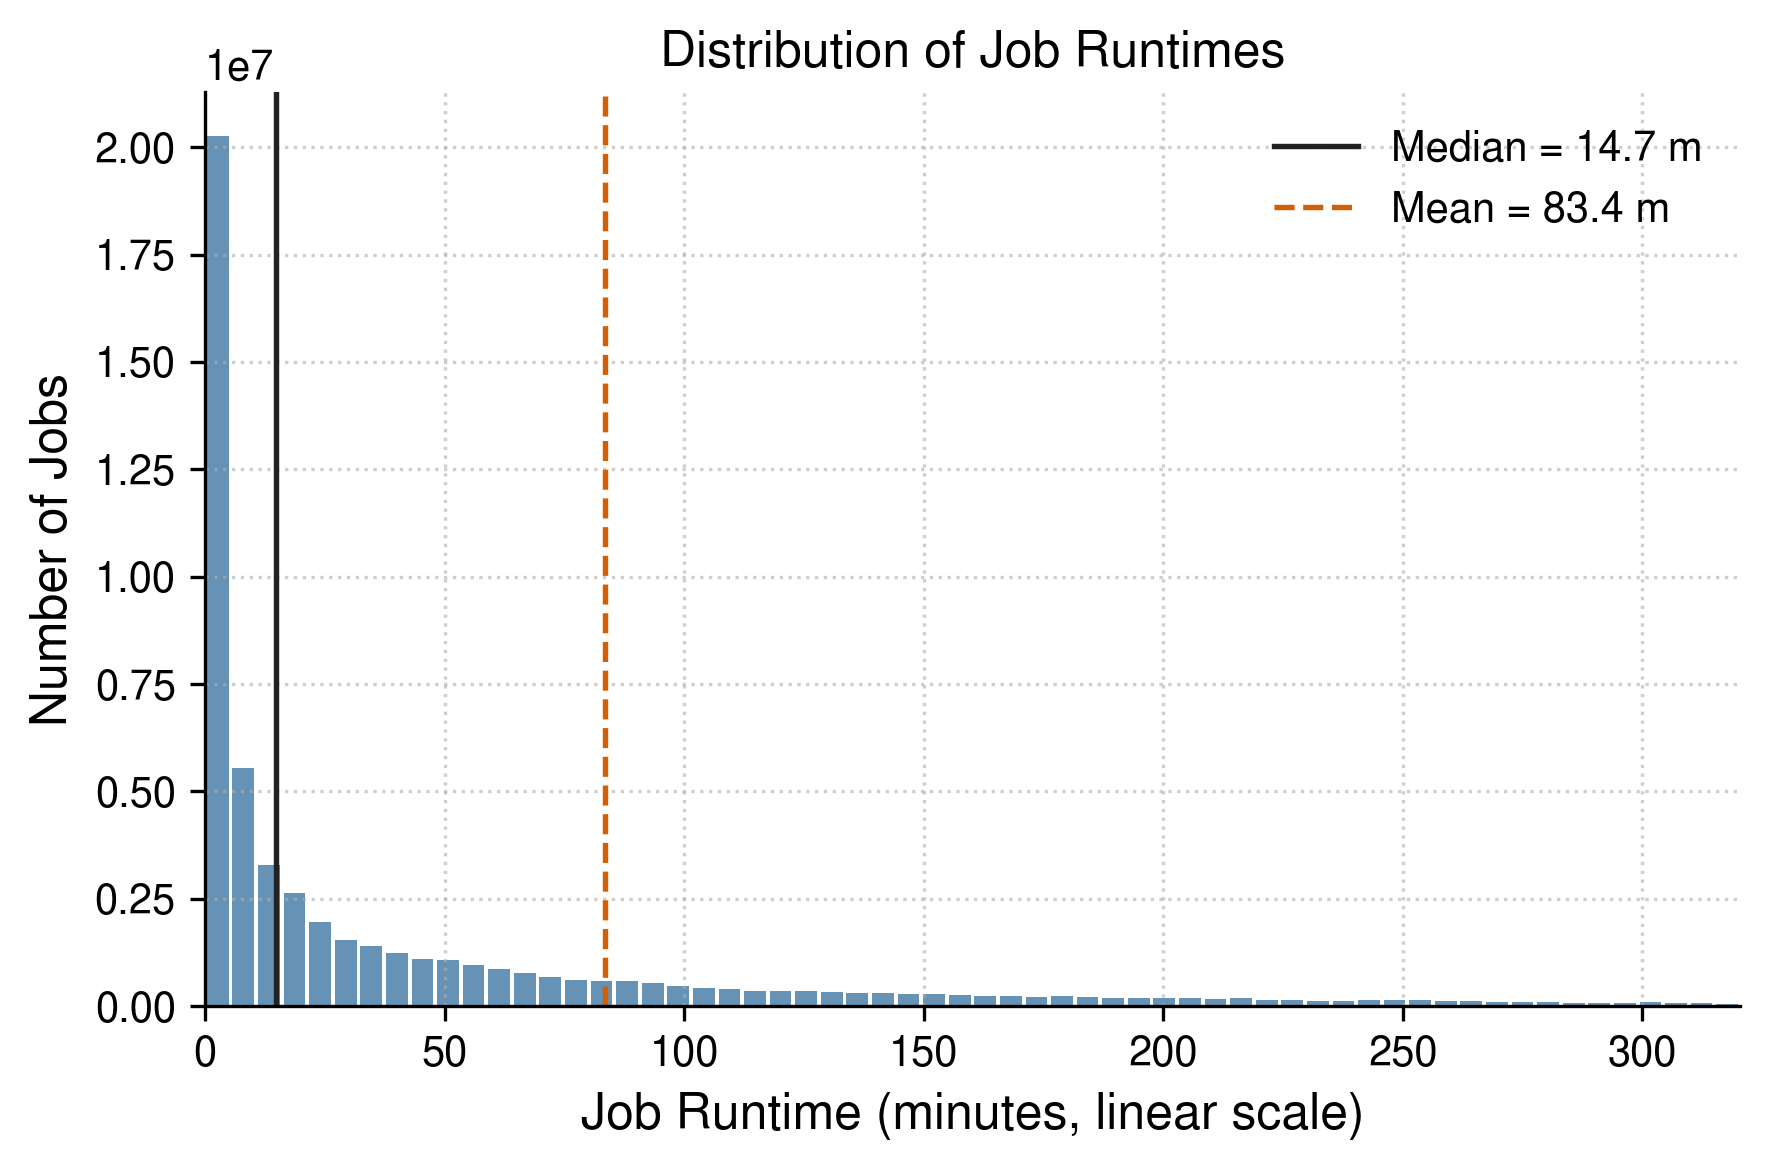

n = 56,911,754 jobs with runtime > 0
axis clipped at p95 = 320.4 min; 2,845,551 jobs (5.00%) fall beyond it, up to 211,659 min
bin width = 5.34 min (even)
  p10 =        1.2 min
  p25 =        2.9 min
  p50 =       14.7 min
  p75 =       69.4 min
  p90 =      195.4 min
  p99 =    1,098.8 min


In [11]:
# Figure: job runtime distribution, linear scale.
# RemoteWallClockTime accumulates across every execution attempt, so a restarted
# job contributes its total occupancy rather than its last attempt. Zero and null
# values (jobs that never ran, or never reported) are dropped rather than counted
# as instantaneous.
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

rt_s = (
    lf_anon.filter(pl.col("RemoteWallClockTime") > 0)
    .select("RemoteWallClockTime")
    .collect()["RemoteWallClockTime"]
    .to_numpy()
)
rt_min = rt_s / 60.0
median_min, mean_min = np.median(rt_min), rt_min.mean()

# Linear-scale companion to the log-scale figure above.
#
# A linear axis needs EVENLY spaced bins -- np.linspace, not np.logspace. Log-spaced
# bins on a linear axis give bars whose on-screen width varies by orders of
# magnitude, so bar area stops meaning "count"; that is worse than either consistent
# choice. It is also why the log version keeps its logspace bins.
#
# Outliers are clipped at the LINEAR_CLIP percentile. This is presentation only: the
# tail is real, not erroneous, and the log figure above shows it in full. The
# printout states how many jobs the axis excludes so the cut is never silent.
LINEAR_CLIP = 95.0
N_BINS_LINEAR = 60

_clip = np.percentile(rt_min, LINEAR_CLIP)
_shown = rt_min[rt_min <= _clip]

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.hist(_shown, bins=np.linspace(0, _clip, N_BINS_LINEAR + 1),
        color=BASE_COLOR, alpha=0.85, rwidth=0.85)
ax.set_xlim(0, _clip)
ax.axvline(median_min, color=COLORS["baseline"], linewidth=1.3, label=f"Median = {median_min:,.1f} m")
ax.axvline(mean_min, color=ACCENT_COLOR, linestyle="--", linewidth=1.3, label=f"Mean = {mean_min:,.1f} m")

ax.set_xlabel("Job Runtime (minutes, linear scale)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Distribution of Job Runtimes")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
print(save_fig(fig, "runtime_distribution_linear"))
plt.show()

_n_out = len(rt_min) - len(_shown)
print(f"n = {len(rt_min):,} jobs with runtime > 0")
print(f"axis clipped at p{LINEAR_CLIP:g} = {_clip:,.1f} min; "
      f"{_n_out:,} jobs ({_n_out / len(rt_min) * 100:.2f}%) fall beyond it, "
      f"up to {rt_min.max():,.0f} min")
print(f"bin width = {_clip / N_BINS_LINEAR:,.2f} min (even)")
for q in (10, 25, 50, 75, 90, 99):
    print(f"  p{q:<2d} = {np.percentile(rt_min, q):10,.1f} min")

In [19]:
lf_anon.collect_schema().names()

['ExitCode',
 'ExitSignal',
 'JobStatus',
 'RemoveReason',
 'LastHoldReason',
 'LastHoldReasonCode',
 'NumJobStarts',
 'NumJobMatches',
 'QDate_ms',
 'JobStartDate_ms',
 'JobCurrentStartDate_ms',
 'JobCurrentStartExecutingDate_ms',
 'CompletionDate',
 'CompletionDate_ms',
 'EnteredCurrentStatus_ms',
 'LastMatchTime_ms',
 'RemoteWallClockTime',
 'x509UserProxyExpiration_ms',
 'Owner',
 'AccountingGroup',
 'POMS4_CAMPAIGN_ID',
 'POMS4_CAMPAIGN_NAME',
 'POMS4_CAMPAIGN_STAGE_NAME',
 'POMS4_CAMPAIGN_STAGE_ID',
 'POMS4_CAMPAIGN_TYPE',
 'POMS4_TEST_LAUNCH',
 'Jobsub_Group',
 'SingularityImage',
 'Blacklist_Sites',
 'RequestCpus',
 'RequestDisk',
 'RequestMemory',
 'RequestSlots',
 'CpusProvisioned',
 'DiskProvisioned',
 'MemoryProvisioned',
 'ExecutableSize',
 'TransferInputSizeMB',
 'JOB_EXPECTED_MAX_LIFETIME',
 'TotalSubmitProcs',
 'MATCH_EXP_JOB_GLIDEIN_Site',
 'MATCH_GLIDEIN_Entry_Name',
 'MATCH_GLIDEIN_SiteWMS_Queue',
 'MachineAttrGLIDEIN_ResourceName0',
 'MachineAttrCpus0',
 'LastRemote

output/experiment_type_composition.pdf


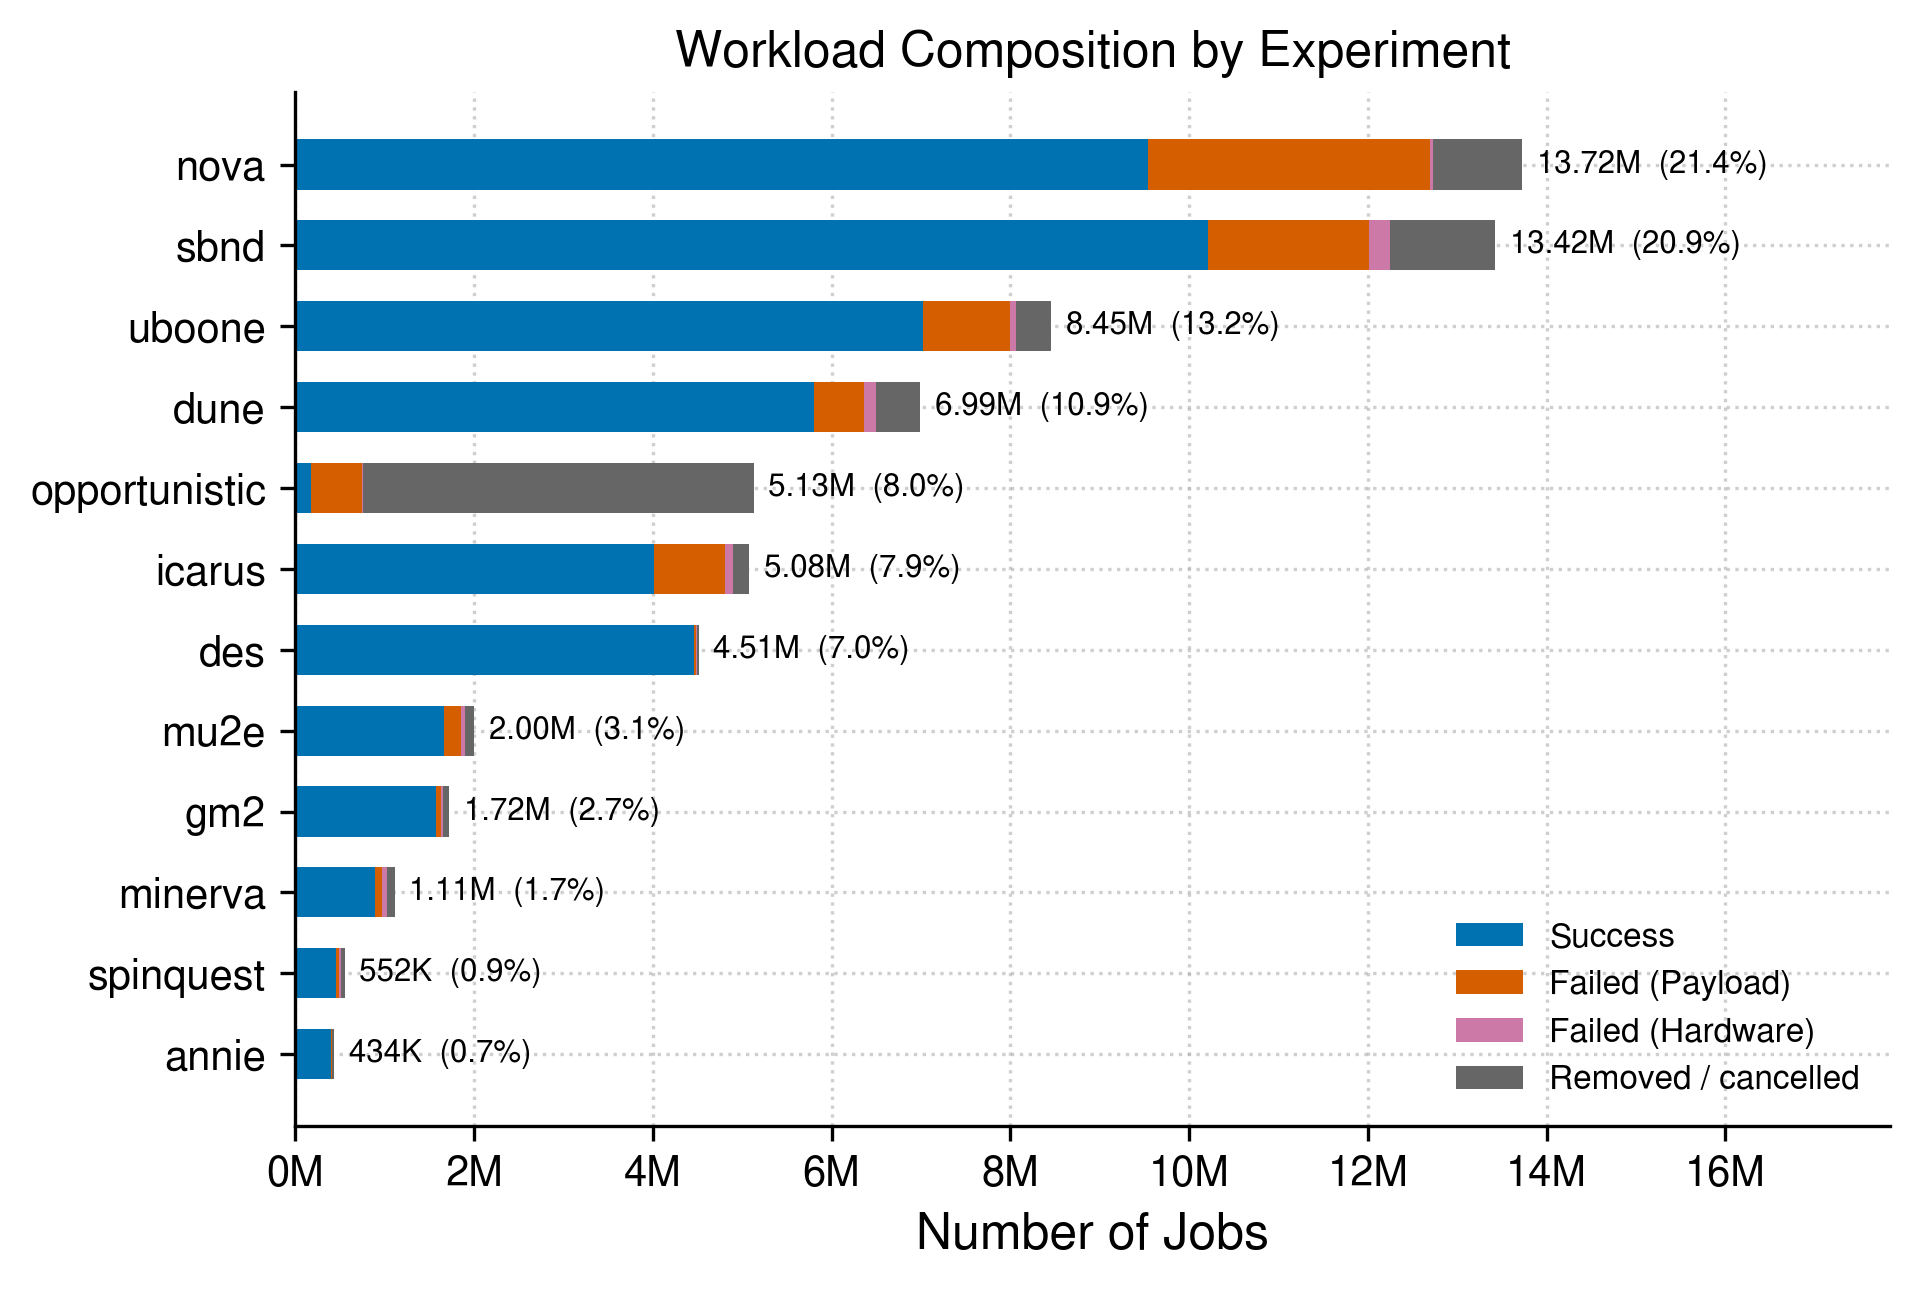

12 of 27 groups shown (>= 0.5% of 64,088,358 jobs)
  dropped 15: 944,017 jobs (1.47% of total)

  group               jobs    succ    payl      hw      rm
  nova          13,723,305   69.5%   23.0%    0.3%    7.2%
  sbnd          13,423,484   76.1%   13.4%    1.8%    8.7%
  uboone         8,454,875   83.1%   11.5%    0.8%    4.7%
  dune           6,993,325   83.1%    7.9%    2.0%    7.0%
  opportunisti   5,128,838    3.4%   11.2%    0.0%   85.3%
  icarus         5,078,639   79.0%   15.7%    1.8%    3.6%
  des            4,514,628   98.8%    0.5%    0.2%    0.4%
  mu2e           2,004,845   82.8%    9.7%    2.3%    5.3%
  gm2            1,722,565   91.6%    3.0%    1.5%    3.8%
  minerva        1,113,426   80.3%    6.8%    5.2%    7.7%
  spinquest        552,106   82.9%    5.3%    3.8%    8.1%
  annie            434,305   92.9%    2.7%    0.0%    4.4%


In [12]:
# Figure: workload composition by experiment, broken down by job outcome.
#
# Groups below MIN_SHARE of all jobs are dropped: with 27 groups the tail is a long
# list of near-zero bars that costs vertical space and says nothing. The printout
# reports what the cut removes so it is never silent.
#
# Outcome segments follow the fault taxonomy (fault_type):
#     -1 success | 0 payload/application | 1 hardware | 2 submission | -2 removed
# Submission faults are folded into payload to match E3's negative class, which
# contrasts hardware against everything else that failed. Flip SPLIT_SUBMISSION to
# show them separately.
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

MIN_SHARE = 0.005          # 0.5% of all jobs
SPLIT_SUBMISSION = False

_payload_codes = [0] if SPLIT_SUBMISSION else [0, 2]
group = (
    lf_anon.group_by("Group")
    .agg(
        n=pl.len(),
        success=(pl.col("fault_type") == -1).sum(),
        payload=pl.col("fault_type").is_in(_payload_codes).sum(),
        submission=(pl.col("fault_type") == 2).sum(),
        hardware=(pl.col("fault_type") == 1).sum(),
        removed=(pl.col("fault_type") == -2).sum(),
    )
    .sort("n", descending=True)
    .collect()
)
_grand = int(group["n"].sum())
_keep = group.filter(pl.col("n") / _grand >= MIN_SHARE)
_drop = group.filter(pl.col("n") / _grand < MIN_SHARE)

SEGMENTS = [("success", "Success", COLORS["primary"]),
            ("payload", "Failed (Payload)", COLORS["secondary"]),
            ("hardware", "Failed (Hardware)", COLORS["band"]),
            ("removed", "Removed / cancelled", COLORS["neutral"])]
if SPLIT_SUBMISSION:
    SEGMENTS.insert(2, ("submission", "Submission fault", COMPONENTS[2]))

# Strip the "group_" prefix for display; the underlying values keep it.
labels = [str(g).replace("group_", "") for g in _keep["Group"].to_list()]
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(6.5, 4.4), dpi=300)
left = np.zeros(len(labels))
for key, lab, colour in SEGMENTS:
    vals = np.asarray(_keep[key].to_list(), dtype=float)
    ax.barh(y, vals, left=left, color=colour, height=0.62, label=lab)
    left += vals

for yy, tot in zip(y, _keep["n"].to_list()):
    magnitude = f"{tot / 1e6:,.2f}M" if tot >= 1e6 else f"{tot / 1e3:,.0f}K"
    ax.text(tot + left.max() * 0.012, yy, f"{magnitude}  ({tot / _grand * 100:.1f}%)",
            va="center", ha="left", fontsize=7.5)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0, left.max() * 1.30)
ax.set_xlabel("Number of Jobs")
ax.set_title("Workload Composition by Experiment")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e6:.0f}M"))
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="x", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
print(save_fig(fig, "experiment_type_composition"))
plt.show()

print(f"{len(_keep)} of {len(group)} groups shown (>= {MIN_SHARE * 100:g}% of {_grand:,} jobs)")
if len(_drop):
    print(f"  dropped {len(_drop)}: {int(_drop['n'].sum()):,} jobs "
          f"({_drop['n'].sum() / _grand * 100:.2f}% of total)")
print()
print(f"  {'group':12s} {'jobs':>11s} {'succ':>7s} {'payl':>7s} {'hw':>7s} {'rm':>7s}")
for r in _keep.iter_rows(named=True):
    t = r["n"]
    print(f"  {str(r['Group']).replace('group_', '')[:12]:12s} {t:>11,} "
          f"{r['success'] / t * 100:>6.1f}% {r['payload'] / t * 100:>6.1f}% "
          f"{r['hardware'] / t * 100:>6.1f}% {r['removed'] / t * 100:>6.1f}%")

output/site_type_composition.pdf


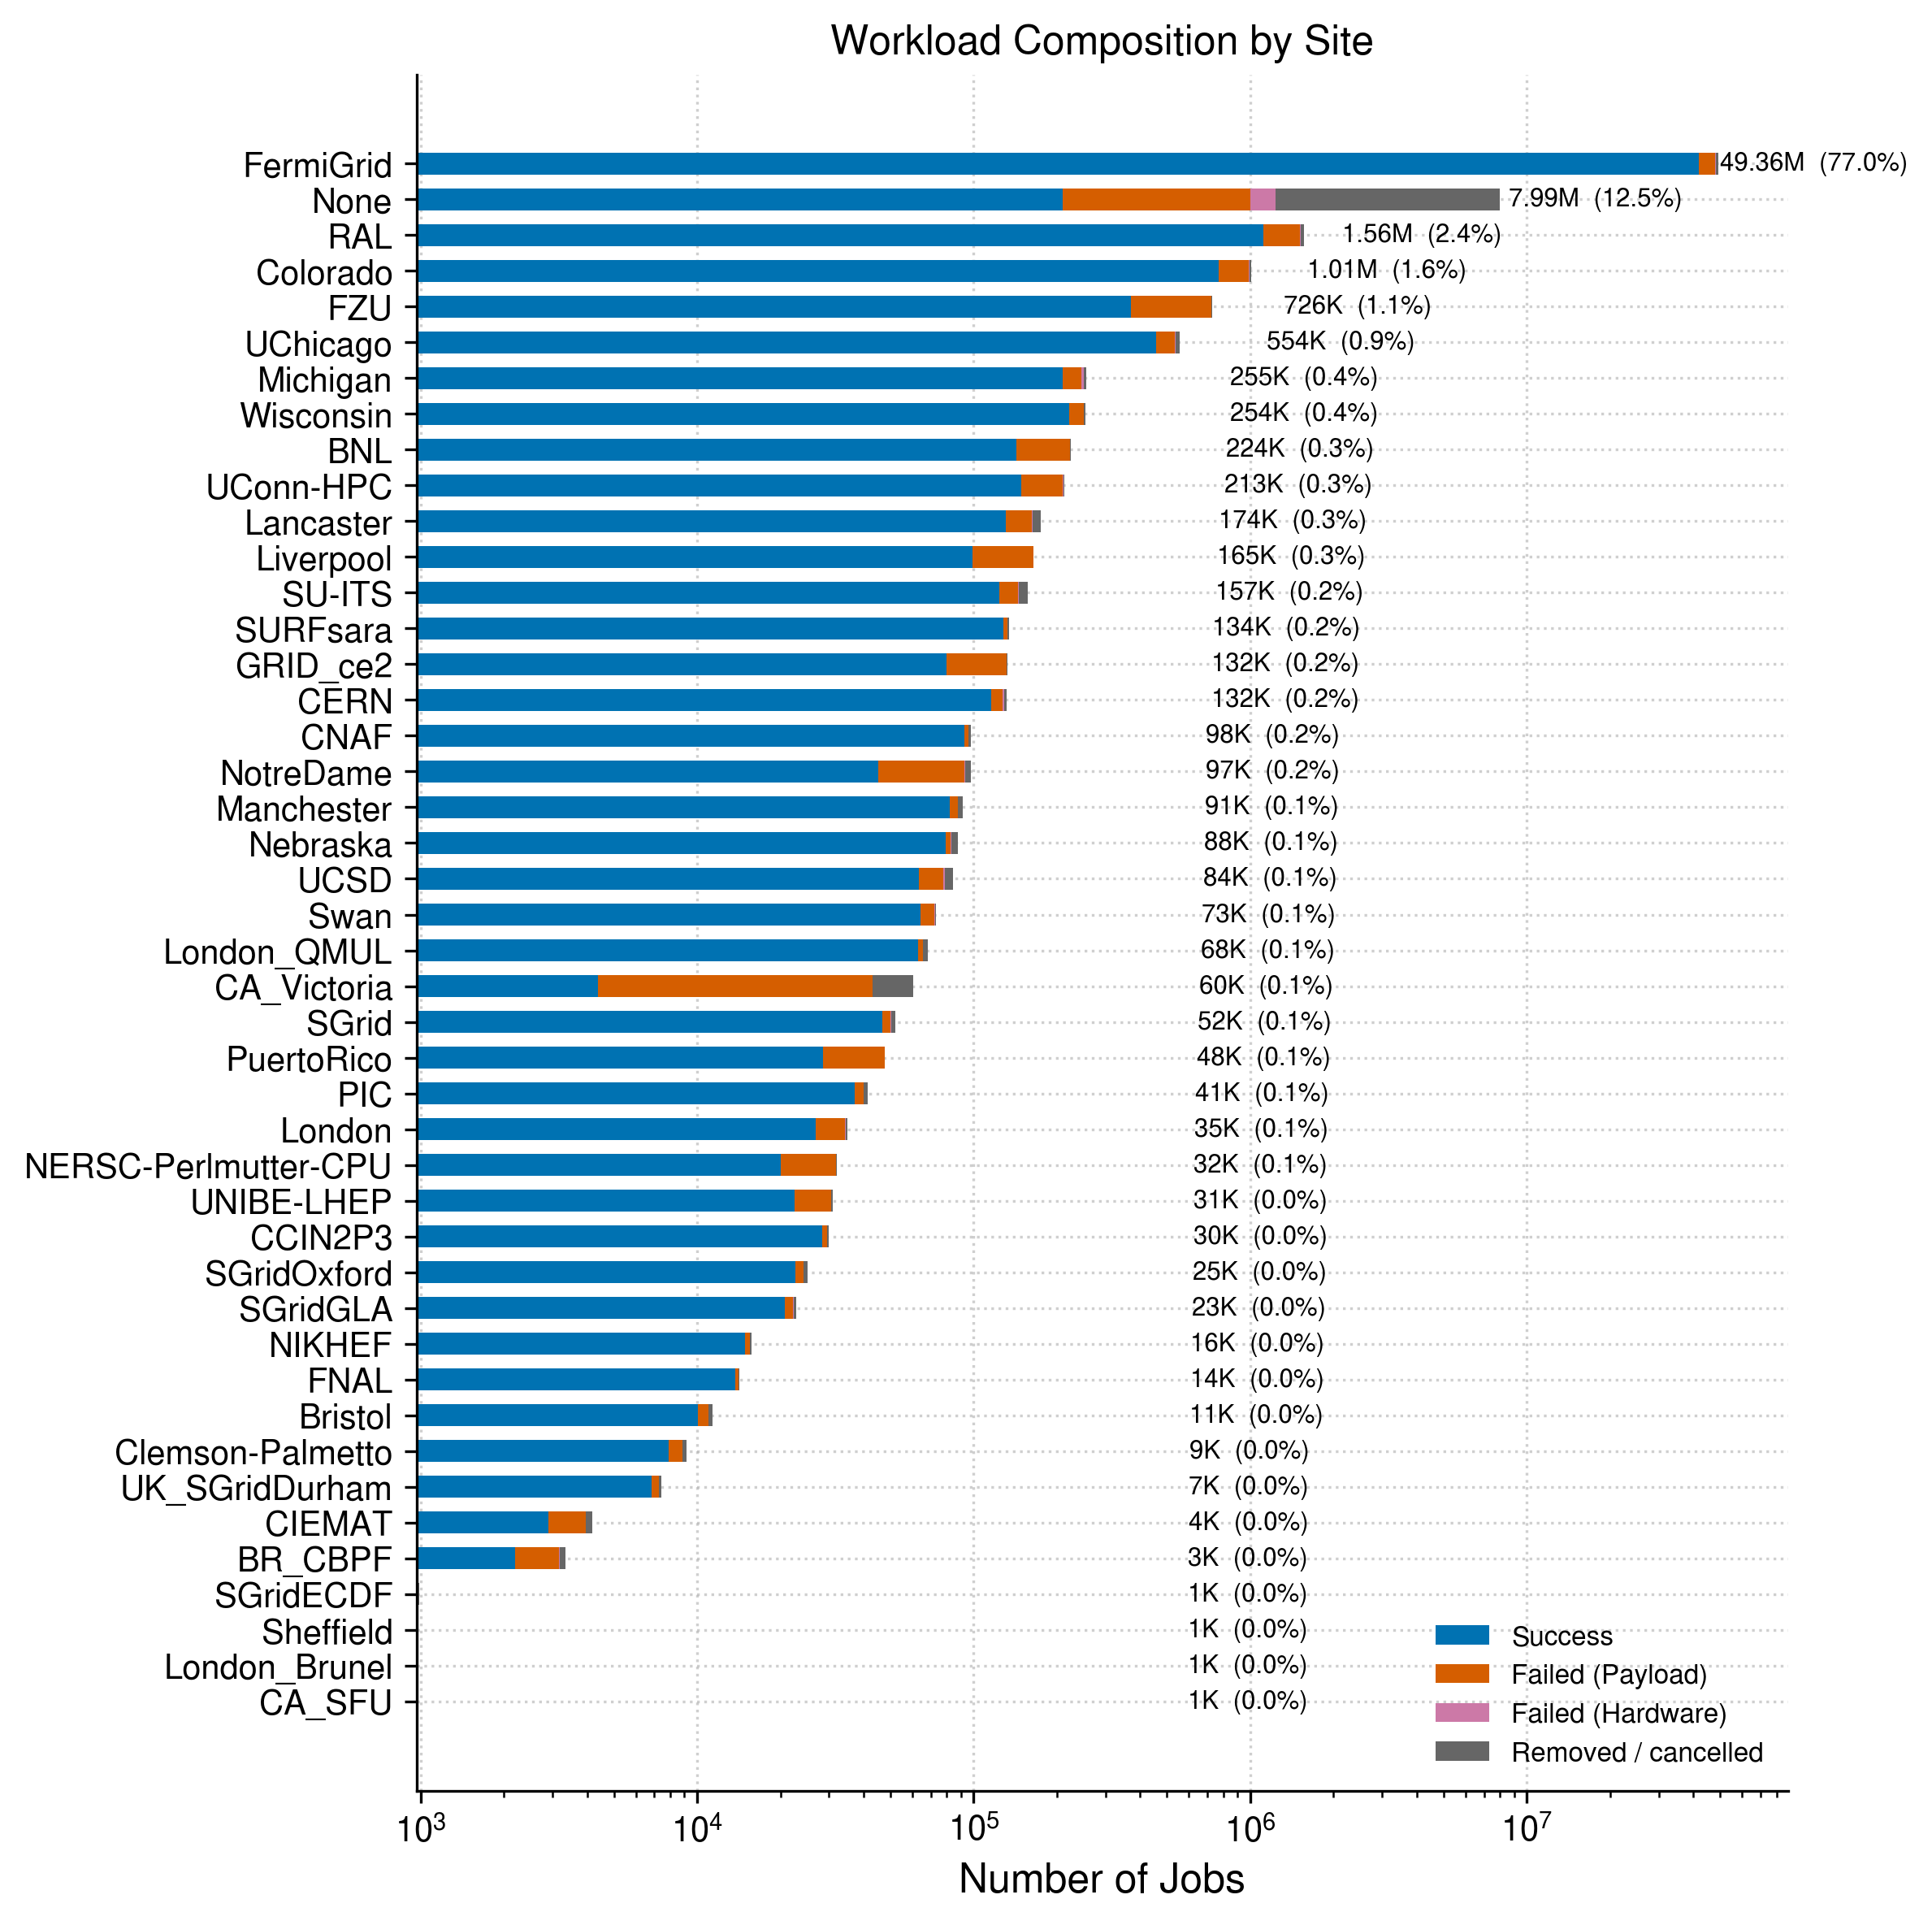

44 of 44 sites shown (>= 0.5% of 64,088,358 jobs)

  site                jobs    succ    payl      hw      rm
  FermiGrid     49,357,807   84.9%   11.9%    1.0%    2.2%
  None           7,990,712    2.6%    9.9%    2.9%   84.6%
  RAL            1,562,790   71.2%   25.3%    0.8%    2.6%
  Colorado       1,010,272   76.3%   21.1%    0.8%    1.8%
  FZU              726,341   51.0%   48.4%    0.0%    0.6%
  UChicago         554,279   82.4%   14.1%    0.7%    2.8%
  Michigan         255,469   81.8%   14.2%    1.8%    2.2%
  Wisconsin        253,760   87.2%   11.2%    0.4%    1.2%
  BNL              223,910   63.6%   36.2%    0.0%    0.2%
  UConn-HPC        213,270   69.6%   28.6%    0.7%    1.1%
  Lancaster        174,476   75.0%   18.0%    0.4%    6.6%
  Liverpool        164,777   60.0%   39.7%    0.0%    0.2%
  SU-ITS           157,244   78.6%   13.6%    0.5%    7.4%
  SURFsara         134,332   95.4%    3.3%    0.0%    1.2%
  GRID_ce2         132,064   60.5%   39.1%    0.0%    0.4%
  CER

In [13]:
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

MIN_SHARE = 0.005      
SPLIT_SUBMISSION = False

_payload_codes = [0] if SPLIT_SUBMISSION else [0, 2]
group = (
    lf_anon.group_by("MATCH_EXP_JOB_GLIDEIN_Site")
    .agg(
        n=pl.len(),
        success=(pl.col("fault_type") == -1).sum(),
        payload=pl.col("fault_type").is_in(_payload_codes).sum(),
        submission=(pl.col("fault_type") == 2).sum(),
        hardware=(pl.col("fault_type") == 1).sum(),
        removed=(pl.col("fault_type") == -2).sum(),
    )
    .sort("n", descending=True)
    .collect()
)
_grand = int(group["n"].sum())
_keep = group
_drop = []
#_keep = group.filter(pl.col("n") / _grand >= MIN_SHARE)
#_drop = group.filter(pl.col("n") / _grand < MIN_SHARE)

SEGMENTS = [("success", "Success", COLORS["primary"]),
            ("payload", "Failed (Payload)", COLORS["secondary"]),
            ("hardware", "Failed (Hardware)", COLORS["band"]),
            ("removed", "Removed / cancelled", COLORS["neutral"])]
if SPLIT_SUBMISSION:
    SEGMENTS.insert(2, ("submission", "Submission fault", COMPONENTS[2]))

# Strip the "group_" prefix for display; the underlying values keep it.
labels = [str(g).replace("site_", "") for g in _keep["MATCH_EXP_JOB_GLIDEIN_Site"].to_list()]
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
left = np.zeros(len(labels))
for key, lab, colour in SEGMENTS:
    vals = np.asarray(_keep[key].to_list(), dtype=float)
    ax.barh(y, vals, left=left, color=colour, height=0.62, label=lab)
    left += vals

for yy, tot in zip(y, _keep["n"].to_list()):
    magnitude = f"{tot / 1e6:,.2f}M" if tot >= 1e6 else f"{tot / 1e3:,.0f}K"
    ax.text(tot + left.max() * 0.012, yy, f"{magnitude}  ({tot / _grand * 100:.1f}%)",
            va="center", ha="left", fontsize=7.5)

ax.set_yticks(y)
ax.set_yticklabels(labels)
#ax.set_xlim(0, left.max() * 1.30)
ax.set_xscale("log")
ax.set_xlabel("Number of Jobs")
ax.set_title("Workload Composition by Site")
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e6:.0f}M"))
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="x", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
print(save_fig(fig, "site_type_composition"))
plt.show()

print(f"{len(_keep)} of {len(group)} sites shown (>= {MIN_SHARE * 100:g}% of {_grand:,} jobs)")
if len(_drop):
    print(f"  dropped {len(_drop)}: {int(_drop['n'].sum()):,} jobs "
          f"({_drop['n'].sum() / _grand * 100:.2f}% of total)")
print()
print(f"  {'site':12s} {'jobs':>11s} {'succ':>7s} {'payl':>7s} {'hw':>7s} {'rm':>7s}")
for r in _keep.iter_rows(named=True):
    t = r["n"]
    print(f"  {str(r['MATCH_EXP_JOB_GLIDEIN_Site']).replace('site_', '')[:12]:12s} {t:>11,} "
          f"{r['success'] / t * 100:>6.1f}% {r['payload'] / t * 100:>6.1f}% "
          f"{r['hardware'] / t * 100:>6.1f}% {r['removed'] / t * 100:>6.1f}%")

FermiGrid: 0 s of idle time removed across 0 intervals (0.000%)
output/interfailure_fit_FermiGrid.pdf


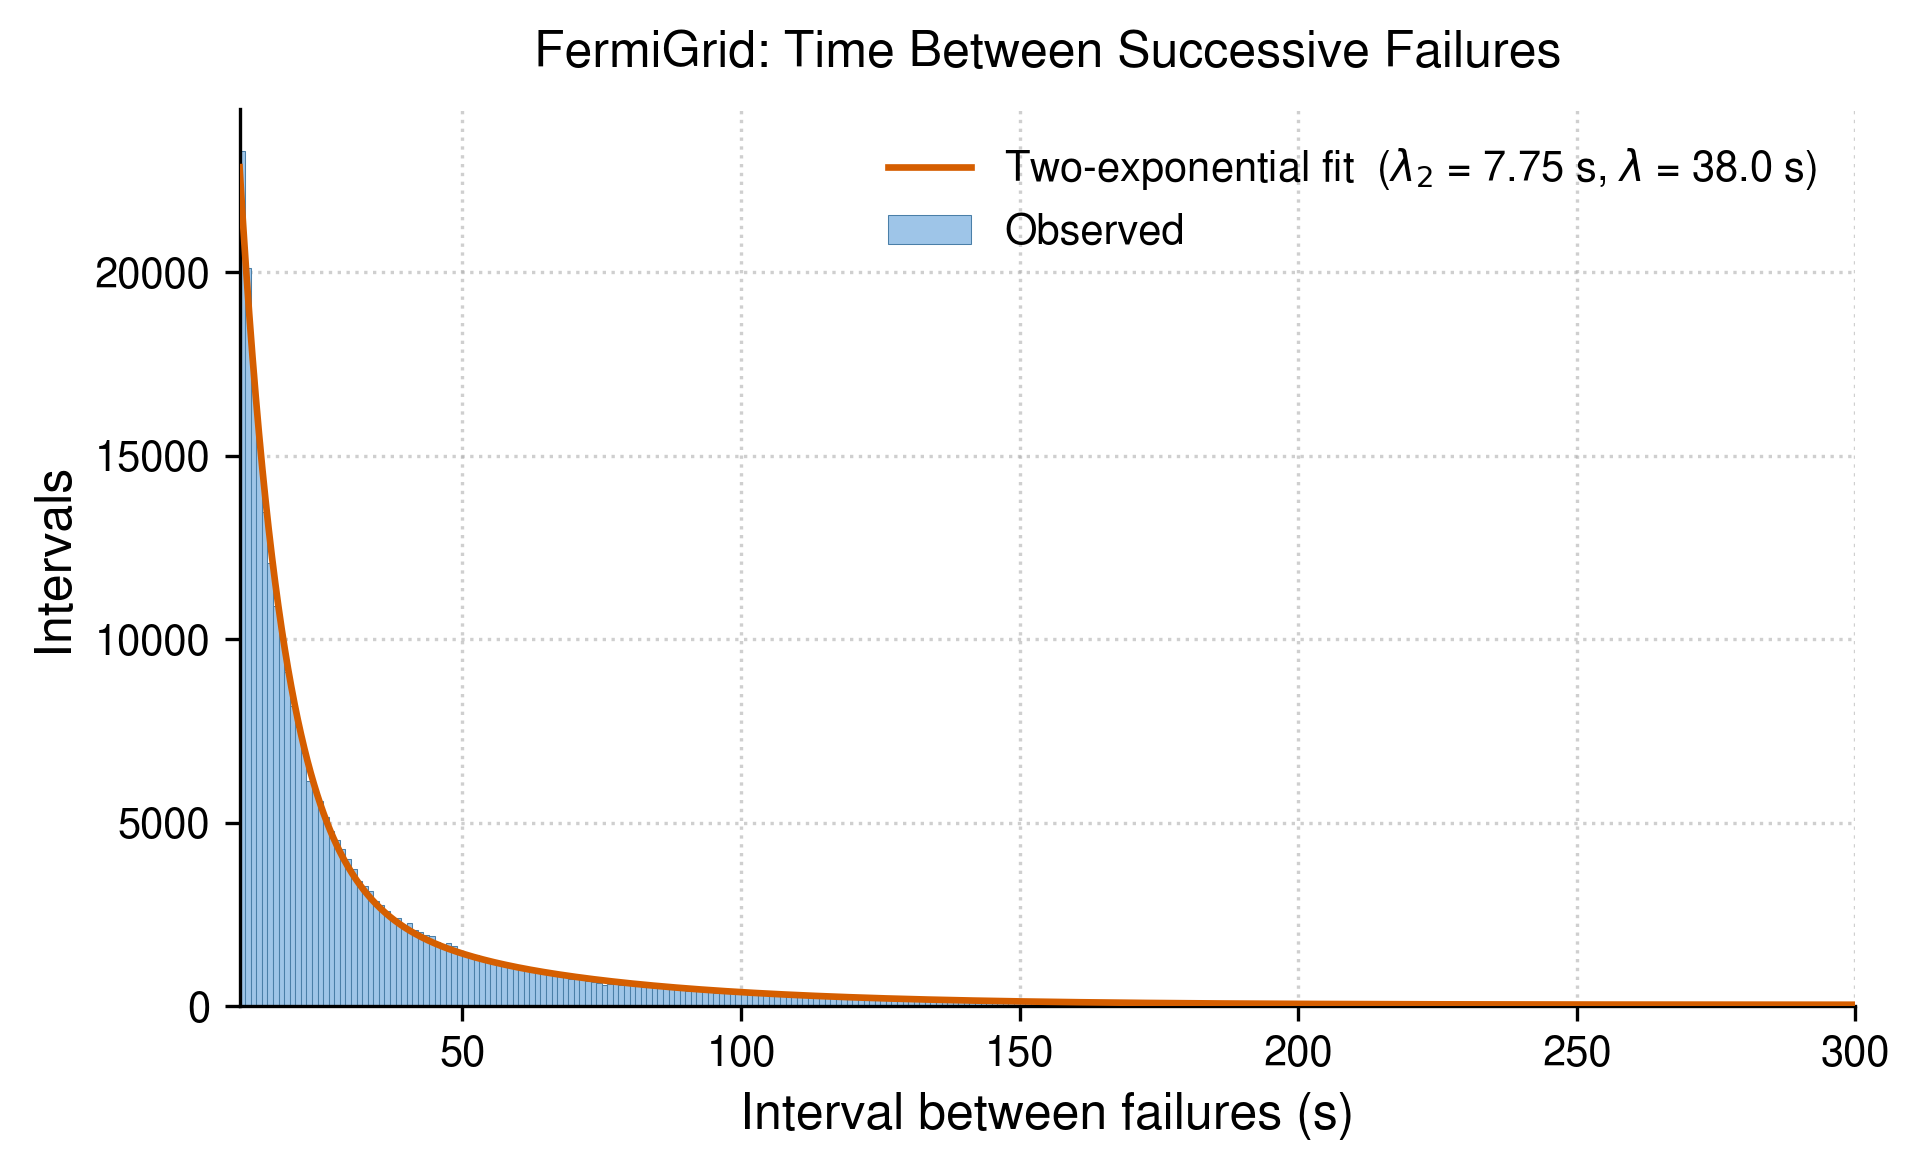

FermiGrid: 6,074,133 intervals | 3,515,718 zero-length dropped (57.9%) | 300,153 in [10, 300] s
fit: c + b*exp(-t/lambda2) + a*exp(-t/lambda)   [scipy curve_fit, TRF, Poisson weights, errors scaled by sqrt(chi2/ndof)]
  a            4,799.3403  +/-    146.6552   t =  32.73   p = 1.569e-98
  b           69,535.6031  +/-  1,614.3664   t =  43.07   p = 8.476e-127
  lambda2          7.7514  +/-      0.1109   t =  69.90   p = 2.045e-181
  lambda          37.9573  +/-      0.5560   t =  68.27   p = 1.165e-178
  c               37.5337  +/-      1.4434   t =  26.00   p = 3.285e-77
  chi2 = 1,106.1   ndof = 285   chi2/ndof = 3.88
  time constants: fast 7.751 s, slow 37.96 s   (rates 0.129009 and 0.0263454 s^-1)
  cross-check on raw elapsed: a=4,799.4141, b=69,536.2710, lambda2=7.7514, lambda=37.9570, c=37.5341
  max |relative change| across parameters: 0.002%


In [17]:
# Figure: single-site inter-failure intervals with a two-component exponential fit.
#
# Recreates the reference FermiGrid plot. Deliberately differs from the pooled
# figure above in three ways, all of which matter for reproducing it:
#   * one site only -- pooling sites of very different size mixes arrival rates;
#   * ACTIVE time between failures -- elapsed time minus any stretch where the site
#     had zero jobs running. The reference plot used raw elapsed time; set
#     USE_ACTIVE_TIME = False to reproduce it exactly. Both are fitted and printed
#     so the effect of the correction is visible rather than assumed;
#   * zero-length intervals dropped, then fitted over FIT_LO..FIT_HI with unit bins.
#
# Zero-length intervals are more than half the data at FermiGrid: with ~6M failures
# over seven months, many land in the same one-second timestamp. They carry no rate
# information and are excluded rather than piled into the first bin.
#
# FIT: scipy.optimize.curve_fit -- Trust Region Reflective least squares, Poisson
# weights (sigma = sqrt(N) per bin). Parameter errors use absolute_sigma=False, i.e.
# the covariance is scaled by chi2/ndof, matching Mathematica's NonlinearModelFit
# default so the quoted errors are directly comparable to the reference plot. Set
# absolute_sigma=True for unscaled (purely Poisson) errors, which come out a factor
# sqrt(chi2/ndof) ~ 2 smaller.
from scipy.optimize import curve_fit
from scipy import stats as _stats

from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

FIT_SITE = "FermiGrid"
FIT_LO, FIT_HI, FIT_BW = 10, 300, 1.0

USE_ACTIVE_TIME = True

# Event frame and active-time helper, inlined so this cell is self-contained (they
# previously lived in the pooled inter-failure cell).
# The regenerated extract stores lifecycle timestamps as epoch-millisecond Int64
# under `_ms` names; only CompletionDate survives as a Datetime. Comparisons are done
# in epoch seconds, and WINDOW_START is pinned to UTC -- a naive .timestamp() would
# silently apply the machine's local offset.
_W0_S = int(WINDOW_START.replace(tzinfo=dt.timezone.utc).timestamp())
_ev = (
    lf_anon.filter(
        pl.col(SITECOL).is_not_null(),
        pl.col("JobStartDate_ms") > 0, pl.col("JobStartDate_ms") // 1000 >= _W0_S,
        pl.col("CompletionDate_ms") > 0, pl.col("CompletionDate_ms") // 1000 >= _W0_S,
    )
    .select([SITECOL,
             (pl.col("JobStartDate_ms") // 1000).alias("s"),
             (pl.col("CompletionDate_ms") // 1000).alias("c"),
             "Failed"])
    .collect()
)

def _active_gaps(site_df):
    """Inter-failure gaps at one site, with that site's idle seconds removed.

    Activity is a concurrency sweep: +1 per job start, -1 per completion; the site is
    idle wherever the running count is 0, and those seconds do not count as exposure.
    """
    s = site_df["s"].to_numpy().astype(np.int64)
    c = np.maximum(site_df["c"].to_numpy().astype(np.int64), s)
    F = np.sort(site_df.filter(pl.col("Failed") == 1)["c"].to_numpy().astype(np.int64))
    if len(F) < 2:
        return np.empty(0)
    ev = np.concatenate([s, c])
    delta = np.concatenate([np.ones(len(s), np.int32), -np.ones(len(c), np.int32)])
    order = np.argsort(ev, kind="mergesort")
    ev, delta = ev[order], delta[order]
    running = np.cumsum(delta)
    zi = np.where(running[:-1] == 0)[0]
    i_start, i_end = ev[zi], ev[zi + 1]
    keep = i_end > i_start
    i_start, i_end = i_start[keep], i_end[keep]
    dur = (i_end - i_start).astype(np.float64)
    cum = np.concatenate([[0.0], np.cumsum(dur)])

    def idle_before(t):
        t = np.asarray(t, dtype=np.float64)
        if len(i_start) == 0:
            return np.zeros_like(t)
        j = np.searchsorted(i_start, t, "right") - 1
        jc = np.clip(j, 0, len(i_start) - 1)
        base = np.where(j < 0, 0.0, cum[jc])
        partial = np.where(j < 0, 0.0, np.clip(t - i_start[jc], 0, dur[jc]))
        return base + partial

    raw = np.diff(F).astype(np.float64)
    return np.clip(raw - (idle_before(F[1:]) - idle_before(F[:-1])), 0, None)

# Raw elapsed gaps between successive failures at this site.
_site_frame = _ev.filter(pl.col(SITECOL) == FIT_SITE)
_fail_t = np.sort(
    _site_frame.filter(pl.col("Failed") == 1)["c"].to_numpy().astype(np.int64)
)
_raw_gaps = np.diff(_fail_t).astype(np.float64)

# Active-time version: subtract any idle stretch (zero concurrency) inside each gap.
# `_active_gaps` is defined in the pooled inter-failure cell above.
_act_gaps = _active_gaps(_site_frame)

n_total = len(_raw_gaps)
n_zero = int((_raw_gaps == 0).sum())
raw_gaps = _raw_gaps[_raw_gaps > 0]
act_gaps = _act_gaps[_raw_gaps > 0]          # same intervals, active-time measure
site_gaps = act_gaps if USE_ACTIVE_TIME else raw_gaps
site_gaps = site_gaps[site_gaps > 0]

_idle_frac = float(np.mean(act_gaps < raw_gaps - 1)) if len(raw_gaps) else 0.0
print(f"{FIT_SITE}: {(raw_gaps - act_gaps).sum():,.0f} s of idle time removed across "
      f"{int((act_gaps < raw_gaps - 1).sum()):,} intervals ({_idle_frac * 100:.3f}%)")

fit_edges = np.arange(FIT_LO, FIT_HI + FIT_BW, FIT_BW)
fit_counts, _ = np.histogram(site_gaps, bins=fit_edges)
fit_centres = (fit_edges[:-1] + fit_edges[1:]) / 2

# c + b*exp(-t/lambda2) + a*exp(-t/lambda). lambda and lambda2 are TIME CONSTANTS in
# seconds, not rates -- the reference plot's parametrisation.
def two_exp(t, a, b, lam2, lam, c):
    return c + b * np.exp(-t / lam2) + a * np.exp(-t / lam)

popt, pcov = curve_fit(
    two_exp, fit_centres, fit_counts,
    p0=[5e3, 7e4, 8.0, 38.0, 40.0],
    sigma=np.sqrt(np.maximum(fit_counts, 1)),
    absolute_sigma=False,
    maxfev=400_000,
)
perr = np.sqrt(np.diag(pcov))
fitted = two_exp(fit_centres, *popt)
chi2 = np.sum((fit_counts - fitted) ** 2 / np.maximum(fit_counts, 1))
ndof = len(fit_counts) - len(popt)

fig, ax = plt.subplots(figsize=(6.5, 4.0), dpi=300)
ax.bar(fit_centres, fit_counts, width=FIT_BW, color=COLORS["hist"],
       edgecolor=BASE_COLOR, linewidth=0.25, zorder=2, label="Observed")
_xs = np.linspace(FIT_LO, FIT_HI, 2000)
ax.plot(_xs, two_exp(_xs, *popt), color=COLORS["fit"], linewidth=1.6, zorder=3,
        label=(rf"Two-exponential fit  ($\lambda_2$ = {popt[2]:.2f} s, "
               rf"$\lambda$ = {popt[3]:.1f} s)"))

# Start the axis where the data starts. Sub-FIT_LO intervals are excluded (that is
# the whole point of the fit window), so extending the axis down to 0 would leave a
# blank strip that reads as "no failures here" rather than "not plotted".
ax.set_xlim(FIT_LO, FIT_HI)
ax.set_ylim(0, fit_counts.max() * 1.05)
ax.set_xlabel("Interval between failures (s)")
ax.set_ylabel("Intervals")
ax.set_title(f"{FIT_SITE}: Time Between Successive Failures", pad=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# P-value: two-sided t-test of H0 that the parameter is zero, on ndof degrees of
# freedom -- the same quantity Mathematica's NonlinearModelFit reports. Read it as
# "this term is resolved", not as evidence the model is right: for an amplitude or a
# decay constant the zero null is never plausible, which is why every p here is
# astronomically small. chi2/ndof is the statistic that judges the fit.
_rows = [(n, v, e, v / e, 2 * _stats.t.sf(abs(v / e), ndof))
         for n, v, e in zip(["a", "b", "lambda2", "lambda", "c"], popt, perr)]
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
print(save_fig(fig, f"interfailure_fit_{FIT_SITE}"))
plt.show()

print(f"{FIT_SITE}: {n_total:,} intervals | {n_zero:,} zero-length dropped "
      f"({n_zero / n_total * 100:.1f}%) | {fit_counts.sum():,} in [{FIT_LO}, {FIT_HI}] s")
print(f"fit: c + b*exp(-t/lambda2) + a*exp(-t/lambda)   "
      f"[scipy curve_fit, TRF, Poisson weights, errors scaled by sqrt(chi2/ndof)]")
for n, v, e, t, p in _rows:
    print(f"  {n:8s} {v:>14,.4f}  +/- {e:>11,.4f}   t = {t:6.2f}   p = {p:.3e}")
print(f"  chi2 = {chi2:,.1f}   ndof = {ndof}   chi2/ndof = {chi2 / ndof:.2f}")
print(f"  time constants: fast {popt[2]:.3f} s, slow {popt[3]:.2f} s   "
      f"(rates {1 / popt[2]:.6f} and {1 / popt[3]:.7f} s^-1)")

# Refit on the other time measure so the correction's effect is quantified, not
# asserted. On a site that is essentially never empty these agree to many digits.
_other = raw_gaps if USE_ACTIVE_TIME else act_gaps
_oc, _ = np.histogram(_other[_other > 0], bins=fit_edges)
try:
    _op, _ = curve_fit(two_exp, fit_centres, _oc, p0=list(popt),
                       sigma=np.sqrt(np.maximum(_oc, 1)), absolute_sigma=False,
                       maxfev=400_000)
    _label = "raw elapsed" if USE_ACTIVE_TIME else "active time"
    print(f"  cross-check on {_label}: "
          + ", ".join(f"{n}={v:,.4f}" for n, v in
                      zip(["a", "b", "lambda2", "lambda", "c"], _op)))
    print("  max |relative change| across parameters: "
          f"{np.max(np.abs((popt - _op) / _op)) * 100:.3f}%")
except Exception as _e:
    print(f"  cross-check fit failed: {_e}")

  active-time correction: 57.6% of total gap time is idle; 41.0% of intervals contain some
FermiGrid: 6,074,134 failures over 33,117 nodes | 6,042,387 within-node intervals | 7,121 zero-length dropped
  node gap percentiles (s): p10=46  p25=81  p50=352  p75=18,330  p90=105,524
output/interfailure_fit_node_FermiGrid_2.pdf


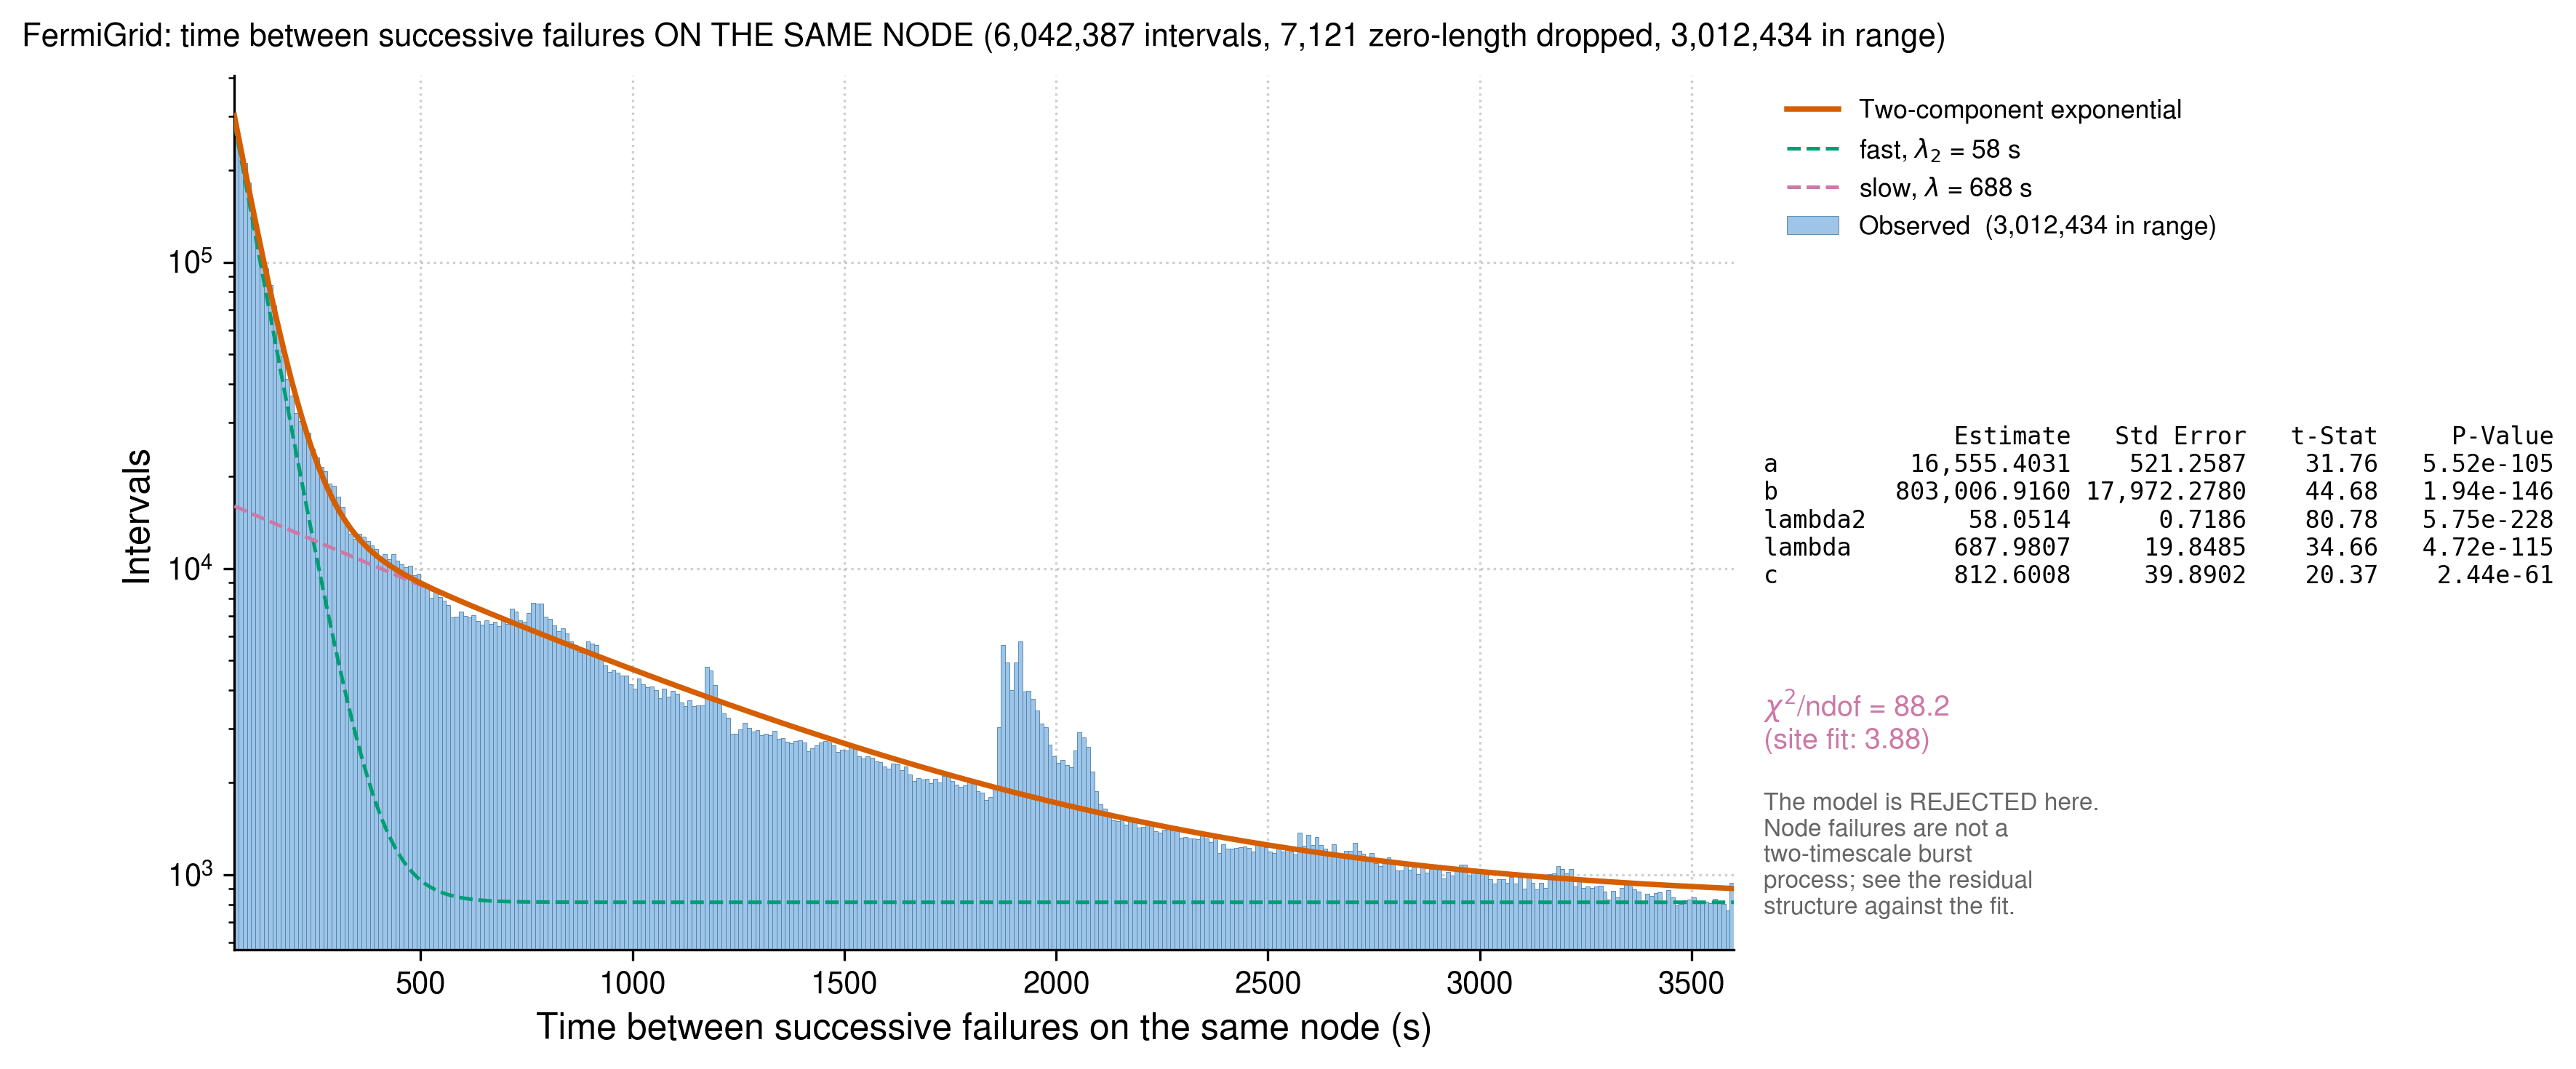


fit over [60, 3600] s, 10 s bins   [scipy curve_fit, TRF, Poisson weights, errors scaled by sqrt(chi2/ndof)]
  a           16,555.4031  +/-    521.2587   t =  31.76   p = 5.517e-105
  b          803,006.9160  +/- 17,972.2780   t =  44.68   p = 1.938e-146
  lambda2         58.0514  +/-      0.7186   t =  80.78   p = 5.751e-228
  lambda         687.9807  +/-     19.8485   t =  34.66   p = 4.725e-115
  c              812.6008  +/-     39.8902   t =  20.37   p = 2.440e-61
  chi2 = 30,770.9   ndof = 349   chi2/ndof = 88.17   <-- site fit achieves 3.88 on the same functional form
  time constants: fast 58.1 s, slow 688.0 s
  cross-check on raw elapsed: chi2/ndof 80.21, lambda2=60.6s lambda=703.0s
  -> the correction does not rescue the fit; it fails on the SHAPE of the distribution,
     not on the choice of time measure.

Why this matters for the trailing features:
    a     60s window contains a prior failure on the same node  16.6% of active time ( 15.0% raw)
    a    300s window contain

In [16]:
# Figure: NODE inter-failure intervals at FermiGrid, same treatment as the site fit
# above -- and the point of it is that the same model does NOT describe them.
#
# The site fit justified the trailing WINDOW for site-keyed health features. That
# result cannot be carried over to node-keyed features: a node sees a different
# arrival process. Fitting each key separately is what shows this.
#
# Node here is `LastRemoteHost`, i.e. the slot the payload ran in. Intervals are
# WITHIN a node (time from one failure on that node to the next on the same node),
# then pooled across nodes.
#
# ACTIVE TIME. Unlike FermiGrid as a whole -- which is never empty, so the site fit
# removed 0 s of idle -- a single slot runs one job at a time and is idle between
# them, so raw elapsed time badly overstates exposure: 57.6% of total within-node gap
# time is idle, and 41% of intervals contain some. A slot is serial, so its active
# time needs no concurrency sweep -- it is just the total runtime of jobs on that slot
# in the interval. Both measures are fitted below and both are reported, because the
# correction turns out NOT to change the conclusion (chi2/ndof 80 raw vs 88 active,
# time constants within 4%): the fit fails on the shape of the distribution, not on
# the choice of time measure.
#
# FIT RANGE. The site range [10, 300] s is wrong for nodes -- their median gap is
# 415 s, so that window covers only the extreme left tail and the fit degenerates
# (chi2/ndof 1449, negative amplitudes). A scan over candidate ranges puts the best
# two-exponential at [60, 3600] s; it is used here, and it still fails.
from scipy.optimize import curve_fit
from scipy import stats as _stats

from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

NODE_SITE = "FermiGrid"
NODE_LO, NODE_HI, NODE_BW = 60, 3600, 10.0
NODEKEY = "LastRemoteHost"

# Every job that RAN on a FermiGrid node -- the exposure, not only the failures.
_nj = (lf_anon.filter(pl.col(SITECOL) == NODE_SITE, pl.col(NODEKEY).is_not_null(),
                      pl.col("JobStartDate_ms") > 0, pl.col("CompletionDate_ms") > 0)
       .select([pl.col(NODEKEY).alias("k"),
                (pl.col("JobStartDate_ms") // 1000).alias("s"),
                (pl.col("CompletionDate_ms") // 1000).alias("c"), "Failed",
                pl.col("NumJobStarts").fill_null(1).alias("nstarts"),
                pl.col("DerivedCampaignType").fill_null("Unknown").alias("jtype")])
       .collect())

_k_all = _nj["k"].to_numpy().astype(np.int64)
_s_all = _nj["s"].to_numpy().astype(np.int64)
_c_all = np.maximum(_nj["c"].to_numpy().astype(np.int64), _s_all)
_fl = _nj["Failed"].to_numpy().astype(bool)
_ns_all = _nj["nstarts"].to_numpy().astype(np.int32)
_jt_all = _nj["jtype"].to_numpy()
n_nodes = int(len(np.unique(_k_all)))

# Per-node cumulative busy time, via a node-encoded global sort. busy(node, t) is the
# total runtime of that node's jobs completed by t; a slot is serial, so the residual
# in-flight term is bounded by one job's runtime.
_t0 = int(min(_s_all.min(), _c_all.min()))
_span = int(max(_s_all.max(), _c_all.max())) - _t0 + 3
_dur = (_c_all - _s_all).astype(np.float64)
_enc = _k_all * _span + (_c_all - _t0)
_o = np.argsort(_enc, kind="mergesort")
_enc_sorted = _enc[_o]
_cum = np.concatenate([[0.0], np.cumsum(_dur[_o])])

def _busy(kk, tt):
    q = kk * _span + np.clip(tt - _t0, 0, _span - 1)
    return _cum[np.searchsorted(_enc_sorted, q, "right")] \
         - _cum[np.searchsorted(_enc_sorted, kk * _span, "left")]

_fi = np.where(_fl)[0]
_kf, _tf, _nsf, _jtf = _k_all[_fi], _c_all[_fi], _ns_all[_fi], _jt_all[_fi]
_of = np.lexsort((_tf, _kf))
_kf, _tf, _nsf, _jtf = _kf[_of], _tf[_of], _nsf[_of], _jtf[_of]
_same = _kf[1:] == _kf[:-1]
_k1 = _kf[1:][_same]
_tp, _tn = _tf[:-1][_same], _tf[1:][_same]
# Restart count of the job that ENDED each interval -- used by the next cell to test
# whether the ~2,000 s spike is restart-driven.
_ns_next = _nsf[1:][_same]
_jt_next = _jtf[1:][_same]

node_raw_all = (_tn - _tp).astype(np.float64)
n_total_n = int(len(node_raw_all))
n_zero_n = int((node_raw_all == 0).sum())
_pos = node_raw_all > 0
node_raw = node_raw_all[_pos]
node_act = np.clip(_busy(_k1, _tn) - _busy(_k1, _tp), 0, node_raw_all)[_pos]
node_starts = _ns_next[_pos]
node_jobtype = _jt_next[_pos]
node_key = _k1[_pos]

_idle = node_raw - node_act
print(f"  active-time correction: {_idle.sum() / node_raw.sum() * 100:.1f}% of total "
      f"gap time is idle; {(_idle > 1).mean() * 100:.1f}% of intervals contain some")

USE_NODE_ACTIVE = True
node_gaps = node_act if USE_NODE_ACTIVE else node_raw

_q = np.percentile(node_gaps, [10, 25, 50, 75, 90])
print(f"{NODE_SITE}: {int(_fl.sum()):,} failures over {n_nodes:,} nodes | "
      f"{n_total_n:,} within-node intervals | {n_zero_n:,} zero-length dropped")
print("  node gap percentiles (s): " +
      "  ".join(f"p{p}={v:,.0f}" for p, v in zip([10, 25, 50, 75, 90], _q)))

n_edges = np.arange(NODE_LO, NODE_HI + NODE_BW, NODE_BW)
n_counts, _ = np.histogram(node_gaps, bins=n_edges)
n_centres = (n_edges[:-1] + n_edges[1:]) / 2
_m = n_counts > 0

def two_exp(t, a, b, lam2, lam, c):
    return c + b * np.exp(-t / lam2) + a * np.exp(-t / lam)

npopt, npcov = curve_fit(
    two_exp, n_centres[_m], n_counts[_m],
    p0=[1e3, 1e4, 60.0, 600.0, 10.0], sigma=np.sqrt(n_counts[_m]),
    absolute_sigma=False, maxfev=400_000)
nperr = np.sqrt(np.diag(npcov))
if npopt[2] > npopt[3]:                       # keep lambda2 as the fast constant
    npopt = npopt[[1, 0, 3, 2, 4]]
    nperr = nperr[[1, 0, 3, 2, 4]]
_res = (n_counts[_m] - two_exp(n_centres[_m], *npopt)) / np.sqrt(n_counts[_m])
nchi2 = float((_res ** 2).sum())
nndof = int(_m.sum() - 5)

fig, ax = plt.subplots(figsize=(11.5, 5), dpi=300)
ax.bar(n_centres, n_counts, width=NODE_BW, color=COLORS["hist"], edgecolor=BASE_COLOR,
       linewidth=0.2, zorder=2, label=f"Observed  ({n_counts.sum():,} in range)")
_xs = np.linspace(NODE_LO, NODE_HI, 2000)
ax.plot(_xs, two_exp(_xs, *npopt), color=COLORS["fit"], linewidth=1.8, zorder=4,
        label="Two-component exponential")
ax.plot(_xs, npopt[4] + npopt[1] * np.exp(-_xs / npopt[2]), "--", color=COMPONENTS[0],
        linewidth=1.2, zorder=3, label=f"fast, $\\lambda_2$ = {npopt[2]:,.0f} s")
ax.plot(_xs, npopt[4] + npopt[0] * np.exp(-_xs / npopt[3]), "--", color=COMPONENTS[1],
        linewidth=1.2, zorder=3, label=f"slow, $\\lambda$ = {npopt[3]:,.0f} s")

ax.set_yscale("log")
ax.set_xlim(NODE_LO, NODE_HI)
ax.set_xlabel("Time between successive failures on the same node (s)")
ax.set_ylabel("Intervals")
ax.set_title(f"{NODE_SITE}: time between successive failures ON THE SAME NODE "
             f"({n_total_n:,} intervals, {n_zero_n:,} zero-length dropped, "
             f"{n_counts.sum():,} in range)", fontsize=10.5, pad=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.02, 1.0))

_nrows = [(n, v, e, v / e, 2 * _stats.t.sf(abs(v / e), nndof))
          for n, v, e in zip(["a", "b", "lambda2", "lambda", "c"], npopt, nperr)]
_ntbl = f"{'':9s}{'Estimate':>12s}{'Std Error':>12s}{'t-Stat':>9s}{'P-Value':>12s}\n"
_ntbl += "\n".join(f"{n:9s}{v:>12,.4f}{e:>12,.4f}{t:>9.2f}{p:>12.2e}"
                   for n, v, e, t, p in _nrows)
ax.text(1.02, 0.60, _ntbl, transform=ax.transAxes, fontsize=8, va="top",
        family="monospace")
ax.text(1.02, 0.30, rf"$\chi^2$/ndof = {nchi2 / nndof:,.1f}"
                    "\n" rf"(site fit: 3.88)",
        transform=ax.transAxes, fontsize=9.5, va="top", color=COLORS["band"])
ax.text(1.02, 0.18,
        "The model is REJECTED here.\nNode failures are not a\ntwo-timescale burst\n"
        "process; see the residual\nstructure against the fit.",
        transform=ax.transAxes, fontsize=8, va="top", color=COLORS["neutral"])

plt.tight_layout()
print(save_fig(fig, f"interfailure_fit_node_{NODE_SITE}_2"))
plt.show()

print(f"\nfit over [{NODE_LO}, {NODE_HI}] s, {NODE_BW:.0f} s bins   "
      f"[scipy curve_fit, TRF, Poisson weights, errors scaled by sqrt(chi2/ndof)]")
for n, v, e, t, p in _nrows:
    print(f"  {n:8s} {v:>14,.4f}  +/- {e:>11,.4f}   t = {t:6.2f}   p = {p:.3e}")
print(f"  chi2 = {nchi2:,.1f}   ndof = {nndof}   chi2/ndof = {nchi2 / nndof:,.2f}"
      f"   <-- site fit achieves 3.88 on the same functional form")
print(f"  time constants: fast {npopt[2]:,.1f} s, slow {npopt[3]:,.1f} s")
# Cross-check on the other time measure, so the correction's effect is quantified
# rather than asserted -- the same check the site fit does.
_other = node_raw if USE_NODE_ACTIVE else node_act
_oc, _ = np.histogram(_other, bins=n_edges)
_om = _oc > 0
try:
    _op, _ = curve_fit(two_exp, n_centres[_om], _oc[_om], p0=list(npopt),
                       sigma=np.sqrt(_oc[_om]), absolute_sigma=False, maxfev=400_000)
    _or = (_oc[_om] - two_exp(n_centres[_om], *_op)) / np.sqrt(_oc[_om])
    _oc2 = float((_or ** 2).sum()) / max(int(_om.sum() - 5), 1)
    _lbl = "raw elapsed" if USE_NODE_ACTIVE else "active time"
    print(f"  cross-check on {_lbl}: chi2/ndof {_oc2:,.2f}, "
          f"lambda2={_op[2]:,.1f}s lambda={_op[3]:,.1f}s")
    print("  -> the correction does not rescue the fit; it fails on the SHAPE of the "
          "distribution,\n     not on the choice of time measure.")
except Exception as _e:
    print(f"  cross-check fit failed: {_e}")

print("\nWhy this matters for the trailing features:")
for W in (60, 300, 900, 3600, 86400):
    print(f"    a {W:>6,}s window contains a prior failure on the same node "
          f"{np.mean(node_act <= W) * 100:5.1f}% of active time "
          f"({np.mean(node_raw <= W) * 100:5.1f}% raw)")

output/interfailure_node_restarts_FermiGrid.pdf


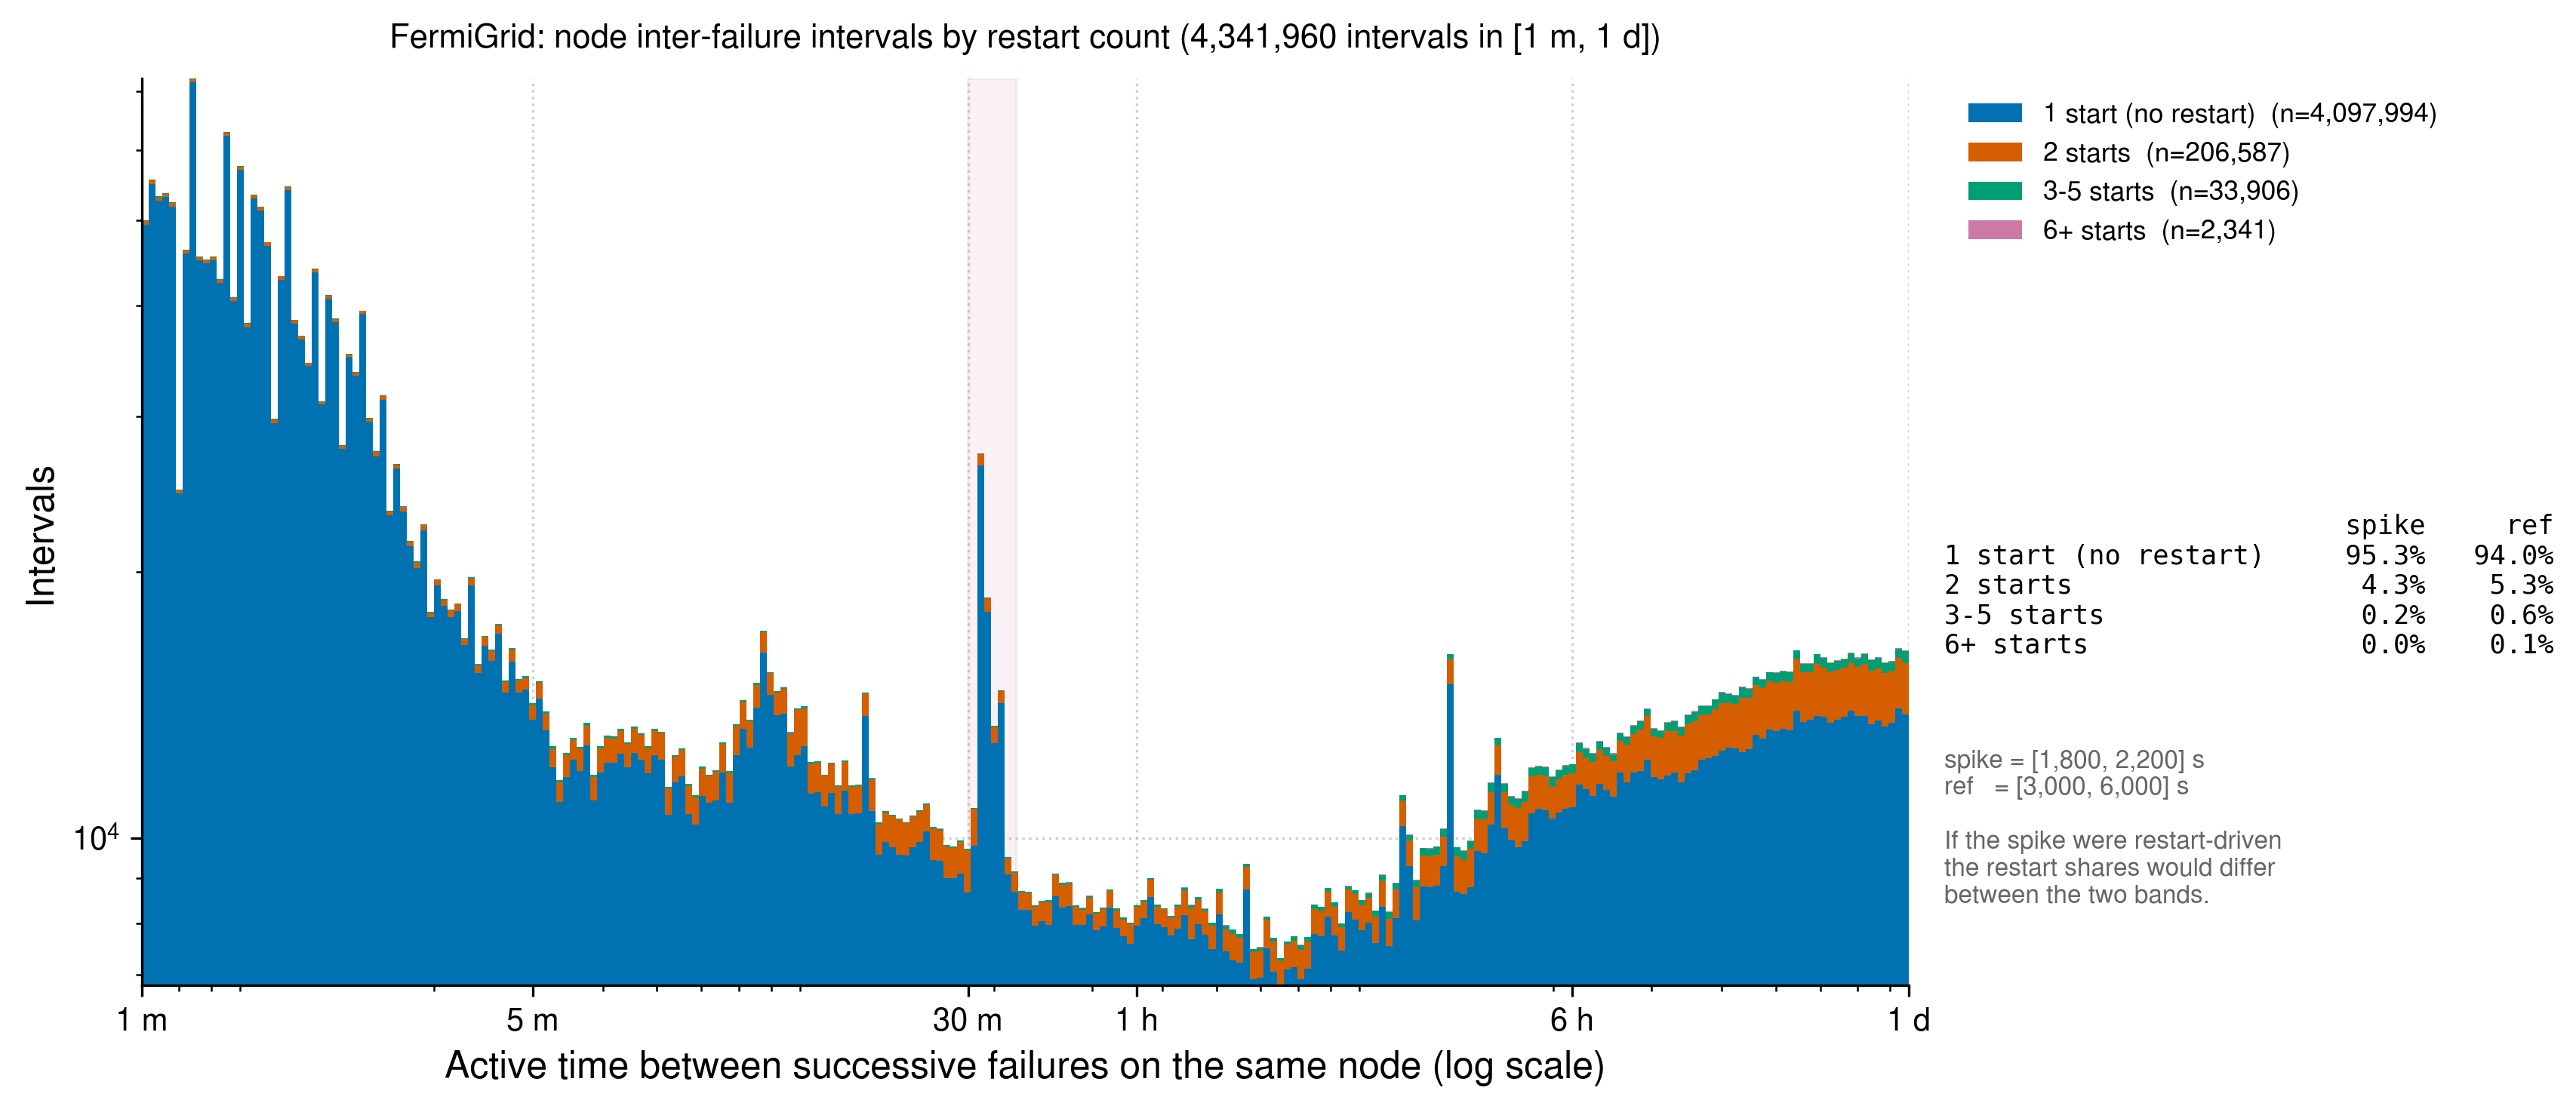

FermiGrid: 4,341,960 node intervals in [60, 86,400] s

restart composition, spike [1,800,2,200] s (n=105,588) vs reference [3,000,6,000] s (n=206,581):
  category                    spike      ref     diff
  1 start (no restart)       95.35%   94.00%   +1.34%
  2 starts                    4.35%    5.29%   -0.94%
  3-5 starts                  0.22%    0.63%   -0.41%
  6+ starts                   0.01%    0.05%   -0.04%

  overall restarted (>1 start): 5.59%
  -> a spike driven by restarts would show a clear excess of >1-start jobs in
     the spike band relative to the reference band.


In [18]:
# Figure: node inter-failure intervals out to 1 day, split by RESTART COUNT.
#
# Tests whether the ~2,000 s spike in the fit above is restart-driven -- i.e. whether
# the interval is closed by a job that had already been restarted, rather than by an
# independent job landing on the same slot. Each job is ONE row here even if it
# restarted, so a restart cannot appear as two failure rows; what the split can show
# is whether the spike is concentrated in jobs carrying NumJobStarts > 1.
#
# Range runs to 86,400 s (the node trailing window) on a LOG x-axis: a linear axis to
# one day would compress the spike to a couple of pixels. Uses the same active-time
# intervals as the fit above.
from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

RESTART_BINS = [(1, 1, "1 start (no restart)", COLORS["primary"]),
                (2, 2, "2 starts", COLORS["secondary"]),
                (3, 5, "3-5 starts", COMPONENTS[0]),
                (6, 10 ** 9, "6+ starts", COLORS["band"])]
RS_LO, RS_HI, RS_NBINS = 60.0, 86_400.0, 260

_edges = np.logspace(np.log10(RS_LO), np.log10(RS_HI), RS_NBINS + 1)
_ctr = np.sqrt(_edges[:-1] * _edges[1:])
_in = (node_gaps >= RS_LO) & (node_gaps <= RS_HI)

fig, ax = plt.subplots(figsize=(11.5, 5), dpi=300)
_bottom = np.zeros(RS_NBINS)
_shares = []
for _lo, _hi, _lab, _col in RESTART_BINS:
    _m = _in & (node_starts >= _lo) & (node_starts <= _hi)
    _h, _ = np.histogram(node_gaps[_m], bins=_edges)
    ax.bar(_ctr, _h, width=np.diff(_edges), bottom=_bottom, color=_col,
           edgecolor="none", zorder=2, label=f"{_lab}  (n={int(_m.sum()):,})")
    _bottom += _h
    _shares.append((_lab, _h))

# The spike, and a quiet reference band, so the comparison is a number not an eyeball.
SPIKE_LO, SPIKE_HI = 1_800.0, 2_200.0
REF_LO, REF_HI = 3_000.0, 6_000.0
ax.axvspan(SPIKE_LO, SPIKE_HI, color=COLORS["band"], alpha=0.10, zorder=1)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(RS_LO, RS_HI)
ax.set_xticks([60, 300, 1800, 3600, 21600, 86400])
ax.set_xticklabels(["1 m", "5 m", "30 m", "1 h", "6 h", "1 d"])
ax.set_xlabel("Active time between successive failures on the same node (log scale)")
ax.set_ylabel("Intervals")
ax.set_title(f"{NODE_SITE}: node inter-failure intervals by restart count "
             f"({int(_in.sum()):,} intervals in [1 m, 1 d])", fontsize=10.5, pad=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.02, 1.0))

_sp = _in & (node_gaps >= SPIKE_LO) & (node_gaps <= SPIKE_HI)
_rf = _in & (node_gaps >= REF_LO) & (node_gaps <= REF_HI)
_tbl = f"{'':22s}{'spike':>8s}{'ref':>8s}\n"
for _lo, _hi, _lab, _ in RESTART_BINS:
    _a = (node_starts[_sp] >= _lo) & (node_starts[_sp] <= _hi)
    _b = (node_starts[_rf] >= _lo) & (node_starts[_rf] <= _hi)
    _tbl += f"{_lab:22s}{_a.mean() * 100:7.1f}%{_b.mean() * 100:7.1f}%\n"
ax.text(1.02, 0.52, _tbl, transform=ax.transAxes, fontsize=8.5, va="top",
        family="monospace")
ax.text(1.02, 0.26,
        f"spike = [{SPIKE_LO:,.0f}, {SPIKE_HI:,.0f}] s\nref   = [{REF_LO:,.0f}, "
        f"{REF_HI:,.0f}] s\n\nIf the spike were restart-driven\nthe restart shares "
        f"would differ\nbetween the two bands.",
        transform=ax.transAxes, fontsize=8, va="top", color=COLORS["neutral"])

plt.tight_layout()
print(save_fig(fig, f"interfailure_node_restarts_{NODE_SITE}"))
plt.show()

print(f"{NODE_SITE}: {int(_in.sum()):,} node intervals in [{RS_LO:,.0f}, {RS_HI:,.0f}] s")
print(f"\nrestart composition, spike [{SPIKE_LO:,.0f},{SPIKE_HI:,.0f}] s "
      f"(n={int(_sp.sum()):,}) vs reference [{REF_LO:,.0f},{REF_HI:,.0f}] s "
      f"(n={int(_rf.sum()):,}):")
print(f"  {'category':24s}{'spike':>9s}{'ref':>9s}{'diff':>9s}")
for _lo, _hi, _lab, _ in RESTART_BINS:
    _a = float(((node_starts[_sp] >= _lo) & (node_starts[_sp] <= _hi)).mean()) * 100
    _b = float(((node_starts[_rf] >= _lo) & (node_starts[_rf] <= _hi)).mean()) * 100
    print(f"  {_lab:24s}{_a:8.2f}%{_b:8.2f}%{_a - _b:+8.2f}%")
print(f"\n  overall restarted (>1 start): "
      f"{float((node_starts[_in] > 1).mean()) * 100:.2f}%")
print("  -> a spike driven by restarts would show a clear excess of >1-start jobs in")
print("     the spike band relative to the reference band.")


output/interfailure_node_jobtype_FermiGrid.pdf


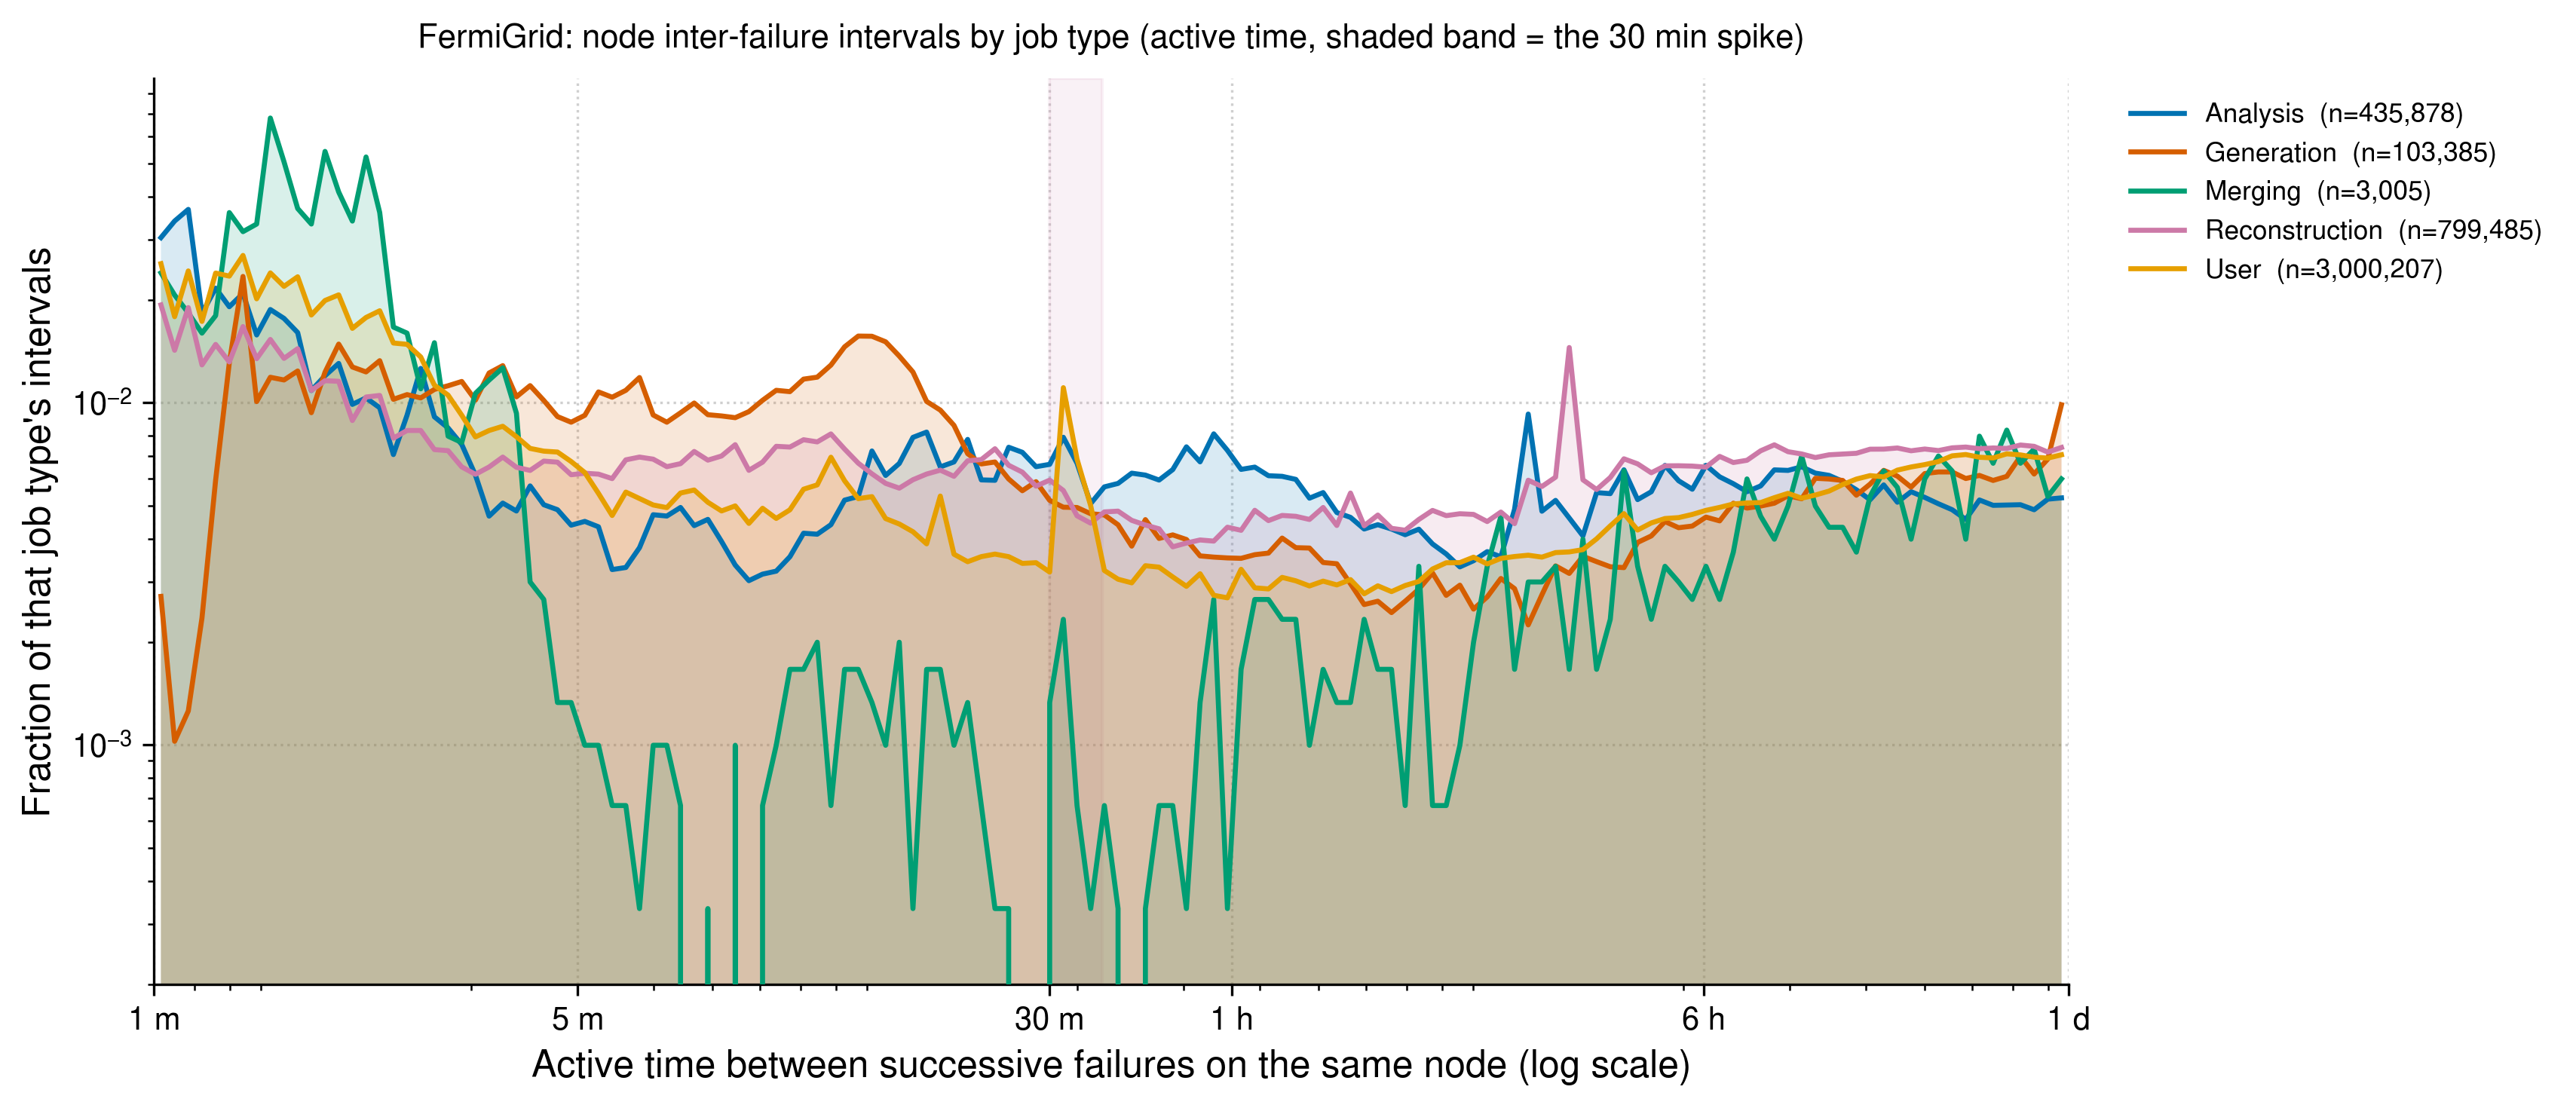


job type             intervals  median (s)  in 1800-2200s
Analysis               435,878         923          2.50%
Generation             103,385         755          1.91%
Merging                  3,005         128          0.33%
Reconstruction         799,485       1,121          1.94%
User                 3,000,207         312          2.57%

  A spike confined to one job type points at that workload; one present across all
  of them points at the machine or the scheduler.


In [19]:
# Figure: node inter-failure intervals by JOB TYPE (seaborn).
#
# Same intervals as the two cells above -- active time between successive failures on
# the same FermiGrid node -- split by the campaign type of the job that closed the
# interval. Asks whether the node-level timescale, and the ~30 min spike, belong to a
# particular kind of work or to the machine.
#
# Binned rather than KDE'd on purpose: a kernel density estimate smooths the spike
# away, and the spike is the feature of interest. Each type is normalised to its own
# interval count, so types spanning three orders of magnitude in volume (User 4.4M vs
# Merging 8.4k failures) are compared on shape rather than size.
import pandas as pd
import seaborn as sns

from vis.style import apply_style, COLORS, COMPONENTS, series_colors, save_fig
apply_style()

JT_LO, JT_HI, JT_NBINS = 60.0, 86_400.0, 140
JT_MIN_N = 2_000                      # types with fewer intervals are too noisy to plot

_edges = np.logspace(np.log10(JT_LO), np.log10(JT_HI), JT_NBINS + 1)
_ctr = np.sqrt(_edges[:-1] * _edges[1:])
_in = (node_gaps >= JT_LO) & (node_gaps <= JT_HI)

_rows = []
for _jt in sorted(set(node_jobtype[_in].tolist())):
    _m = _in & (node_jobtype == _jt)
    if _m.sum() < JT_MIN_N:
        print(f"  [skip] {_jt}: {int(_m.sum()):,} intervals < {JT_MIN_N:,}")
        continue
    _h, _ = np.histogram(node_gaps[_m], bins=_edges)
    _frac = _h / max(_h.sum(), 1)
    _rows.append(pd.DataFrame({"gap_s": _ctr, "frac": _frac,
                               "job_type": f"{_jt}  (n={int(_m.sum()):,})"}))
_df = pd.concat(_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(11.5, 5), dpi=300)
_order = (_df.groupby("job_type")["frac"].sum().index.tolist())
_pal = series_colors(len(_order))

sns.lineplot(data=_df, x="gap_s", y="frac", hue="job_type", hue_order=_order,
             palette=_pal, linewidth=1.6, ax=ax, zorder=3)
# Transparent area under each line; seaborn has no fill for lineplot, so it is drawn
# per hue level against the same palette.
for _n, _lab in enumerate(_order):
    _d = _df[_df["job_type"] == _lab]
    ax.fill_between(_d["gap_s"], _d["frac"], 0, color=_pal[_n], alpha=0.15,
                    linewidth=0, zorder=2)

ax.axvspan(1800, 2200, color=COLORS["band"], alpha=0.10, zorder=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(JT_LO, JT_HI)
ax.set_ylim(max(_df.loc[_df["frac"] > 0, "frac"].min() * 0.6, 1e-6), None)
ax.set_xticks([60, 300, 1800, 3600, 21600, 86400])
ax.set_xticklabels(["1 m", "5 m", "30 m", "1 h", "6 h", "1 d"])
ax.set_xlabel("Active time between successive failures on the same node (log scale)")
ax.set_ylabel("Fraction of that job type's intervals")
ax.set_title(f"{NODE_SITE}: node inter-failure intervals by job type "
             f"(active time, shaded band = the 30 min spike)", fontsize=10.5, pad=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
sns.despine(ax=ax)
ax.legend(title=None, frameon=False, fontsize=8.5, loc="upper left",
          bbox_to_anchor=(1.02, 1.0))

plt.tight_layout()
print(save_fig(fig, f"interfailure_node_jobtype_{NODE_SITE}"))
plt.show()

_sp = _in & (node_gaps >= 1800) & (node_gaps <= 2200)
print(f"\n{'job type':18s}{'intervals':>12s}{'median (s)':>12s}{'in 1800-2200s':>15s}")
for _jt in sorted(set(node_jobtype[_in].tolist())):
    _m = _in & (node_jobtype == _jt)
    if _m.sum() < JT_MIN_N:
        continue
    _share = float((_sp & (node_jobtype == _jt)).sum()) / float(_m.sum())
    print(f"{_jt:18s}{int(_m.sum()):>12,}{np.median(node_gaps[_m]):>12,.0f}"
          f"{_share * 100:>14.2f}%")
print("\n  A spike confined to one job type points at that workload; one present "
      "across all\n  of them points at the machine or the scheduler.")


jobs with a site and a node: 54,465,498
sites by failure count: FermiGrid (6,074,134), RAL (385,072), FZU (350,682), Colorado (210,279), BNL (80,185), UChicago (75,809), Liverpool (65,026), UConn-HPC (57,973)
output/interfailure_node_by_site.pdf


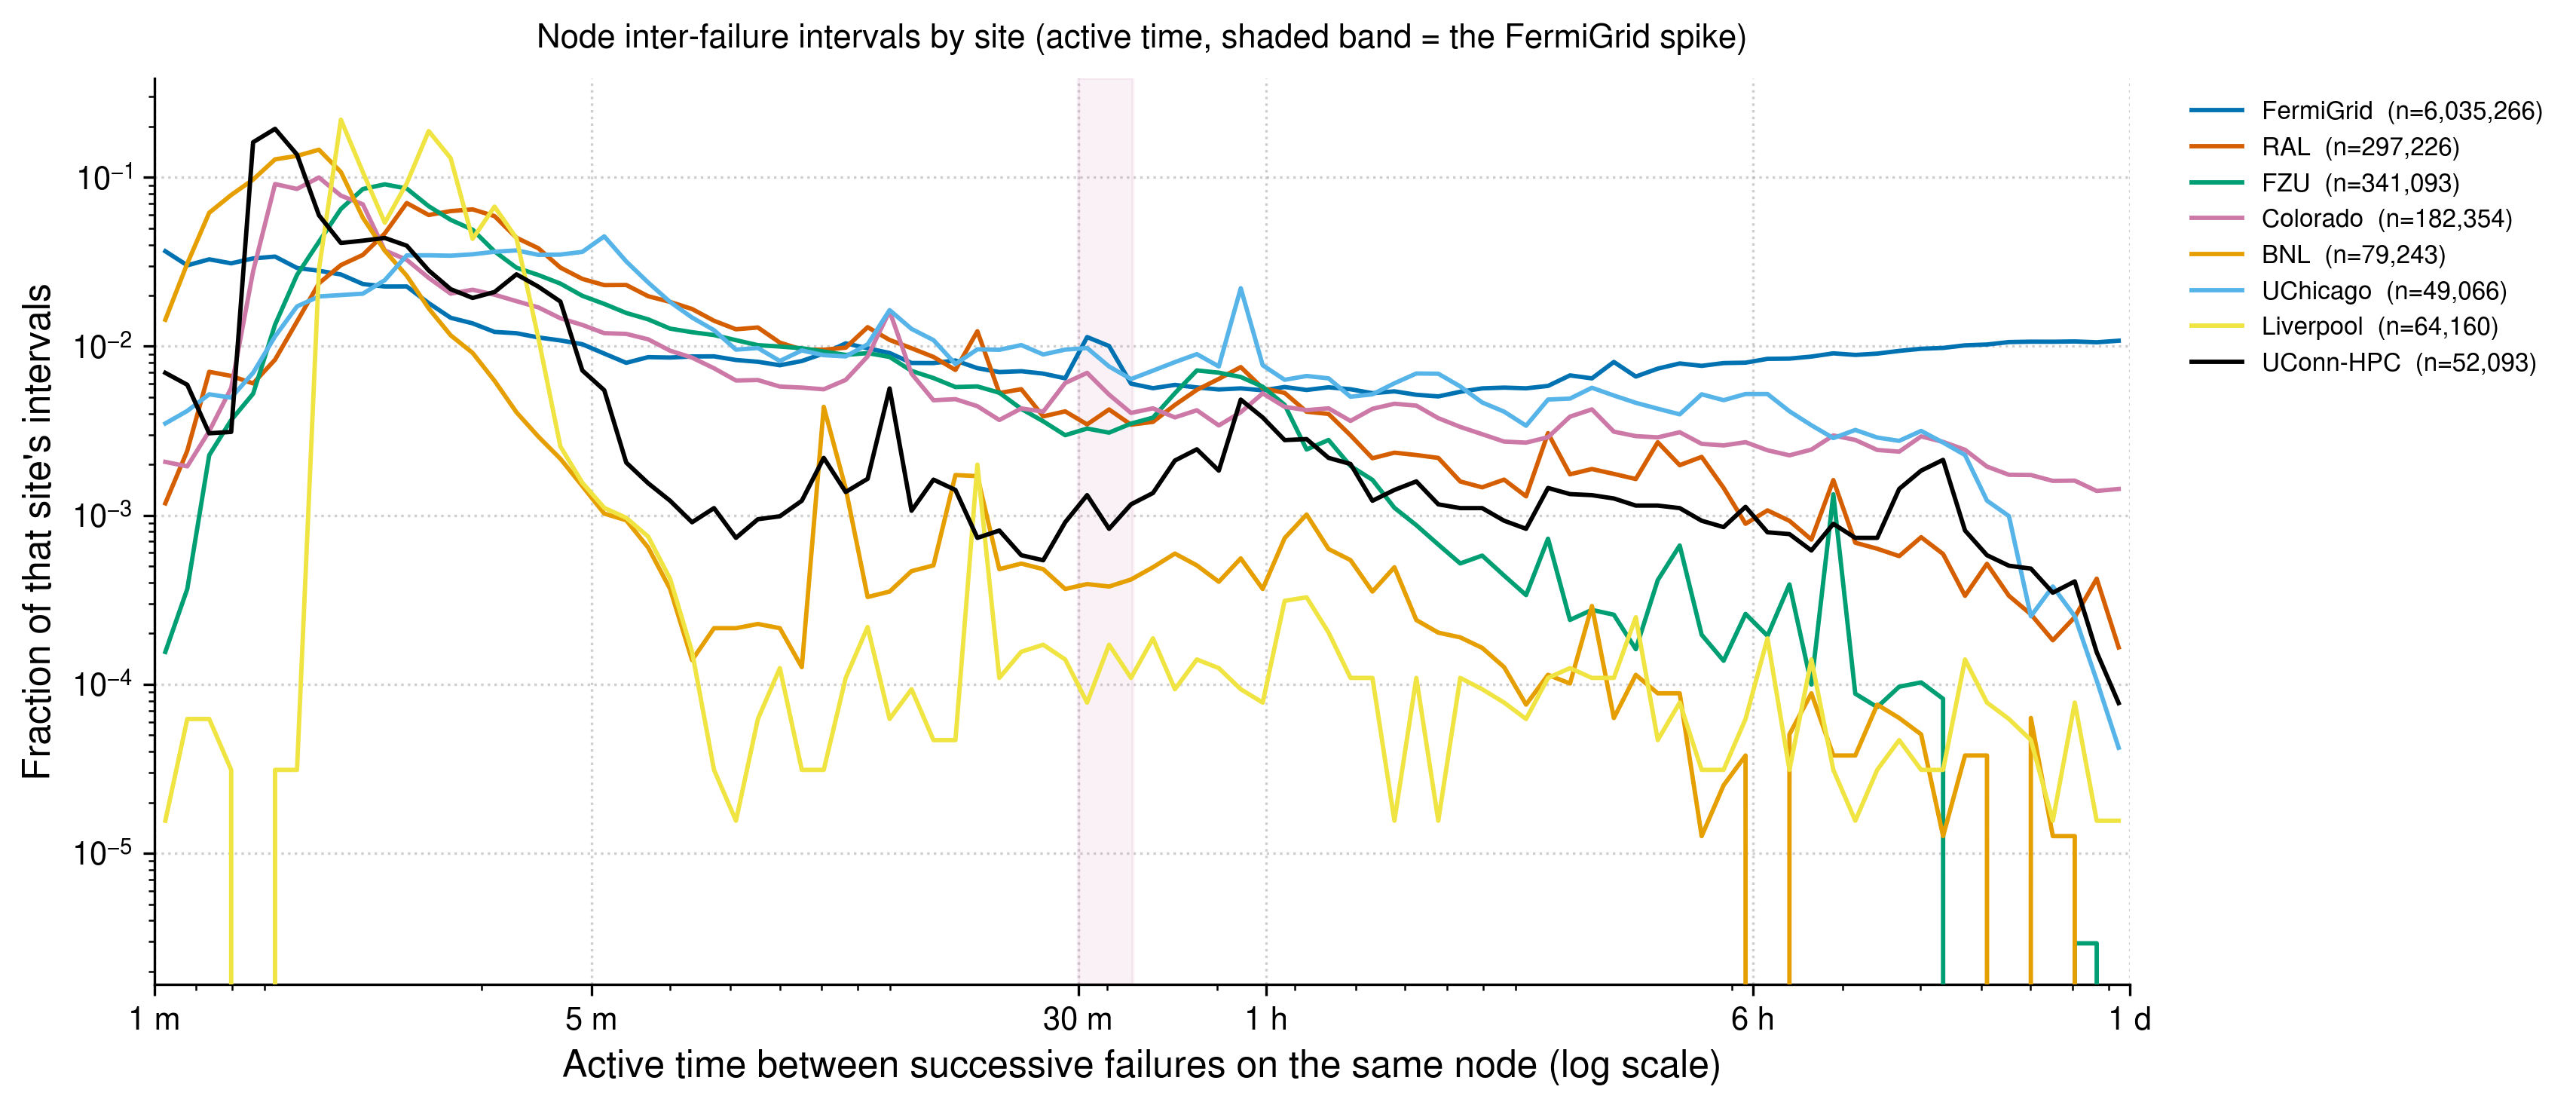


site                           intervals  median (s)  in 1800-2200s
FermiGrid                      6,035,266         352          1.75%
FZU                              341,093         174          0.80%
RAL                              297,226         219          0.94%
Colorado                         182,354         144          1.34%
BNL                               79,243         103          0.10%
Liverpool                         64,160         158          0.03%
UConn-HPC                         52,093         104          0.24%
UChicago                          49,066         317          1.94%

  A spike specific to FermiGrid points at something local (its pilot configuration);
  one shared across sites points at the workload or the scheduler.


In [20]:
# Figure: node inter-failure intervals overlaid, one line per SITE.
#
# The fit above is FermiGrid only. This asks whether the node-level timescale is a
# property of FermiGrid or of the workload generally -- and in particular whether the
# ~2,000 s spike appears anywhere else.
#
# Active time throughout: a slot is idle between jobs, so raw elapsed badly overstates
# exposure (57.6% of FermiGrid node gap time is idle). Busy time is computed per node
# exactly as in the fit cell, but over every site at once.
from vis.style import apply_style, COLORS, COMPONENTS, series_colors, save_fig
apply_style()

NS_SITES = 8                 # busiest sites by failure count
NS_LO, NS_HI, NS_NBINS = 60.0, 86_400.0, 90

_aj = (lf_anon.filter(pl.col(SITECOL).is_not_null(), pl.col(NODEKEY).is_not_null(),
                      pl.col("JobStartDate_ms") > 0, pl.col("CompletionDate_ms") > 0)
       .select([SITECOL, pl.col(NODEKEY).alias("k"),
                (pl.col("JobStartDate_ms") // 1000).alias("s"),
                (pl.col("CompletionDate_ms") // 1000).alias("c"), "Failed"])
       .collect())
print(f"jobs with a site and a node: {_aj.height:,}")

_site = _aj[SITECOL].to_numpy()
_ka = _aj["k"].to_numpy().astype(np.int64)
_sa = _aj["s"].to_numpy().astype(np.int64)
_ca = np.maximum(_aj["c"].to_numpy().astype(np.int64), _sa)
_fa = _aj["Failed"].to_numpy().astype(bool)

# Per-node busy time, same construction as the fit cell (a slot is serial).
_T0 = int(min(_sa.min(), _ca.min()))
_SPAN = int(max(_sa.max(), _ca.max())) - _T0 + 3
_D = (_ca - _sa).astype(np.float64)
_E = _ka * _SPAN + (_ca - _T0)
_O = np.argsort(_E, kind="mergesort")
_ES = _E[_O]
_CUM = np.concatenate([[0.0], np.cumsum(_D[_O])])

def _busy_all(kk, tt):
    q = kk * _SPAN + np.clip(tt - _T0, 0, _SPAN - 1)
    return _CUM[np.searchsorted(_ES, q, "right")] \
         - _CUM[np.searchsorted(_ES, kk * _SPAN, "left")]

_counts = {}
for _s_name in np.unique(_site[_fa]):
    _counts[_s_name] = int((_fa & (_site == _s_name)).sum())
_top = [s for s, _ in sorted(_counts.items(), key=lambda kv: -kv[1])[:NS_SITES]]
print("sites by failure count: " + ", ".join(f"{s} ({_counts[s]:,})" for s in _top))

_edges = np.logspace(np.log10(NS_LO), np.log10(NS_HI), NS_NBINS + 1)
_ctr = np.sqrt(_edges[:-1] * _edges[1:])
_pal = series_colors(len(_top))

fig, ax = plt.subplots(figsize=(11.5, 5), dpi=300)
_summary = []
for _n, _s_name in enumerate(_top):
    _m = _fa & (_site == _s_name)
    _kk, _tt = _ka[_m], _ca[_m]
    _o = np.lexsort((_tt, _kk)); _kk, _tt = _kk[_o], _tt[_o]
    if len(_kk) < 100:
        continue
    _sm = _kk[1:] == _kk[:-1]
    if _sm.sum() < 100:
        continue
    _k1, _tp, _tn = _kk[1:][_sm], _tt[:-1][_sm], _tt[1:][_sm]
    _raw = (_tn - _tp).astype(np.float64)
    _act = np.clip(_busy_all(_k1, _tn) - _busy_all(_k1, _tp), 0, _raw)
    _act = _act[_raw > 0]
    if len(_act) < 100:
        continue
    _h, _ = np.histogram(_act, bins=_edges)
    # Density per bin so sites of very different size are comparable in shape.
    _dens = _h / max(_h.sum(), 1)
    ax.plot(_ctr, _dens, color=_pal[_n], linewidth=1.4, zorder=3,
            label=f"{_s_name}  (n={len(_act):,})")
    _summary.append((_s_name, len(_act), float(np.median(_act)),
                     float(np.mean((_act >= 1800) & (_act <= 2200)))))

ax.axvspan(1800, 2200, color=COLORS["band"], alpha=0.10, zorder=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(NS_LO, NS_HI)
ax.set_xticks([60, 300, 1800, 3600, 21600, 86400])
ax.set_xticklabels(["1 m", "5 m", "30 m", "1 h", "6 h", "1 d"])
ax.set_xlabel("Active time between successive failures on the same node (log scale)")
ax.set_ylabel("Fraction of that site's intervals")
ax.set_title("Node inter-failure intervals by site (active time, shaded band = the "
             "FermiGrid spike)", fontsize=10.5, pad=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))

plt.tight_layout()
print(save_fig(fig, "interfailure_node_by_site"))
plt.show()

print(f"\n{'site':28s}{'intervals':>12s}{'median (s)':>12s}{'in 1800-2200s':>15s}")
for _s_name, _n_i, _med, _sp in sorted(_summary, key=lambda r: -r[1]):
    print(f"{str(_s_name)[:28]:28s}{_n_i:>12,}{_med:>12,.0f}{_sp * 100:>14.2f}%")
print("\n  A spike specific to FermiGrid points at something local (its pilot "
      "configuration);\n  one shared across sites points at the workload or the "
      "scheduler.")

BIC sweep fitted in 78.3s (cached; re-runs of this cell reuse it)
output/queue_wait_mixture_FermiGrid.pdf


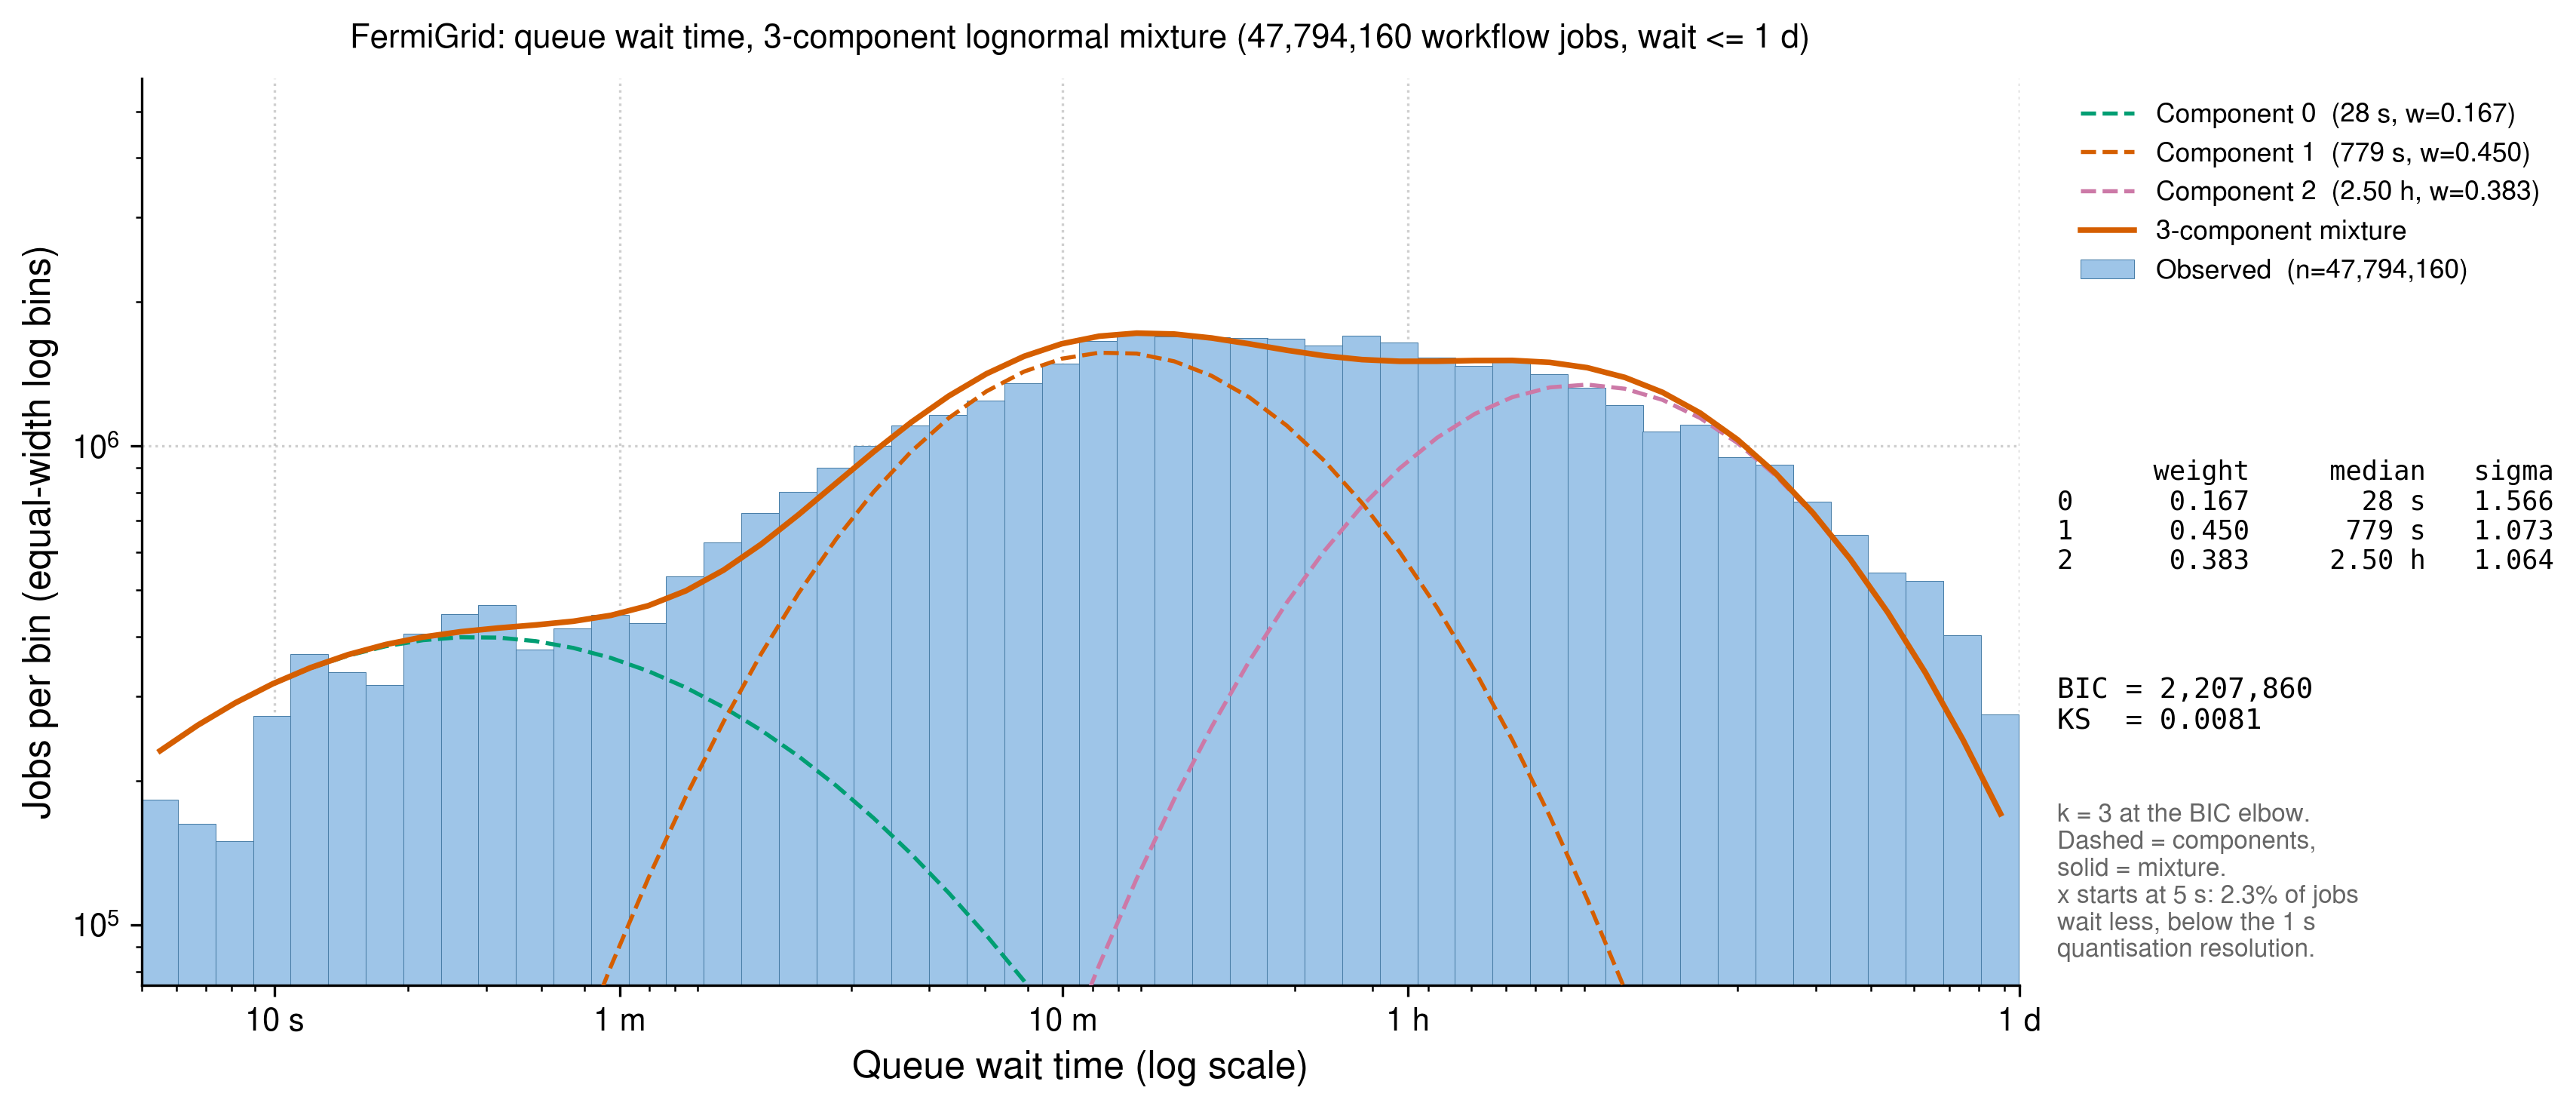

binning: 50 uniform log bins over [5 s, 24 h], 0 empty
  log-width 0.0848-0.0848 decades (spread 1.00x -- bars are comparable)
  narrowest bin 1.08 s (>= the 1 s data quantum)
  below 5 s: 1,095,330 jobs (2.29%), not plotted
  obs/exp: first bin 0.790, median bin 1.003, last bin 1.614
  -> output/queue_wait_mixture_FermiGrid.pdf
FermiGrid: 48,998,479 jobs with wait > 0
  - 1,204,319 (2.46%) over the 24 h cap
  - 0 pilots (Cmd == ./glidein_startup.sh)
  = 47,794,160 workflow jobs fitted

 k          BIC       dBIC       KS
 1    2,256,260              0.0500
 2    2,217,773    -38,487   0.0192
 3    2,207,860     -9,913   0.0081
 4    2,206,092     -1,768   0.0092
 5    2,204,452     -1,641   0.0074
 6    2,202,254     -2,198   0.0072
 7    2,201,115     -1,139   0.0069
 8    2,201,149         34   0.0069

k = 3 (BIC elbow; raw argmin is k = 7, see header note)
  component 0: weight  0.167  median         28 s (     0.5 min)  sigma_log 1.566
  component 1: weight  0.450  median        7

In [21]:
# Figure: FermiGrid queue wait as a 3-component LOGNORMAL MIXTURE.
#
# Same presentation as the inter-failure fit above -- binned data, fitted curve,
# parameter table, fit statistics -- but with a model that describes the data. The
# two-exponential form used for failure intervals gave chi2/ndof ~ 104 on these waits;
# no range or third component rescued it. Failures are an arrival process, which
# mixtures of exponentials fit naturally; waits are a queueing OUTCOME.
#
# Population. Two filters beyond "wait > 0":
#   * MIX_CAP -- waits above one day are treated as outliers (2.46% of the slice,
#     tail reaching 22 days). The fit is therefore a statement about waits up to
#     one day; the distribution itself runs smoothly through the cap -- only 25
#     jobs sit at exactly 86,400 s and 42,417 fall in the following hour -- so
#     the cap is a modelling choice, not a boundary in the data.
#   * pilots -- glidein pilots (Group == "group_opportunistic", the population whose
#     Cmd is ./glidein_startup.sh) are infrastructure, not workflow jobs. They are
#     already absent here because every pilot carries a NULL site and this cell slices
#     on SITECOL, but the guard is explicit so the intent survives a change of slice.
#
# Axis is log-x with LOG-SPACED bins: a lognormal mixture is a Gaussian mixture in log
# space, so that is the scale on which the components show up as separate humps
# instead of one skewed blob.
#
# Choice of k. BIC over 1..8 is printed below and its raw minimum is NOT 3 -- with a
# 500k fit sample the complexity penalty (ln n ~ 13 per parameter) is negligible next
# to the likelihood gain, so BIC keeps buying components that chase the truncation
# edge. The curve elbows at 3 (dBIC -38k, -10k, then ~-1.7k per step) and KS is flat
# past 3, so k is fixed at 3 on parsimony with the sweep printed as the justification.
import time as _time

from sklearn.mixture import GaussianMixture
from scipy import stats as _stats

from vis.style import apply_style, COLORS, COMPONENTS, SERIES, save_fig
apply_style()

MIX_SITE = FIT_SITE if "FIT_SITE" in dir() else "FermiGrid"
MIX_K = 3
MIX_CAP = 86_400.0          # waits above one day are outliers, not queueing delay
MIX_KMAX = 8                # BIC sweep upper bound (reported, not used to select)
MIX_SAMPLE = 500_000        # GMM fit sample; the histogram uses every job
MIX_BINS = 60
# A pilot is exactly Cmd == "./glidein_startup.sh", carried into the anonymised
# extract as the IsPilot flag. Older extracts predate the flag; there the site slice
# is already a sufficient guard, because not one of the 5,209,738 pilots in the raw
# data carries a site (checked over all 71,158,721 rows).
_HAVE_PILOT_FLAG = "IsPilot" in lf_anon.collect_schema().names()
_not_pilot = (~pl.col("IsPilot").fill_null(False)) if _HAVE_PILOT_FLAG else pl.lit(True)

_mw = (lf_anon.filter(
           pl.col(SITECOL) == MIX_SITE,
           pl.col("wait_s") > 0,
           pl.col("wait_s") <= MIX_CAP,
           _not_pilot)
       .select("wait_s").collect()["wait_s"].to_numpy().astype(float))

# How much the two population filters removed, so the caption can state it.
_raw = lf_anon.filter(pl.col(SITECOL) == MIX_SITE, pl.col("wait_s") > 0).select(
    n=pl.len(),
    over_cap=(pl.col("wait_s") > MIX_CAP).sum(),
    pilots=(pl.col("IsPilot").fill_null(False).sum() if _HAVE_PILOT_FLAG else pl.lit(0)),
).collect().to_dicts()[0]

_rng = np.random.default_rng(0)
_fit_s = np.log(_rng.choice(_mw, min(MIX_SAMPLE, len(_mw)), replace=False)).reshape(-1, 1)
_ks_s = np.sort(np.log(_rng.choice(_mw, 50_000, replace=False)))

def _gm_stats(gm):
    """Sorts a fitted GMM by mean and returns (weights, mus, sds, KS)."""
    o = np.argsort(gm.means_.ravel())
    w, mu = gm.weights_[o], gm.means_.ravel()[o]
    sd = np.sqrt(gm.covariances_.ravel())[o]
    c = sum(wt * _stats.norm.cdf(_ks_s, m, s) for wt, m, s in zip(w, mu, sd))
    return w, mu, sd, _stats.kstest(_ks_s, lambda z: np.interp(z, _ks_s, c)).statistic

# BIC sweep. Printed in full because the raw argmin over-selects; see header note.
#
# Cached: this is the whole cost of the cell. The parquet scan is ~1 s, but 8 fits
# x 3 restarts on 500k points is ~60 s, and re-running the cell to adjust a figure
# refits all of it for nothing. The key covers everything the fit depends on, so a
# changed cap, sample size or k-range refits automatically. Set MIX_REFIT = True to
# force one.
MIX_REFIT = False
_mix_key = (MIX_SITE, MIX_CAP, MIX_SAMPLE, MIX_KMAX, len(_mw))
try:
    _MIX_CACHE
except NameError:
    _MIX_CACHE = {}

if MIX_REFIT or _mix_key not in _MIX_CACHE:
    _t0 = _time.perf_counter()
    _sweep, _fits = [], {}
    for _k in range(1, MIX_KMAX + 1):
        _g = GaussianMixture(_k, random_state=0, n_init=3, max_iter=800).fit(_fit_s)
        _w, _m, _s, _kk = _gm_stats(_g)
        _sweep.append((_k, _g.bic(_fit_s), _kk))
        _fits[_k] = (_w, _m, _s, _g.bic(_fit_s), _kk)
    _MIX_CACHE[_mix_key] = (_sweep, _fits)
    print(f"BIC sweep fitted in {_time.perf_counter() - _t0:.1f}s (cached; "
          f"re-runs of this cell reuse it)")
else:
    print("BIC sweep loaded from cache (set MIX_REFIT = True to refit)")
_sweep, _fits = _MIX_CACHE[_mix_key]

_wts, _mus, _sds, _bic, _ks_stat = _fits[MIX_K]
_ks1 = _fits[1][4]

# Binning. UNIFORM log-spaced bins -- every bin the same width in log space, which
# is what makes "jobs per bin" a fair comparison across a log axis. An earlier
# version floored the bin step at the 1 s data quantum to kill empty bins near the
# left edge; that worked while y was a per-second density (which divides by each
# bin's own width) but is wrong now that y is a raw count, because it left the first
# few bins 1 s wide in time while the rest grew geometrically -- a 79.9x spread in
# log width, so those bars were not comparable to the rest of the plot.
#
# wait_s is integer-valued, so a bin narrower than 1 s can contain no attainable
# value and comes out necessarily empty. Uniform log bins therefore have to start
# where the first bin is already at least a second wide: 50 bins from 5 s gives a
# ratio of 1.2155 and a narrowest bin of 1.08 s. Jobs below 5 s are counted and
# reported, not silently dropped -- the log axis simply has no resolution there.
MIX_XMIN = 5.0
MIX_NBINS = 50

_edges = np.logspace(np.log10(MIX_XMIN), np.log10(MIX_CAP), MIX_NBINS + 1)
_ctr = np.sqrt(_edges[:-1] * _edges[1:])
_cnt, _ = np.histogram(_mw, bins=_edges)
_n_below = int((_mw < MIX_XMIN).sum())

# The mixture is fitted to the capped sample but is not itself truncated, so it puts
# 0.64% of its mass above the cap. Renormalising by that keeps the curve's area equal
# to the number of jobs actually plotted.
_trunc = float(sum(wt * _stats.norm.cdf(np.log(MIX_CAP), mu, sd)
                   for wt, mu, sd in zip(_wts, _mus, _sds)))


def _expected_counts(edges, comp=None):
    """Expected jobs per bin: n * (F(hi) - F(lo)), NOT n * binwidth * f(centre).

    The bars are integrals of the density over a bin, so the curve has to be one
    too, and it is evaluated at the histogram's own edges rather than on a finer
    grid -- at sub-bin resolution the density near t = 0 spikes and the curve stops
    matching the bars it is meant to be read against. F is taken on the truncated
    population, hence the division by the mass below the cap.

    `comp` selects a single component; None gives the full mixture.
    """
    e = np.clip(np.asarray(edges, dtype=float), 1e-9, None)
    ks = range(len(_wts)) if comp is None else [comp]
    F = sum(_wts[k] * _stats.norm.cdf(np.log(e), _mus[k], _sds[k]) for k in ks)
    return len(_mw) * np.diff(F) / _trunc


_exp = _expected_counts(_edges)
_ccol = [COMPONENTS[0], COLORS["secondary"], COMPONENTS[1]]

# Extra width is the right-hand margin the legend and parameter table sit in.
fig, ax = plt.subplots(figsize=(11.5, 5), dpi=300)
ax.bar(_ctr, _cnt, width=np.diff(_edges), color=COLORS["hist"], edgecolor=BASE_COLOR,
       linewidth=0.25, zorder=2)
for i, (wt, mu, sd) in enumerate(zip(_wts, _mus, _sds)):
    _med = np.exp(mu)
    _lab = f"{_med:,.0f} s" if _med < 3600 else f"{_med / 3600:,.2f} h"
    ax.plot(_ctr, _expected_counts(_edges, comp=i), color=_ccol[i],
            linewidth=1.3, linestyle="--", zorder=3,
            label=f"Component {i}  ({_lab}, w={wt:.3f})")
ax.plot(_ctr, _exp, color=COLORS["fit"], linewidth=1.8, zorder=4,
        label=f"{MIX_K}-component mixture")
ax.bar(0, 0, color=COLORS["hist"], edgecolor=BASE_COLOR, linewidth=0.25,
       label=f"Observed  (n={len(_mw):,})")

# Bins are equal-width in log time, so bar height is proportional to the density in
# log space -- the scale the mixture is Gaussian on, which is why the components
# read as three separate humps here.
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks([10, 60, 600, 3600, 86400])
ax.set_xticklabels(["10 s", "1 m", "10 m", "1 h", "1 d"])
ax.set_xlim(_edges[0], _edges[-1])
ax.set_ylim(max(_cnt[_cnt > 0].min() * 0.5, 0.5), None)
ax.set_xlabel("Queue wait time (log scale)")
ax.set_ylabel("Jobs per bin (equal-width log bins)")
ax.set_title(f"{MIX_SITE}: queue wait time, {MIX_K}-component lognormal mixture "
             f"({len(_mw):,} workflow jobs, wait <= 1 d)", fontsize=10.5, pad=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Legend and table live outside the axes on the right, so neither sits on top of the
# data -- there is no interior region that stays clear across the whole x-range.
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.02, 1.0))
_tbl = f"{'':4s}{'weight':>8s}{'median':>11s}{'sigma':>8s}\n"
for i, (wt, mu, sd) in enumerate(zip(_wts, _mus, _sds)):
    _med = np.exp(mu)
    _u = f"{_med:,.0f} s" if _med < 3600 else f"{_med / 3600:,.2f} h"
    _tbl += f"{i:<4d}{wt:>8.3f}{_u:>11s}{sd:>8.3f}\n"
ax.text(1.02, 0.58, _tbl, transform=ax.transAxes, fontsize=8.5, va="top",
        family="monospace")
ax.text(1.02, 0.34, f"BIC = {_bic:,.0f}\nKS  = {_ks_stat:.4f}",
        transform=ax.transAxes, fontsize=9, va="top", family="monospace")
ax.text(1.02, 0.20,
        f"k = 3 at the BIC elbow.\nDashed = components,\nsolid = mixture.\n"
        f"x starts at {MIX_XMIN:.0f} s: {_n_below / len(_mw) * 100:.1f}% of jobs\n"
        f"wait less, below the 1 s\nquantisation resolution.",
        transform=ax.transAxes, fontsize=8, va="top", color=COLORS["neutral"])

_out = f"queue_wait_mixture_{MIX_SITE}"        # save_fig() adds output/ and .pdf
plt.tight_layout()
print(save_fig(fig, _out))
plt.show()

_lw = np.diff(np.log10(_edges))
print(f"binning: {MIX_NBINS} uniform log bins over [{MIX_XMIN:.0f} s, "
      f"{MIX_CAP / 3600:.0f} h], {int((_cnt == 0).sum())} empty")
print(f"  log-width {_lw.min():.4f}-{_lw.max():.4f} decades "
      f"(spread {_lw.max() / _lw.min():.2f}x -- bars are comparable)")
print(f"  narrowest bin {np.diff(_edges).min():.2f} s (>= the 1 s data quantum)")
print(f"  below {MIX_XMIN:.0f} s: {_n_below:,} jobs "
      f"({_n_below / len(_mw) * 100:.2f}%), not plotted")
print(f"  obs/exp: first bin {_cnt[0] / _exp[0]:.3f}, "
      f"median bin {np.median(_cnt / _exp):.3f}, last bin {_cnt[-1] / _exp[-1]:.3f}")
print(f"  -> output/{_out}.pdf")

print(f"{MIX_SITE}: {_raw['n']:,} jobs with wait > 0")
print(f"  - {_raw['over_cap']:,} ({_raw['over_cap'] / _raw['n'] * 100:.2f}%) over the "
      f"{MIX_CAP / 3600:.0f} h cap")
print(f"  - {_raw['pilots']:,} pilots (Cmd == ./glidein_startup.sh)"
      + ("" if _HAVE_PILOT_FLAG else "  [IsPilot flag absent; excluded by the site slice]"))
print(f"  = {len(_mw):,} workflow jobs fitted\n")
print(f"{'k':>2} {'BIC':>12} {'dBIC':>10} {'KS':>8}")
_prev = None
for _k, _b, _kk in _sweep:
    print(f"{_k:>2} {_b:>12,.0f} {'' if _prev is None else f'{_b - _prev:,.0f}':>10} {_kk:>8.4f}")
    _prev = _b
print(f"\nk = {MIX_K} (BIC elbow; raw argmin is k = {min(_sweep, key=lambda r: r[1])[0]}, "
      f"see header note)")
for i, (wt, mu, sd) in enumerate(zip(_wts, _mus, _sds)):
    print(f"  component {i}: weight {wt:6.3f}  median {np.exp(mu):>10,.0f} s "
          f"({np.exp(mu) / 60:>8,.1f} min)  sigma_log {sd:.3f}")
print(f"  BIC = {_bic:,.0f}   KS = {_ks_stat:.4f}   (single lognormal KS = {_ks1:.4f})")

# Variance decomposition -- consumed by the E2 baseline in eval/helper.py. NOTE this
# is k-dependent (it rises mechanically with k), so it is a property of THIS
# decomposition, not a physical bound on what any model could achieve.
_vt = float((_wts * (_sds ** 2 + _mus ** 2)).sum() - (_wts * _mus).sum() ** 2)
_vw = float((_wts * _sds ** 2).sum())
print(f"  log-space variance: total {_vt:.3f} (sd {np.sqrt(_vt):.3f}), "
      f"within-component {_vw:.3f} (sd {np.sqrt(_vw):.3f}), "
      f"between-component share {1 - _vw / _vt:.3f}")
MIX_PARAMS = {"site": MIX_SITE, "k": MIX_K, "cap_s": MIX_CAP,
              "weights": _wts.tolist(), "mus": _mus.tolist(), "sds": _sds.tolist(),
              "n": int(len(_mw)), "bic": float(_bic), "ks": float(_ks_stat)}


### Queue wait mixture, all sites pooled

BIC sweep fitted in 44.2s (cached)
output/queue_wait_mixture_allsites.pdf


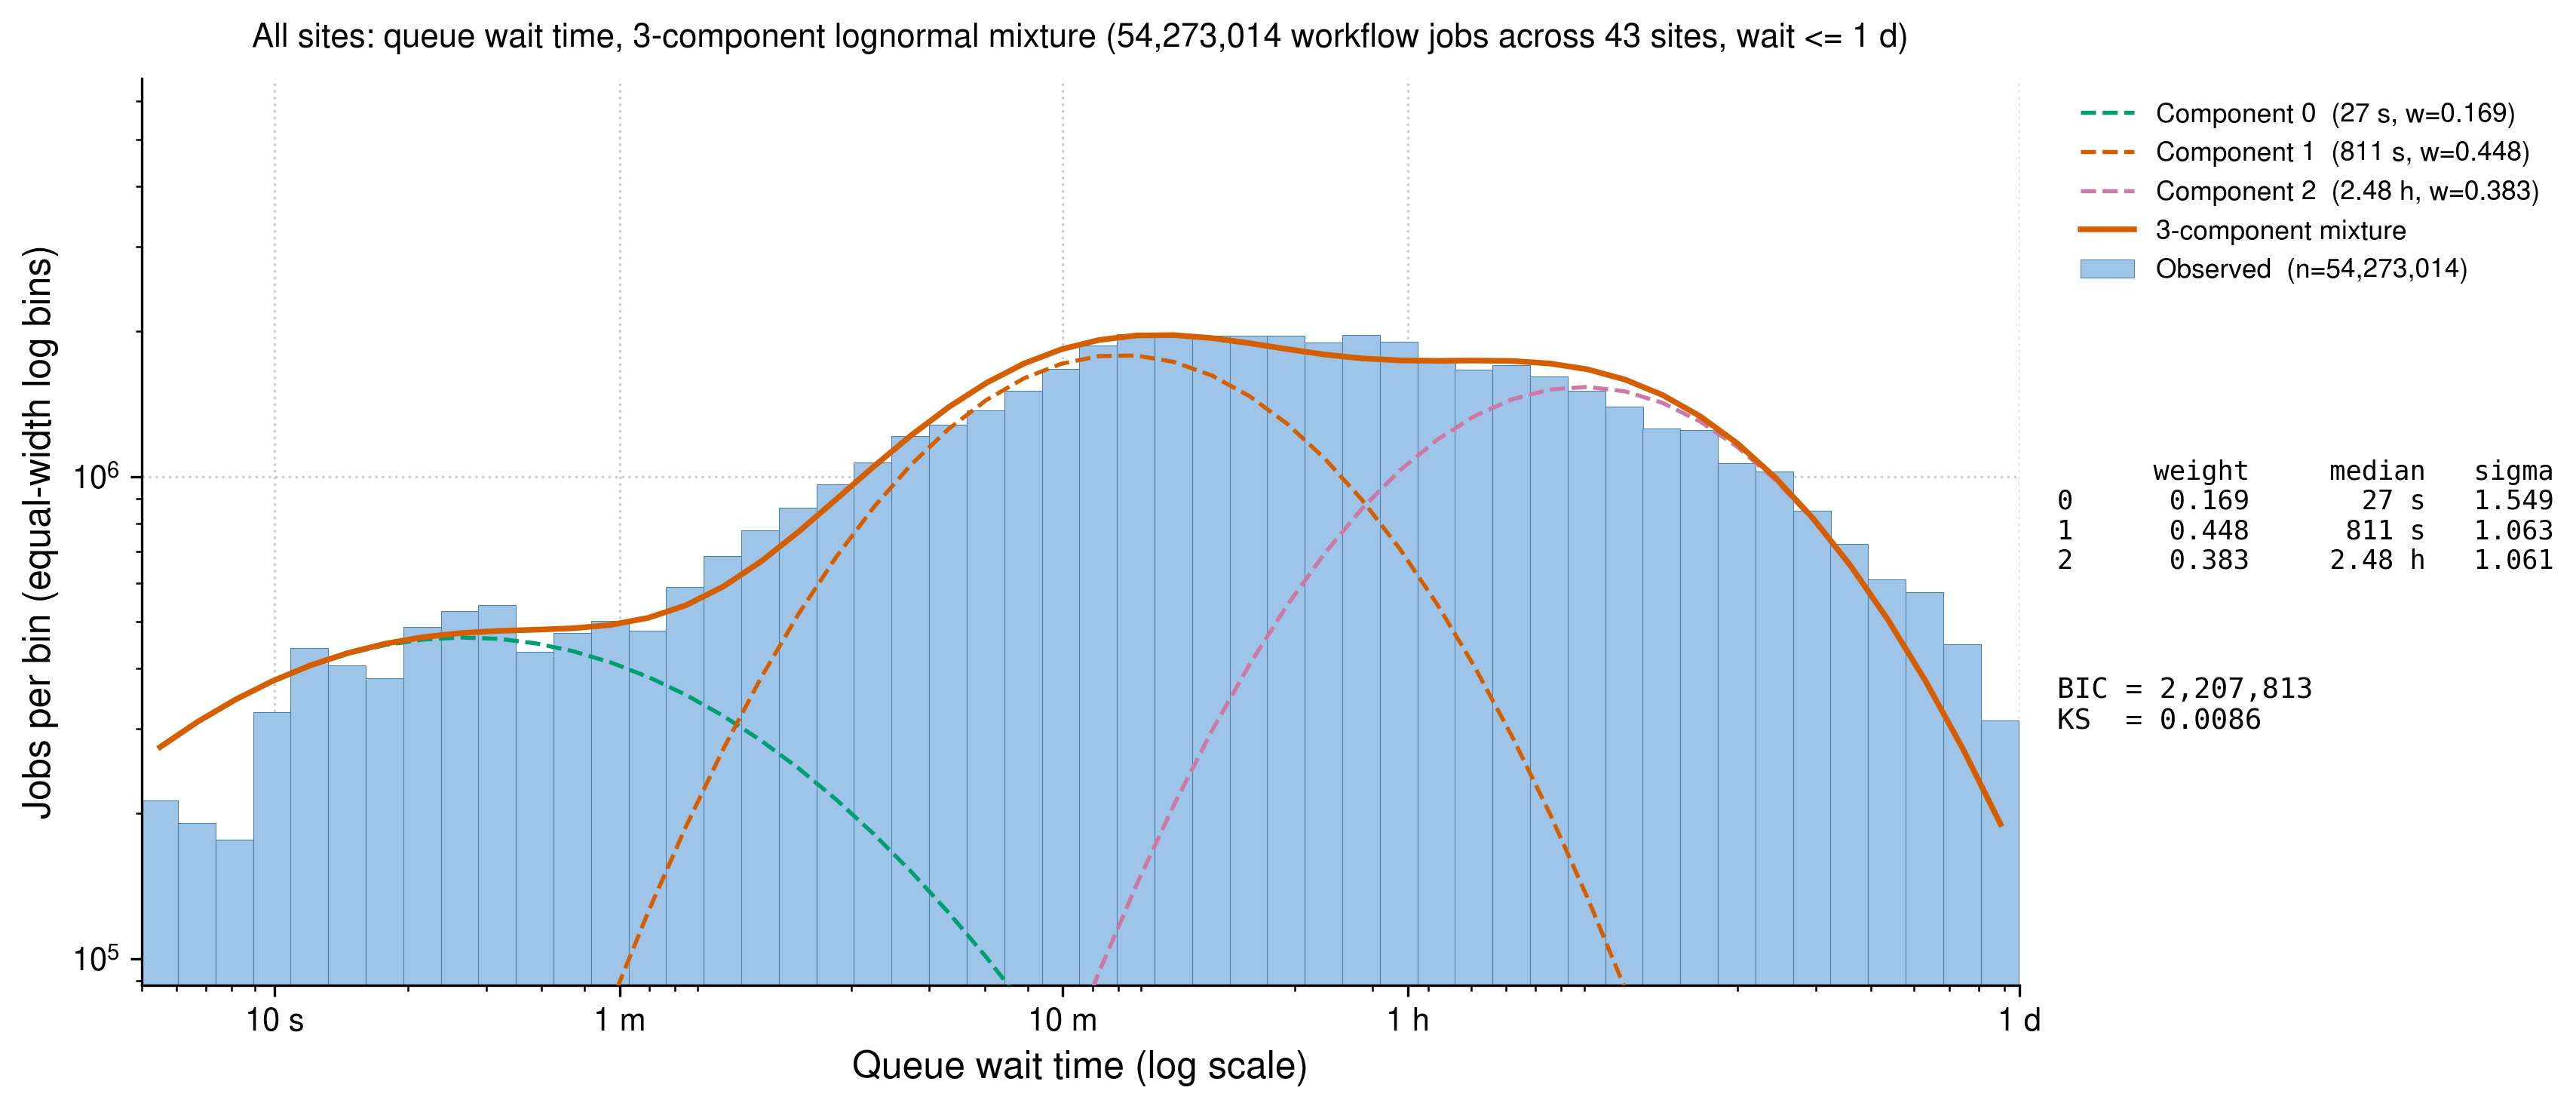

all sites: 56,476,143 records with wait > 0
  - 785,362 pilots (Cmd == ./glidein_startup.sh)
  - 818,946 with no named site
  - 1,384,183 over the 24 h cap
  = 54,273,014 workflow jobs fitted across 43 sites

 k          BIC       dBIC       KS
 1    2,261,420              0.0549
 2    2,216,956    -44,463   0.0165
 3    2,207,813     -9,144   0.0086
 4    2,206,224     -1,589   0.0079
 5    2,205,001     -1,223   0.0083
 6    2,203,501     -1,499   0.0064
 7    2,201,600     -1,902   0.0052
 8    2,201,768        168   0.0050

k = 3 (BIC argmin here is k = 7)
  component 0: weight  0.169  median         27 s (     0.4 min)  sigma_log 1.549
  component 1: weight  0.448  median        811 s (    13.5 min)  sigma_log 1.063
  component 2: weight  0.383  median      8,931 s (   148.8 min)  sigma_log 1.061
  BIC = 2,207,813   KS = 0.0086   (single lognormal KS = 0.0549)
  log-space variance: total 5.392, within 1.343, between-component share 0.751

FermiGrid share of the pooled population: 

In [22]:
# Figure: queue wait as a 3-component lognormal mixture over ALL SITES, not just
# FermiGrid. Same model, binning and k as the cell above; only the population differs.
#
# Population. Every submit-time record with a NAMED site, pilots excluded:
#   * named site -- the null site level is pilots plus scheduler-universe jobs that
#     never matched. The latter have no start time, so wait_s is null and they are
#     already gone; requiring a named site is what keeps the population comparable
#     to the per-site fit above.
#   * pilots -- the FermiGrid cell got pilot exclusion for free, because no pilot
#     carries a site and it sliced on SITECOL. Pooling over sites removes that
#     guard, so the IsPilot filter is load-bearing here: without it ~5.1M glidein
#     records join the distribution. The assert below fails loudly rather than
#     fitting a contaminated population on an older extract.
#
# All names are prefixed A_ so this cell cannot overwrite the FermiGrid fit in the
# shared namespace -- WAIT_MIX in eval/helper.py is the FermiGrid one.
from vis.style import apply_style, COLORS, COMPONENTS, save_fig
apply_style()

A_K, A_CAP, A_SAMPLE, A_KMAX = MIX_K, MIX_CAP, MIX_SAMPLE, MIX_KMAX
A_XMIN, A_NBINS = MIX_XMIN, MIX_NBINS

_A_have_flag = "IsPilot" in lf_anon.collect_schema().names()
assert _A_have_flag, (
    "IsPilot flag absent from this extract. Pooling over sites drops the implicit "
    "pilot guard, so rebuild the anonymised parquet before fitting all sites.")

A_named = pl.col(SITECOL).is_not_null()
A_not_pilot = ~pl.col("IsPilot").fill_null(False)

A_w = (lf_anon.filter(A_named, A_not_pilot,
                      pl.col("wait_s") > 0, pl.col("wait_s") <= A_CAP)
       .select("wait_s").collect()["wait_s"].to_numpy().astype(float))

A_raw = lf_anon.filter(pl.col("wait_s") > 0).select(
    n=pl.len(),
    unnamed=(~A_named).sum(),
    pilots=pl.col("IsPilot").fill_null(False).sum(),
    over_cap=((pl.col("wait_s") > A_CAP) & A_named & A_not_pilot).sum(),
).collect().to_dicts()[0]

# Site composition of the pooled population: one pooled fit is only meaningful if it
# is not simply the dominant site's fit wearing a different label.
A_by_site = (lf_anon.filter(A_named, A_not_pilot,
                            pl.col("wait_s") > 0, pl.col("wait_s") <= A_CAP)
             .group_by(SITECOL).agg(n=pl.len(), med=pl.col("wait_s").median())
             .sort("n", descending=True).collect())

A_rng = np.random.default_rng(0)
A_fit_s = np.log(A_rng.choice(A_w, min(A_SAMPLE, len(A_w)), replace=False)).reshape(-1, 1)
A_ks_s = np.sort(np.log(A_rng.choice(A_w, 50_000, replace=False)))


def _a_gm_stats(gm):
    o = np.argsort(gm.means_.ravel())
    w, mu = gm.weights_[o], gm.means_.ravel()[o]
    sd = np.sqrt(gm.covariances_.ravel())[o]
    c = sum(wt * _stats.norm.cdf(A_ks_s, m, s) for wt, m, s in zip(w, mu, sd))
    return w, mu, sd, _stats.kstest(A_ks_s, lambda z: np.interp(z, A_ks_s, c)).statistic


A_REFIT = False
_a_key = ("ALLSITES", A_CAP, A_SAMPLE, A_KMAX, len(A_w))
try:
    _MIX_CACHE
except NameError:
    _MIX_CACHE = {}

if A_REFIT or _a_key not in _MIX_CACHE:
    _t0 = _time.perf_counter()
    _a_sweep, _a_fits = [], {}
    for _k in range(1, A_KMAX + 1):
        _g = GaussianMixture(_k, random_state=0, n_init=3, max_iter=800).fit(A_fit_s)
        _w, _m, _s, _kk = _a_gm_stats(_g)
        _a_sweep.append((_k, _g.bic(A_fit_s), _kk))
        _a_fits[_k] = (_w, _m, _s, _g.bic(A_fit_s), _kk)
    _MIX_CACHE[_a_key] = (_a_sweep, _a_fits)
    print(f"BIC sweep fitted in {_time.perf_counter() - _t0:.1f}s (cached)")
else:
    print("BIC sweep loaded from cache (set A_REFIT = True to refit)")
_a_sweep, _a_fits = _MIX_CACHE[_a_key]

A_wts, A_mus, A_sds, A_bic, A_ks = _a_fits[A_K]
A_ks1 = _a_fits[1][4]

A_edges = np.logspace(np.log10(A_XMIN), np.log10(A_CAP), A_NBINS + 1)
A_ctr = np.sqrt(A_edges[:-1] * A_edges[1:])
A_cnt, _ = np.histogram(A_w, bins=A_edges)
A_below = int((A_w < A_XMIN).sum())
A_trunc = float(sum(wt * _stats.norm.cdf(np.log(A_CAP), mu, sd)
                    for wt, mu, sd in zip(A_wts, A_mus, A_sds)))


def _a_expected(edges, comp=None):
    e = np.clip(np.asarray(edges, dtype=float), 1e-9, None)
    ks = range(len(A_wts)) if comp is None else [comp]
    F = sum(A_wts[k] * _stats.norm.cdf(np.log(e), A_mus[k], A_sds[k]) for k in ks)
    return len(A_w) * np.diff(F) / A_trunc


A_exp = _a_expected(A_edges)
A_ccol = [COMPONENTS[0], COLORS["secondary"], COMPONENTS[1]]

fig, ax = plt.subplots(figsize=(11.5, 5), dpi=300)
ax.bar(A_ctr, A_cnt, width=np.diff(A_edges), color=COLORS["hist"],
       edgecolor=BASE_COLOR, linewidth=0.25, zorder=2)
for i, (wt, mu, sd) in enumerate(zip(A_wts, A_mus, A_sds)):
    _med = np.exp(mu)
    _lab = f"{_med:,.0f} s" if _med < 3600 else f"{_med / 3600:,.2f} h"
    ax.plot(A_ctr, _a_expected(A_edges, comp=i), color=A_ccol[i], linewidth=1.3,
            linestyle="--", zorder=3, label=f"Component {i}  ({_lab}, w={wt:.3f})")
ax.plot(A_ctr, A_exp, color=COLORS["fit"], linewidth=1.8, zorder=4,
        label=f"{A_K}-component mixture")
ax.bar(0, 0, color=COLORS["hist"], edgecolor=BASE_COLOR, linewidth=0.25,
       label=f"Observed  (n={len(A_w):,})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks([10, 60, 600, 3600, 86400])
ax.set_xticklabels(["10 s", "1 m", "10 m", "1 h", "1 d"])
ax.set_xlim(A_edges[0], A_edges[-1])
ax.set_ylim(max(A_cnt[A_cnt > 0].min() * 0.5, 0.5), None)
ax.set_xlabel("Queue wait time (log scale)")
ax.set_ylabel("Jobs per bin (equal-width log bins)")
ax.set_title(f"All sites: queue wait time, {A_K}-component lognormal mixture "
             f"({len(A_w):,} workflow jobs across {A_by_site.height} sites, "
             f"wait <= 1 d)", fontsize=10.5, pad=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.02, 1.0))

_a_tbl = f"{'':4s}{'weight':>8s}{'median':>11s}{'sigma':>8s}\n"
for i, (wt, mu, sd) in enumerate(zip(A_wts, A_mus, A_sds)):
    _med = np.exp(mu)
    _u = f"{_med:,.0f} s" if _med < 3600 else f"{_med / 3600:,.2f} h"
    _a_tbl += f"{i:<4d}{wt:>8.3f}{_u:>11s}{sd:>8.3f}\n"
ax.text(1.02, 0.58, _a_tbl, transform=ax.transAxes, fontsize=8.5, va="top",
        family="monospace")
ax.text(1.02, 0.34, f"BIC = {A_bic:,.0f}\nKS  = {A_ks:.4f}",
        transform=ax.transAxes, fontsize=9, va="top", family="monospace")

A_out = "queue_wait_mixture_allsites"
plt.tight_layout()
print(save_fig(fig, A_out))
plt.show()

print(f"all sites: {A_raw['n']:,} records with wait > 0")
print(f"  - {A_raw['pilots']:,} pilots (Cmd == ./glidein_startup.sh)")
print(f"  - {A_raw['unnamed']:,} with no named site")
print(f"  - {A_raw['over_cap']:,} over the {A_CAP / 3600:.0f} h cap")
print(f"  = {len(A_w):,} workflow jobs fitted across {A_by_site.height} sites\n")

print(f"{'k':>2} {'BIC':>12} {'dBIC':>10} {'KS':>8}")
_prev = None
for _k, _b, _kk in _a_sweep:
    print(f"{_k:>2} {_b:>12,.0f} {'' if _prev is None else f'{_b - _prev:,.0f}':>10} {_kk:>8.4f}")
    _prev = _b
print(f"\nk = {A_K} (BIC argmin here is k = {min(_a_sweep, key=lambda r: r[1])[0]})")
for i, (wt, mu, sd) in enumerate(zip(A_wts, A_mus, A_sds)):
    print(f"  component {i}: weight {wt:6.3f}  median {np.exp(mu):>10,.0f} s "
          f"({np.exp(mu) / 60:>8,.1f} min)  sigma_log {sd:.3f}")
print(f"  BIC = {A_bic:,.0f}   KS = {A_ks:.4f}   (single lognormal KS = {A_ks1:.4f})")

A_vt = float((A_wts * (A_sds ** 2 + A_mus ** 2)).sum() - (A_wts * A_mus).sum() ** 2)
A_vw = float((A_wts * A_sds ** 2).sum())
print(f"  log-space variance: total {A_vt:.3f}, within {A_vw:.3f}, "
      f"between-component share {1 - A_vw / A_vt:.3f}")

# How much does pooling actually change the fit? FermiGrid is the bulk of the
# workload, so the pooled result can be the site result under another name -- which
# is a finding either way, but it has to be measured rather than assumed.
_fg_n = MIX_PARAMS["n"] if "MIX_PARAMS" in dir() else None
if _fg_n:
    print(f"\nFermiGrid share of the pooled population: "
          f"{_fg_n / len(A_w) * 100:.2f}%  ({_fg_n:,} of {len(A_w):,})")
    print(f"{'comp':>4} {'w (FG)':>9} {'w (all)':>9} {'med FG':>11} "
          f"{'med all':>11} {'sd FG':>8} {'sd all':>8}")
    for i in range(A_K):
        print(f"{i:>4} {MIX_PARAMS['weights'][i]:>9.3f} {A_wts[i]:>9.3f} "
              f"{np.exp(MIX_PARAMS['mus'][i]):>11,.0f} {np.exp(A_mus[i]):>11,.0f} "
              f"{MIX_PARAMS['sds'][i]:>8.3f} {A_sds[i]:>8.3f}")
    _cross = [np.exp((A_mus[i] + A_mus[i + 1]) / 2) for i in range(A_K - 1)]
    print(f"  component crossovers (all sites): "
          + ", ".join(f"{c:,.0f} s" for c in _cross))
    print("  FermiGrid crossovers were 106 s and 2,857 s -> the 2 min / 45 min bins")

print(f"\ntop sites in the pooled population:")
for r in A_by_site.head(8).to_dicts():
    print(f"  {str(r[SITECOL]):24s} {r['n']:>12,} ({r['n'] / len(A_w) * 100:5.2f}%)"
          f"  median {r['med']:>8,.0f} s")

A_PARAMS = {"site": "ALL", "k": A_K, "cap_s": A_CAP, "weights": A_wts.tolist(),
            "mus": A_mus.tolist(), "sds": A_sds.tolist(), "n": int(len(A_w)),
            "bic": float(A_bic), "ks": float(A_ks), "n_sites": int(A_by_site.height)}


In [39]:
# Repeat the two-component fit across the busiest sites, to test whether the
# two-timescale structure found at FermiGrid is a property of that pool or of the
# workload generally. Reuses _ev, _active_gaps and two_exp from the cell above.
N_TOP_SITES = 8
MIN_FIT_INTERVALS = 20_000      # below this the 290-bin fit is not constrained

_top = (_ev.filter(pl.col("Failed") == 1)
        .group_by(SITECOL).agg(n=pl.len())
        .sort("n", descending=True).head(N_TOP_SITES))

rows = []
for _st in _top[SITECOL].to_list():
    _f = _ev.filter(pl.col(SITECOL) == _st)
    _raw = np.diff(np.sort(_f.filter(pl.col("Failed") == 1)["c"].to_numpy().astype(np.int64))).astype(float)
    _act = _active_gaps(_f)
    _g = (_act if USE_ACTIVE_TIME else _raw)[_raw > 0]
    _g = _g[_g > 0]
    _cnt, _ = np.histogram(_g, bins=fit_edges)
    if _cnt.sum() < MIN_FIT_INTERVALS:
        rows.append((_st, len(_raw), int(_cnt.sum()), None, None, None, None))
        continue
    try:
        _p, _ = curve_fit(two_exp, fit_centres, _cnt, p0=[5e3, 7e4, 8.0, 38.0, 40.0],
                          sigma=np.sqrt(np.maximum(_cnt, 1)), absolute_sigma=False,
                          maxfev=400_000)
        _fit = two_exp(fit_centres, *_p)
        _chi = np.sum((_cnt - _fit) ** 2 / np.maximum(_cnt, 1)) / (len(_cnt) - 5)
        # order the two components so "fast" is always the shorter constant
        _tf, _ts = sorted([_p[2], _p[3]])
        _idle = float(np.sum(_raw[_raw > 0] - _act[_raw > 0]))
        rows.append((_st, len(_raw), int(_cnt.sum()), _tf, _ts, _chi, _idle))
    except Exception as _e:
        rows.append((_st, len(_raw), int(_cnt.sum()), None, None, None, None))

print(f"Two-component fit, {'active' if USE_ACTIVE_TIME else 'raw'} time, "
      f"{FIT_LO}-{FIT_HI} s, {len(fit_centres)} bins")
print(f"{'site':22s} {'intervals':>11s} {'in range':>10s} {'tau_fast':>9s} {'tau_slow':>9s} "
      f"{'chi2/ndof':>10s} {'idle removed':>13s}")
for st, n_iv, n_in, tf, ts, chi, idle in rows:
    if tf is None:
        print(f"  {str(st)[:20]:20s} {n_iv:>11,} {n_in:>10,}   {'--  too few intervals to fit':>40s}")
    else:
        print(f"  {str(st)[:20]:20s} {n_iv:>11,} {n_in:>10,} {tf:>9.2f} {ts:>9.2f} "
              f"{chi:>10.2f} {idle / 3600:>11,.1f} h")
print()
print("  tau in seconds. A consistent fast/slow pair across sites means the two-")
print("  timescale structure belongs to the workload, not to one pool's hardware.")

Two-component fit, active time, 10-300 s, 290 bins
site                     intervals   in range  tau_fast  tau_slow  chi2/ndof  idle removed
  FermiGrid              6,074,133    300,153      7.75     37.96       3.88         0.0 h
  RAL                      385,071     43,310      7.79     48.10       1.49       487.1 h
  FZU                      350,681      9,519               --  too few intervals to fit
  Colorado                 210,278     59,533     10.05     57.61       1.35        90.1 h
  BNL                       80,184      8,189               --  too few intervals to fit
  UChicago                  75,808     28,060     10.46     50.75       1.23        67.2 h
  Liverpool                 65,025      5,317               --  too few intervals to fit
  UConn-HPC                 57,972     10,581               --  too few intervals to fit

  tau in seconds. A consistent fast/slow pair across sites means the two-
  timescale structure belongs to the workload, not to one pool'

In [40]:
# Does the inter-failure structure differ by EXPERIMENT rather than by site?
#
# The per-site table showed tau_fast clustering around 8-10 s at four sites with
# unrelated hardware, which suggested the burstiness comes from how work is
# submitted rather than from where it runs. Grouping by experiment tests that
# directly: if submission behaviour drives it, experiments should separate more
# sharply than sites did.
#
# "Active time" here is the experiment's own concurrency -- a collaboration between
# campaigns has no jobs running, and those stretches should not count as exposure,
# exactly as site downtime did not.
N_TOP_GROUPS = 8
MIN_FIT_INTERVALS = 20_000

_gev = (
    lf_anon.filter(
        pl.col("Group").is_not_null(),
        pl.col("JobStartDate_ms") > 0, pl.col("JobStartDate_ms") // 1000 >= _W0_S,
        pl.col("CompletionDate_ms") > 0, pl.col("CompletionDate_ms") // 1000 >= _W0_S,
    )
    .select(["Group",
             (pl.col("JobStartDate_ms") // 1000).alias("s"),
             (pl.col("CompletionDate_ms") // 1000).alias("c"),
             "Failed"])
    .collect()
)

def _active_gaps_by(frame):
    """Same concurrency sweep as _active_gaps, on whatever population is passed."""
    s = frame["s"].to_numpy().astype(np.int64)
    c = np.maximum(frame["c"].to_numpy().astype(np.int64), s)
    F = np.sort(frame.filter(pl.col("Failed") == 1)["c"].to_numpy().astype(np.int64))
    if len(F) < 2:
        return np.empty(0), np.empty(0)
    ev = np.concatenate([s, c])
    delta = np.concatenate([np.ones(len(s), np.int32), -np.ones(len(c), np.int32)])
    o = np.argsort(ev, kind="mergesort")
    ev, delta = ev[o], delta[o]
    run = np.cumsum(delta)
    zi = np.where(run[:-1] == 0)[0]
    i0, i1 = ev[zi], ev[zi + 1]
    k = i1 > i0
    i0, i1 = i0[k], i1[k]
    dur = (i1 - i0).astype(np.float64)
    cum = np.concatenate([[0.0], np.cumsum(dur)])

    def idle_before(t):
        t = np.asarray(t, dtype=np.float64)
        if len(i0) == 0:
            return np.zeros_like(t)
        j = np.searchsorted(i0, t, "right") - 1
        jc = np.clip(j, 0, len(i0) - 1)
        return (np.where(j < 0, 0.0, cum[jc])
                + np.where(j < 0, 0.0, np.clip(t - i0[jc], 0, dur[jc])))

    raw = np.diff(F).astype(np.float64)
    return raw, np.clip(raw - (idle_before(F[1:]) - idle_before(F[:-1])), 0, None)

_topg = (_gev.filter(pl.col("Failed") == 1).group_by("Group").agg(n=pl.len())
         .sort("n", descending=True).head(N_TOP_GROUPS))

print(f"Two-component fit by EXPERIMENT, {'active' if USE_ACTIVE_TIME else 'raw'} time, "
      f"{FIT_LO}-{FIT_HI} s")
print(f"{'experiment':16s} {'intervals':>11s} {'in range':>10s} {'tau_fast':>9s} "
      f"{'tau_slow':>9s} {'chi2/ndof':>10s}")
_grows = []
for _g in _topg["Group"].to_list():
    _raw, _act = _active_gaps_by(_gev.filter(pl.col("Group") == _g))
    if len(_raw) < 2:
        continue
    _v = (_act if USE_ACTIVE_TIME else _raw)[_raw > 0]
    _v = _v[_v > 0]
    _cnt, _ = np.histogram(_v, bins=fit_edges)
    _lab = str(_g).replace("group_", "")
    if _cnt.sum() < MIN_FIT_INTERVALS:
        print(f"  {_lab[:14]:14s} {len(_raw):>11,} {int(_cnt.sum()):>10,}"
              f"   -- too few intervals to fit")
        continue
    try:
        _p, _ = curve_fit(two_exp, fit_centres, _cnt, p0=[5e3, 7e4, 8.0, 38.0, 40.0],
                          sigma=np.sqrt(np.maximum(_cnt, 1)), absolute_sigma=False,
                          maxfev=400_000)
        _chi = (np.sum((_cnt - two_exp(fit_centres, *_p)) ** 2
                       / np.maximum(_cnt, 1)) / (len(_cnt) - 5))
        _tf, _ts = sorted([_p[2], _p[3]])
        _grows.append((_lab, _tf, _ts, _chi))
        print(f"  {_lab[:14]:14s} {len(_raw):>11,} {int(_cnt.sum()):>10,} "
              f"{_tf:>9.2f} {_ts:>9.2f} {_chi:>10.2f}")
    except Exception as _e:
        print(f"  {_lab[:14]:14s} fit failed: {_e}")

if len(_grows) > 1:
    _tf = np.array([r[1] for r in _grows]); _ts = np.array([r[2] for r in _grows])
    print()
    print(f"  tau_fast across experiments: {_tf.min():.2f}-{_tf.max():.2f} s "
          f"(spread {_tf.max() / _tf.min():.1f}x)")
    print(f"  tau_slow across experiments: {_ts.min():.2f}-{_ts.max():.2f} s "
          f"(spread {_ts.max() / _ts.min():.1f}x)")
    print("  Compare with the per-site spread: a wider spread here than across sites")
    print("  means submission behaviour, not hardware, sets the clustering scale.")

Two-component fit by EXPERIMENT, active time, 10-300 s
experiment         intervals   in range  tau_fast  tau_slow  chi2/ndof
  nova             3,157,011     80,457      7.30     39.89       1.86
  sbnd             1,826,313    110,249      8.26     42.48       1.93
  uboone             922,073    121,070      7.98     43.15       2.21
  icarus             760,831    101,850      8.58     57.17       1.61
  opportunistic      576,176     50,710      7.20     41.33       1.78
  dune               504,286     51,683      8.32     42.55       2.21
  mu2e               184,578     25,771      8.64     64.84       1.63
  minerva             99,851     20,184      8.88     45.29       1.10

  tau_fast across experiments: 7.20-8.88 s (spread 1.2x)
  tau_slow across experiments: 39.89-64.84 s (spread 1.6x)
  Compare with the per-site spread: a wider spread here than across sites
  means submission behaviour, not hardware, sets the clustering scale.
